# Sandbox extendido del pipeline sin malla -- eje + plano, 100% auto-contenido

Version extendida de `sandbox_pipeline_sin_malla.ipynb`: ahora corre **eje
(axis_v06) y plano (plane_v04_1) en paralelo**, cada uno sobre sus propios 30
objetos reales (10 BUENO / 10 MEDIO / 10 MALO), seleccionados con
`Mapping/select_sandbox_objects.py` a partir de `axis_v06_nomesh`
(por `angular_error_deg`) y `plane_v04_1_nomesh` (por F1 por-objeto
aproximado -- ver el docstring de ese script para por que `f1_ref` en si no
es una metrica por objeto).

```
1. Listas de objetos (reales, ya seleccionadas)
2. Copiar .obj/.txt y renders existentes -> carpeta propia en Experiments/
3. Prompts (axis_v06 y plane_v04_1, editables en celdas)
4. Geometria: camara, triangulacion (eje Y plano), filtro fondo/objeto
5. Molmo2: carga del modelo + inferencia (inline)          [necesita GPU]
6. Correr inferencia (eje y plano, por separado)
7. Estimacion sin malla (eje: triangulation; plano: triangulation_multiplane)
8. Evaluacion contra GT (eje y plano)
9. Resultados por objeto, con su categoria BUENO/MEDIO/MALO
10. Visualizacion 2D/3D (opcional)
```

**Ningun paso llama a un script .py del repo** -- todo el codigo esta
copiado inline (prompts, geometria, parseo de Molmo2, metricas) para poder
editarlo directo en las celdas. Es una copia funcional de
`MolmoPointing/molmo_multiview_runner.py`, `pipeline_common/camera.py`,
`pipeline_common/triangulation.py`, `Mapping/estimate_symmetry_no_mesh.py` y
`Mapping/evaluate.py` -- si una variante gana aca, hay que trasplantarla a
mano a esos archivos para que entre al sweep completo de 850 objetos.

**Incluye `SDE_ref`/`F1_ref`** (formulas exactas de `Mapping/evaluate.py`,
requieren `gpytoolbox` -- disponible en el servidor). `SDE_ref` aplica a eje
Y plano; `F1_ref` solo a plano (no existe una convencion de F1 para eje, ni
en el repo de referencia ni en la literatura). Se reportan tanto para el
conjunto completo como para cada subconjunto BUENO/MEDIO/MALO por separado.

Los `.obj`/`.txt` estan en `data/objects/curated_{axis,plane}_sym_obj/` y
los renders en `data/renders/{axis,plane}_sym/<object_id>/224/flat/` --
misma ruta `data/` que usan todos los scripts `.py` del repo (esto corre en
el servidor).

## 0. Setup

In [1]:
import json
import re
import shutil
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import trimesh
from PIL import Image
from transformers import AutoModelForImageTextToText, AutoProcessor

REPO_ROOT = Path(r"/home/pespinoz/Symmetry-Detection-Using-Multimodal-Vision-Language-Models")
DATA_ROOT = Path(r"/home/pespinoz/data")  # solo lectura -- fuente de .obj/.txt/renders
# En el servidor, ajustar a algo como Path("../data") si corres desde la raiz del repo con rutas relativas.


SANDBOX_ROOT    = REPO_ROOT / "Experiments" 
SANDBOX_OBJECTS = SANDBOX_ROOT / "objects"
SANDBOX_RENDERS = SANDBOX_ROOT / "renders"

OBJECTS_SUBDIR_MAP = {"axis_sym": "curated_axis_sym_obj", "plane_sym": "curated_plane_sym_obj"}
SIZE, LIGHTING = 224, "flat"
DEFAULT_FOV    = 60.0
VIEW_GROUPS    = [6, 14, 26]

MODEL_ID = "allenai/Molmo2-8B"

EDGE_ON_THRESH_DEFAULT   = 0.5    # plano: |cos(angulo)| por debajo = vista "de canto"
DUP_ANGLE_THRESH_DEFAULT = 15.0   # plano: grados; planos candidatos mas cerca que esto = duplicados

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)
plt.rcParams.update({"figure.dpi": 110})

## 1. Listas de objetos (reales, 10 BUENO / 10 MEDIO / 10 MALO cada uno)

Generadas con `python Mapping/select_sandbox_objects.py ...` sobre
`axis_v06_nomesh` (angular_error) y `plane_v04_1_nomesh` (F1 por-objeto
aproximado). Formato de entrada `{CATEGORIA}_{object_id}_2d`.

In [2]:
def parse_entry(entry: str) -> tuple[str, str]:
    """'BUENO_89cb9b2ad175b833cadf6344ec272e8_2d' -> ('BUENO', '89cb9b2ad175b833cadf6344ec272e8')."""
    parts = entry.split("_")
    categoria = parts[0]
    object_id = next(p for p in parts[1:] if len(p) >= 30 and all(c in "0123456789abcdef" for c in p))
    return categoria, object_id


RAW_OBJECT_LIST_AXIS = [
    "BUENO_941271c5d9b192eaccd8f9b9403fd602_2d",
    "BUENO_e0725fd7859fa238ff67c12005f72d2_2d",
    "BUENO_89cb9b2ad175b833cadf6344ec272e8_2d",
    "BUENO_dc2c07ff617d1da0197a35146ee825cd_2d",
    "BUENO_b35973652d9a526c64848cfde3847b25_2d",
    "BUENO_28d39c9673775f601a3b47d6d0918049_2d",
    "BUENO_3a29634236aa0596f9e8cd846ef13776_2d",
    "BUENO_9fe7e6a7bf8ca964efad53eb3f0b36fa_2d",
    "BUENO_5e914dd726313181b1b4b514128408b0_2d",
    "BUENO_b2acbb6717c7a842fcb8d8c6d4df8143_2d",
    "MEDIO_8d457deaf22394da65c5c31ac688ec4_2d",
    "MEDIO_d3a3d52234e722825208aab875b932bc_2d",
    "MEDIO_94fdbb748526dae4ea2d70ab68cd1d2_2d",
    "MEDIO_297d929269bb62da43fdcbcacbbed64c_2d",
    "MEDIO_6b8b2cb01c376064c8724d5673a063a6_2d",
    "MEDIO_f0611ec9ff89209bf10c4513652c1c5e_2d",
    "MEDIO_33b77c66e1f849b790c4e2a44fddf755_2d",
    "MEDIO_1b4d7803a3298f8477bdcb8816a3fac9_2d",
    "MEDIO_d851cbc873de1c4d3b6eb309177a6753_2d",
    "MEDIO_618d55a791b8280cf256a8c3e3396495_2d",
    "MALO_64f61c9c81e3eb7b8aaae3d020f5ddf8_2d",
    "MALO_66cec0a2ab63d9101b6c273f8ff0e8b6_2d",
    "MALO_8adc0ce79962ac2021072d05c97a5e0a_2d",
    "MALO_6e1fe96adbb5ffba8bae2d07dadd1b5d_2d",
    "MALO_40aee078f0390b7134076b5960251711_2d",
    "MALO_56efabe64ce30e08d7bc2c778b186f58_2d",
    "MALO_5dd2f4d3b253058dd554ab0a45f30de7_2d",
    "MALO_6267ef99cbfaea7741cf86c757faf4f9_2d",
    "MALO_955143d7f0b5c70fef76898f881b76a_2d",
    "MALO_e656d6586d481f41eb69804478f9c547_2d",
]

RAW_OBJECT_LIST_PLANE = [
    "BUENO_109a19840a8fbc774c3aee8e9d3a6ffa_2d",
    "BUENO_1541e36e8dc2d84caed2201239784a35_2d",
    "BUENO_15e2d1fe9a4b28e68fb8c03013603b0c_2d",
    "BUENO_1655608678a4f9ffbc7bb5239e53ea6f_2d",
    "BUENO_1ad4c572e0fd6a576e1e9a13188ab4bb_2d",
    "BUENO_1b6a5fc808388138cb2a965e75be701c_2d",
    "BUENO_2620701a50216dbed0b36851d61b6fca_2d",
    "BUENO_2912f56d135e2f97b20cb946bceb58f_2d",
    "BUENO_2b25e49c58ae0e292056b4bd5d870b47_2d",
    "BUENO_3279edef6a631940ea41b93204b74265_2d",
    "MEDIO_82d8391c62e197161282d4d9178caa92_2d",
    "MEDIO_82e0e96bd89956d9f330eedffaf3339e_2d",
    "MEDIO_835e01af50296235aefda81565fede7_2d",
    "MEDIO_8399987b9bca0dd0e63a9e8397b31118_2d",
    "MEDIO_83c90f7b104816ecc748af2814b558c4_2d",
    "MEDIO_8497e02fa1662113776d8bc79b9caa2c_2d",
    "MEDIO_84aa911799cd87b4ad5067eac75a07f7_2d",
    "MEDIO_84efcf2796fad0d2917fe9209d09e56e_2d",
    "MEDIO_854ffe2c60091876e07a1c4b84dfd325_2d",
    "MEDIO_8596664f3d7925cdfdeb515ad63cf4b0_2d",
    "MALO_a4b457c41180e0b9fe52ffd0e748a1ab_2d",
    "MALO_a85b9a3ace923e424721d5612f98ae26_2d",
    "MALO_ac52cf0b598e930ab38d3c03866c1379_2d",
    "MALO_ad86354fb5faf1c98a4820926b2a786_2d",
    "MALO_d0c3bf270f9e04eb362845c6edb57fc_2d",
    "MALO_d2553e5fc4f1527cfeae521e94848af6_2d",
    "MALO_d2a511578a387365ede9471c962dd6ba_2d",
    "MALO_dacf794f991fc0173e9b7c3ab7636200_2d",
    "MALO_dd2a4c416625f29c4f57a7ededfb3bde_2d",
    "MALO_de519752147a225032387cdb9b2a84d5_2d",
]

OBJECT_LIST_AXIS  = [parse_entry(e) for e in RAW_OBJECT_LIST_AXIS]
OBJECT_LIST_PLANE = [parse_entry(e) for e in RAW_OBJECT_LIST_PLANE]
CATEGORY_BY_ID_AXIS  = {oid: cat for cat, oid in OBJECT_LIST_AXIS}
CATEGORY_BY_ID_PLANE = {oid: cat for cat, oid in OBJECT_LIST_PLANE}

print(f"axis_sym : {len(OBJECT_LIST_AXIS)} objetos")
print(f"plane_sym: {len(OBJECT_LIST_PLANE)} objetos")

axis_sym : 30 objetos
plane_sym: 30 objetos


## 2. Copiar datos al sandbox

Solo copia lo minimo: `.obj`/`.txt` (GT) y, de cada render ya generado, el
`manifest.json` + `metadata_all.json` (poses de camara) + los PNG -- **sin
volver a renderizar**. No copia ningun `molmo_multiview*`/`predicted_*`/
`eval_*` -- eso se genera de cero en el sandbox.

In [3]:
def copy_object_data(symmetry_type: str, object_list: list[tuple[str, str]]) -> None:
    objects_subdir = OBJECTS_SUBDIR_MAP[symmetry_type]
    sandbox_objects_dir = SANDBOX_OBJECTS / objects_subdir
    sandbox_objects_dir.mkdir(parents=True, exist_ok=True)

    for cat, oid in object_list:
        src_objects_dir = DATA_ROOT / "objects" / objects_subdir
        for ext in (".obj", ".txt"):
            src, dst = src_objects_dir / f"{oid}{ext}", sandbox_objects_dir / f"{oid}{ext}"
            if not dst.exists():
                assert src.exists(), f"No encontrado: {src}"
                shutil.copy2(src, dst)

        src_render_dir = DATA_ROOT / "renders" / symmetry_type / oid / str(SIZE) / LIGHTING
        dst_render_dir = SANDBOX_RENDERS / symmetry_type / oid / str(SIZE) / LIGHTING
        dst_render_dir.mkdir(parents=True, exist_ok=True)
        assert src_render_dir.exists(), f"No encontrado: {src_render_dir}"

        for meta_file in ("manifest.json", "metadata_all.json"):
            src_meta, dst_meta = src_render_dir / meta_file, dst_render_dir / meta_file
            if src_meta.exists() and not dst_meta.exists():
                shutil.copy2(src_meta, dst_meta)

        n_copied = 0
        for png in src_render_dir.glob("*.png"):
            dst_png = dst_render_dir / png.name
            if not dst_png.exists():
                shutil.copy2(png, dst_png)
                n_copied += 1
        print(f"[{symmetry_type:9s}][{cat:6s}] {oid}: {n_copied} PNG copiados")


copy_object_data("axis_sym", OBJECT_LIST_AXIS)
copy_object_data("plane_sym", OBJECT_LIST_PLANE)
print(f"\nSandbox listo en: {SANDBOX_ROOT}")

[axis_sym ][BUENO ] 941271c5d9b192eaccd8f9b9403fd602: 0 PNG copiados
[axis_sym ][BUENO ] e0725fd7859fa238ff67c12005f72d2: 0 PNG copiados
[axis_sym ][BUENO ] 89cb9b2ad175b833cadf6344ec272e8: 0 PNG copiados
[axis_sym ][BUENO ] dc2c07ff617d1da0197a35146ee825cd: 0 PNG copiados
[axis_sym ][BUENO ] b35973652d9a526c64848cfde3847b25: 0 PNG copiados
[axis_sym ][BUENO ] 28d39c9673775f601a3b47d6d0918049: 0 PNG copiados
[axis_sym ][BUENO ] 3a29634236aa0596f9e8cd846ef13776: 0 PNG copiados
[axis_sym ][BUENO ] 9fe7e6a7bf8ca964efad53eb3f0b36fa: 0 PNG copiados
[axis_sym ][BUENO ] 5e914dd726313181b1b4b514128408b0: 0 PNG copiados
[axis_sym ][BUENO ] b2acbb6717c7a842fcb8d8c6d4df8143: 0 PNG copiados
[axis_sym ][MEDIO ] 8d457deaf22394da65c5c31ac688ec4: 0 PNG copiados
[axis_sym ][MEDIO ] d3a3d52234e722825208aab875b932bc: 0 PNG copiados
[axis_sym ][MEDIO ] 94fdbb748526dae4ea2d70ab68cd1d2: 0 PNG copiados
[axis_sym ][MEDIO ] 297d929269bb62da43fdcbcacbbed64c: 0 PNG copiados
[axis_sym ][MEDIO ] 6b8b2cb01c376064c8

## 3. Prompts (editables aca, sin tocar archivos .txt)

`axis_v06` (mejor eje) y `plane_v04_1` (mejor plano por F1) -- copia
funcional de `MolmoPointing/prompts/{axis,plane}/...`.

In [4]:
PROMPT_ID_AXIS = "axis_v06"

PROMPT_SINGLE_AXIS = """You are given ONE image of a 3D object.

The object has ONE dominant rotational symmetry axis.

Your task is to identify the two poles of the rotation axis: the topmost and bottommost points where the axis exits the object's surface.

Return:
- obj_id 1: the TOP pole -- topmost visible point on the rotation axis (at the horizontal center of the topmost surface)
- obj_id 2: the BOTTOM pole -- bottommost visible point on the rotation axis (at the horizontal center of the bottommost surface)

IMPORTANT RULES:
- Both points MUST lie ON the rotation axis -- at the horizontal center of the object at that height, NOT on the lateral silhouette.
- obj_id 1 MUST be above obj_id 2 (smaller Y value).
- The two points MUST be as far apart vertically as possible.
- Both points MUST lie on the visible object surface.
- For flat-topped or flat-bottomed objects, place the pole at the geometric center of the top or bottom face.
- For ROUNDED or CURVED tops/bottoms (no single flat face -- e.g. a dome, a sphere cap, a rounded knob), place the pole at the center of curvature of that rounded region: the point on the visible surface that is equidistant from the left and right silhouette edges at that region's topmost/bottommost extent.
- Verify: draw an imaginary horizontal line through each point -- the point should be equidistant from the left and right edges at that height, regardless of whether the surface there is flat or curved.
- Do NOT place points on the lateral silhouette edges.

Output ONLY:

<points coords="1 1 X1 Y1 2 X2 Y2">"""


PROMPT_MULTI_AXIS = """You are given multiple views of the SAME 3D object.

The object has ONE dominant axis of rotational symmetry.

For each image, identify the TOP and BOTTOM poles of the global rotation axis -- the points where the axis exits the object's surface at the very top and very bottom.

For each image:
1. Locate where the global axis exits at the top and bottom of the object.
2. Return:
   - obj_id 1: the TOP pole (topmost point on the axis, at the horizontal center of the topmost surface),
   - obj_id 2: the BOTTOM pole (bottommost point on the axis, at the horizontal center of the bottommost surface).

IMPORTANT RULES:
- Both points MUST be ON the rotation axis -- at the horizontal center of the object at that height, NOT on the lateral silhouette.
- Use the SAME global axis consistently across all views.
- obj_id 1 MUST be above obj_id 2 in each image.
- For flat surfaces (e.g., flat-topped objects), place the pole at the geometric center of the top or bottom face.
- For ROUNDED or CURVED tops/bottoms (no single flat face -- e.g. a dome, a sphere cap, a rounded knob), place the pole at the center of curvature of that rounded region: the point equidistant from the left and right silhouette edges at that region's topmost/bottommost extent.
- Infer the global axis from ALL views jointly before answering.
- Verify consistency: the TOP pole should correspond to the same geometric point on the object across all views, whether the surface there is flat or curved.
- Do NOT place points on the lateral silhouette edges.

Output format (one entry per image, separated by semicolons):

<points coords="1 1 Xtop Ytop 2 Xbottom Ybottom; 2 1 Xtop Ytop 2 Xbottom Ybottom; 3 1 Xtop Ytop 2 Xbottom Ybottom">

Where each entry is: image_index obj_id X Y
- obj_id 1 = TOP pole of the rotation axis
- obj_id 2 = BOTTOM pole of the rotation axis

Return ONLY the <points ...> block."""

print(f"Prompt eje cargado: {PROMPT_ID_AXIS}")

Prompt eje cargado: axis_v06


In [ ]:
PROMPT_ID_PLANE = "plane_v04_1"

PROMPT_SINGLE_PLANE = """You are given ONE image of a 3D object.

The object has ONE dominant plane of reflective symmetry.

Your task is to identify the horizontal midpoints of the object's left-right extent at two different heights: one near the TOP and one near the BOTTOM of the object.

These midpoints lie on the symmetry plane's projected trace.

Return:
- obj_id 1: the horizontal midpoint of the left-right extent near the TOP of the object
- obj_id 2: the horizontal midpoint of the left-right extent near the BOTTOM of the object

The horizontal midpoint at height Y = (X_left_edge + X_right_edge) / 2 at that height.

IMPORTANT RULES:
- Both points MUST lie on the symmetry plane trace (horizontal center of the object at that height).
- obj_id 1 MUST be in the upper half of the object's visible extent.
- obj_id 2 MUST be in the lower half of the object's visible extent.
- Both points MUST lie on or within the visible object.
- Do NOT place points on the silhouette edges -- place them at the HORIZONTAL CENTER between the edges.
- Do NOT collapse both points to the same height.
- Use the object's bilateral geometry to verify that the chosen midpoints are consistent with the symmetry plane direction.

Output ONLY:

<points coords="1 1 X1 Y1 2 X2 Y2">"""


PROMPT_MULTI_PLANE = """You are given multiple views of the SAME 3D object.

The object has ONE dominant plane of reflective symmetry.

Step 1: Identify the global symmetry plane from ALL views together -- it divides the object into two mirror halves.
Step 2: For each image, find the horizontal midpoints of the object's left-right extent at two heights (top and bottom) that lie on the plane's projected trace.

For each image:
1. Find the horizontal midpoint at the top of the object and at the bottom.
2. Return:
   - obj_id 1: horizontal midpoint near the TOP (upper half),
   - obj_id 2: horizontal midpoint near the BOTTOM (lower half).

The horizontal midpoint at height Y = (X_left_edge + X_right_edge) / 2 at that height.

IMPORTANT RULES:
- Use the SAME global symmetry plane consistently across all views.
- Both points in each image must be on the plane's projected trace (horizontal center of the object at that height).
- obj_id 1 MUST be above obj_id 2 in every image.
- Both points MUST lie within the visible object bounds.
- Do NOT place points on the silhouette edges -- only on the horizontal center between them.
- Infer the global plane from ALL views jointly before answering.
- Verify cross-view consistency: the midpoint direction across images should reflect the same global plane orientation.

Output format (one entry per image, separated by semicolons):

<points coords="1 1 Xtop Ytop 2 Xbottom Ybottom; 2 1 Xtop Ytop 2 Xbottom Ybottom; 3 1 Xtop Ytop 2 Xbottom Ybottom">

Where each entry is: image_index obj_id X Y
- obj_id 1 = horizontal midpoint near the TOP of the object
- obj_id 2 = horizontal midpoint near the BOTTOM of the object

Return ONLY the <points ...> block."""

print(f"Prompt plano cargado: {PROMPT_ID_PLANE}")

Prompt plano cargado: plane_v04_1


In [6]:
PROMPT_ID_AXIS = "axis_v07_6pts"

PROMPT_SINGLE_AXIS = """You are given ONE image of a 3D object.

The object has ONE dominant rotational symmetry axis.

Your task is to place SIX points along the projected axis line — the vertical centerline of the object as seen in this image. These six points together define a straight line in the image that represents the axis projection.

Return six points ordered from top to bottom:
- obj_id 1: TOP pole — topmost point on the axis (horizontal center of the topmost surface)
- obj_id 2: axis centerline at ~80% of the object's vertical extent (upper region)
- obj_id 3: axis centerline at ~60% of the object's vertical extent (upper-middle)
- obj_id 4: axis centerline at ~40% of the object's vertical extent (lower-middle)
- obj_id 5: axis centerline at ~20% of the object's vertical extent (lower region)
- obj_id 6: BOTTOM pole — bottommost point on the axis (horizontal center of the bottommost surface)

IMPORTANT RULES:
- ALL six points MUST lie on the rotation axis — at the HORIZONTAL CENTER of the object at each height, NOT on the lateral silhouette.
- ALL six points MUST be inside the visible object (on its surface), never on the background.
- The six points MUST be at six DIFFERENT heights, strictly ordered top (obj_id 1) to bottom (obj_id 6).
- The six points MUST be approximately collinear in the image — they should all lie on the same straight projected line.
- Maximize the vertical spread: obj_id 1 and obj_id 6 must be as far apart as possible.
- At each height, verify: draw an imaginary horizontal line — the point must be equidistant from the left and right silhouette edges at that height.
- For flat tops/bottoms: place the pole at the geometric center of the face.
- For rounded tops/bottoms: place the pole at the point equidistant from left and right silhouette edges at the topmost/bottommost extent.
- Do NOT place points on the lateral silhouette edges.
- SELF-CHECK: if you drew a straight line through your six points, it should follow the vertical axis of the object from top to bottom.

Output ONLY:

<points coords="1 1 X1 Y1 2 X2 Y2 3 X3 Y3 4 X4 Y4 5 X5 Y5 6 X6 Y6">"""


PROMPT_MULTI_AXIS = """You are given multiple views of the SAME 3D object.

The object has ONE dominant rotational symmetry axis.

For each image, place SIX points along the projected axis line — the centerline of the object as seen from that viewpoint. These six points together define a straight line in each image representing the axis projection.

For each image:
1. Infer the global rotation axis from ALL views jointly.
2. Project that axis into the current view and identify the centerline.
3. Place six points along that centerline, from top to bottom:
   - obj_id 1: TOP pole (topmost axis point, horizontal center of topmost surface)
   - obj_id 2: axis centerline at ~80% of object's vertical extent
   - obj_id 3: axis centerline at ~60% of object's vertical extent
   - obj_id 4: axis centerline at ~40% of object's vertical extent
   - obj_id 5: axis centerline at ~20% of object's vertical extent
   - obj_id 6: BOTTOM pole (bottommost axis point, horizontal center of bottommost surface)

IMPORTANT RULES:
- ALL six points MUST be ON the rotation axis — at the horizontal center of the object at each height, NOT on the lateral silhouette.
- ALL six points MUST be inside the visible object, never on the background.
- Use the SAME global axis consistently across all views.
- The six points MUST be at six DIFFERENT heights, strictly ordered top (obj_id 1) to bottom (obj_id 6) in EVERY image.
- The six points MUST be approximately collinear in each image — they should lie on the same projected line.
- Maximize vertical spread: obj_id 1 and obj_id 6 must be as far apart as possible in each image.
- At each height, the point must be equidistant from the left and right silhouette edges.
- Do NOT place points on the lateral silhouette edges.
- Infer the global axis from ALL views jointly before answering.
- SELF-CHECK per image: your six points should form a straight line in the image following the object's vertical centerline.

Output format (one entry per image, separated by semicolons):

<points coords="1 1 X1 Y1 2 X2 Y2 3 X3 Y3 4 X4 Y4 5 X5 Y5 6 X6 Y6; 2 1 X1 Y1 2 X2 Y2 3 X3 Y3 4 X4 Y4 5 X5 Y5 6 X6 Y6; 3 1 X1 Y1 2 X2 Y2 3 X3 Y3 4 X4 Y4 5 X5 Y5 6 X6 Y6">

Where each entry is: image_index obj_id X Y (repeated for obj_id 1 through 6)

Return ONLY the <points ...> block."""

print(f"Prompt eje cargado: {PROMPT_ID_AXIS}")

Prompt eje cargado: axis_v07_6pts


In [7]:
PROMPT_ID_PLANE = "plane_v05_6pts"

PROMPT_SINGLE_PLANE = """You are given ONE image of a 3D object.

The object has ONE dominant plane of reflective symmetry.

Your task is to place SIX points along the plane's projected trace — the line where the symmetry plane intersects the visible object, dividing its two mirror halves. These six points together define a straight line in the image representing the plane trace.

Return six points ordered from top to bottom:
- obj_id 1: trace point near the TOP of the object (upper boundary of the visible trace)
- obj_id 2: trace point at ~80% of the object's vertical extent
- obj_id 3: trace point at ~60% of the object's vertical extent (upper-middle)
- obj_id 4: trace point at ~40% of the object's vertical extent (lower-middle)
- obj_id 5: trace point at ~20% of the object's vertical extent
- obj_id 6: trace point near the BOTTOM of the object (lower boundary of the visible trace)

Each trace point is the horizontal midpoint between the left and right edges of the object at that height:
midpoint_X = (X_left_edge + X_right_edge) / 2

IMPORTANT RULES:
- ALL six points MUST lie on the symmetry plane trace (horizontal center between left and right edges at each height).
- ALL six points MUST be inside the visible object, never on the background.
- The six points MUST be at six DIFFERENT heights, strictly ordered top (obj_id 1) to bottom (obj_id 6).
- The six points MUST be approximately collinear in the image — they should all lie on the same straight projected trace line.
- Maximize vertical spread: obj_id 1 and obj_id 6 must be as far apart as possible.
- Do NOT place points on the silhouette edges — only on the horizontal center between them.
- SELF-CHECK: if you drew a straight line through your six points, it should follow the plane's projected trace from top to bottom of the object.

Output ONLY:

<points coords="1 1 X1 Y1 2 X2 Y2 3 X3 Y3 4 X4 Y4 5 X5 Y5 6 X6 Y6">"""


PROMPT_MULTI_PLANE = """You are given multiple views of the SAME 3D object.

The object has ONE dominant plane of reflective symmetry.

For each image, place SIX points along the plane's projected trace — the line dividing the object into two mirror halves as seen from that viewpoint. These six points together define a straight line in each image.

Step 1: Identify the global symmetry plane from ALL views jointly.
Step 2: For each image, project that plane's trace and place six points along it.

For each image:
1. Find the plane's projected trace in that view (the line of bilateral symmetry as seen from that camera).
2. Place six points along the trace, from top to bottom:
   - obj_id 1: trace point near the TOP (upper boundary)
   - obj_id 2: trace point at ~80% of the object's vertical extent
   - obj_id 3: trace point at ~60% of the object's vertical extent
   - obj_id 4: trace point at ~40% of the object's vertical extent
   - obj_id 5: trace point at ~20% of the object's vertical extent
   - obj_id 6: trace point near the BOTTOM (lower boundary)

Each trace point is: midpoint_X = (X_left_edge + X_right_edge) / 2 at that height, where left/right is measured relative to the symmetry plane's orientation in that view.

IMPORTANT RULES:
- ALL six points MUST lie on the plane's projected trace (horizontal center of the bilateral extent at each height).
- ALL six points MUST be inside the visible object, never on the background.
- Use the SAME global symmetry plane consistently across all views.
- The six points MUST be at six DIFFERENT heights, strictly ordered top (obj_id 1) to bottom (obj_id 6) in EVERY image.
- The six points MUST be approximately collinear in each image — they should define a straight projected trace line.
- Maximize vertical spread: obj_id 1 and obj_id 6 must be as far apart as possible in each image.
- Do NOT place points on the silhouette edges — only at the bilateral center.
- Infer the global plane from ALL views jointly before answering.
- SELF-CHECK per image: your six points should form a straight line in the image following the plane trace from top to bottom of the object.

Output format (one entry per image, separated by semicolons):

<points coords="1 1 X1 Y1 2 X2 Y2 3 X3 Y3 4 X4 Y4 5 X5 Y5 6 X6 Y6; 2 1 X1 Y1 2 X2 Y2 3 X3 Y3 4 X4 Y4 5 X5 Y5 6 X6 Y6; 3 1 X1 Y1 2 X2 Y2 3 X3 Y3 4 X4 Y4 5 X5 Y5 6 X6 Y6">

Where each entry is: image_index obj_id X Y (repeated for obj_id 1 through 6)

Return ONLY the <points ...> block."""

print(f"Prompt plano cargado: {PROMPT_ID_PLANE}")

Prompt plano cargado: plane_v05_6pts


In [ ]:
PROMPT_ID_AXIS = "axis_v08"

PROMPT_MULTI_AXIS = """You are given multiple views of the SAME 3D object rendered from different camera angles. The object has ONE dominant rotational symmetry axis passing through its interior.

STEP 1 — Understand the axis geometry from ALL views together:
The rotation axis exits the object surface at exactly two points: the two "poles". These poles are fixed 3D points on the object. In each image they appear at DIFFERENT pixel positions depending on the camera angle — they are NOT always at the center of the image.

STEP 2 — For each image independently:
a) Look at how the object is oriented in THIS specific image. The object may appear tilted or rotated.
b) Find the two surface points where the rotation axis exits the object. To locate them: identify the tip of the object's rotational end-caps (top and bottom of a cylinder, apex of a cone, etc.). These are the points of maximum rotational convergence — where all the rotational symmetry lines of the surface meet.
c) Place the two points as far apart as possible on the visible surface. Both must be ON the object, never on the white background.

CRITICAL RULES:
- The axis projected into the image is a LINE, not necessarily vertical. It can be diagonal or even nearly horizontal depending on camera angle.
- obj_id 1 and obj_id 2 must be the SAME two geometric poles across all images. Their pixel positions will differ per image — this is expected and correct.
- Do NOT default to X=500. The poles will rarely be centered horizontally unless the camera faces the object directly front-on.
- If a pole is not visible (hidden by the object body), place it at the nearest visible point on the axis projection — the surface point closest to where the axis would exit.
- Both points must lie on the object surface, not on the background.

SELF-CHECK before outputting: In each image, draw an imaginary line through your two points. Does that line roughly align with the object's axis of rotational symmetry as seen from that camera angle? If both points are at X≈500, reconsider — the camera is likely not directly facing the axis.

Output format (one entry per image, separated by semicolons):
<points coords="1 1 X1 Y1 2 X2 Y2; 2 1 X1 Y1 2 X2 Y2; 3 1 X1 Y1 2 X2 Y2">

Return ONLY the <points ...> block."""

print(f"Prompt eje cargado: {PROMPT_ID_AXIS}")

In [ ]:
PROMPT_ID_PLANE = "plane_v06"

PROMPT_MULTI_PLANE = """You are given multiple views of the SAME 3D object rendered from different camera angles. The object has ONE dominant plane of reflective symmetry dividing it into two mirror halves.

STEP 1 — Understand the plane geometry from ALL views together:
The symmetry plane intersects the object surface along a "seam" or "spine" — a curve or line on the surface that lies exactly on the plane and divides the two mirror halves. This seam is a fixed 3D feature of the object. In each image the seam projects as a LINE at a DIFFERENT orientation and position depending on the camera angle.

STEP 2 — For each image independently:
a) Look at how the object is oriented in THIS specific image. The seam may appear as a diagonal, vertical, or even nearly horizontal line.
b) Find two points on the visible seam that are as FAR APART as possible. Good candidates are: corners where the seam meets the object boundary, the topmost and bottommost visible points of the seam, or any two clearly identifiable surface landmarks that lie exactly on the symmetry plane.
c) Both points must be ON the object surface and ON the seam — not on either mirror half, not on the background.

CRITICAL RULES:
- The seam projected into the image is a LINE with orientation that changes per camera view. It is NOT always vertical.
- obj_id 1 and obj_id 2 must correspond to the SAME two 3D surface points across all images. Their pixel positions will differ per image — this is correct.
- Do NOT default to X=500. The seam will rarely be centered horizontally unless the camera faces the symmetry plane directly.
- Maximize the distance between the two points in each image to make the projected line as long as possible.
- If the seam is not visible from a given camera angle (the camera looks directly along the plane), place the two points at the two surface locations closest to where the seam would emerge.
- Both points must lie on the object, not on the background.

SELF-CHECK before outputting: In each image, draw an imaginary line through your two points. Does that line follow the visible seam dividing the two mirror halves of the object? If both points are at X≈500, reconsider — the camera is likely not looking straight at the symmetry plane.

Output format (one entry per image, separated by semicolons):
<points coords="1 1 X1 Y1 2 X2 Y2; 2 1 X1 Y1 2 X2 Y2; 3 1 X1 Y1 2 X2 Y2">

Return ONLY the <points ...> block."""

print(f"Prompt plano cargado: {PROMPT_ID_PLANE}")

## 4. Geometria: camara, triangulacion (eje Y plano), filtro fondo/objeto

Copia funcional de `pipeline_common/camera.py` + `pipeline_common/triangulation.py`
+ la parte de plano de `Mapping/estimate_symmetry_no_mesh.py`.

In [8]:
# --- pipeline_common/camera.py ---

def molmo_to_ndc(x: float, y: float) -> tuple[float, float]:
    ndc_x = (x / 1000.0) * 2.0 - 1.0
    ndc_y = 1.0 - (y / 1000.0) * 2.0
    return ndc_x, ndc_y


def build_camera_rays(ndc_x: float, ndc_y: float, R: list, T: list,
                      fov_deg: float, image_size: int) -> tuple[np.ndarray, np.ndarray]:
    """PyTorch3D row-vector convention: p_cam = p_world @ R + T, camera center = -(R @ T)."""
    R_np, T_np = np.array(R, dtype=np.float64), np.array(T, dtype=np.float64)
    ray_origin = -(R_np @ T_np)
    half_tan = np.tan(np.deg2rad(fov_deg) / 2.0)
    dir_cam = np.array([ndc_x * half_tan, ndc_y * half_tan, 1.0], dtype=np.float64)
    dir_world = R_np @ dir_cam
    dir_world /= np.linalg.norm(dir_world)
    return ray_origin, dir_world


# --- pipeline_common/triangulation.py ---

def ray_dir_for_point(x: float, y: float, R: list, T: list, fov_deg: float, image_size: int):
    ndc_x, ndc_y = molmo_to_ndc(x, y)
    return build_camera_rays(ndc_x, ndc_y, R, T, fov_deg, image_size)


def view_forward_direction(R: list, T: list, fov_deg: float, image_size: int) -> np.ndarray:
    _, direction = build_camera_rays(0.0, 0.0, R, T, fov_deg, image_size)
    return direction


def interpretation_plane_normal(dir_a: np.ndarray, dir_b: np.ndarray):
    """Normal of the plane containing the camera center and two rays from it
    (Bartoli & Sturm 2005). None if the two rays are (numerically) parallel."""
    n = np.cross(dir_a, dir_b)
    norm = np.linalg.norm(n)
    if norm < 1e-9:
        return None
    return n / norm



def triangulate_line(camera_centers: list, plane_normals: list) -> tuple[np.ndarray, np.ndarray]:
    N = np.asarray(plane_normals, dtype=np.float64)
    C = np.asarray(camera_centers, dtype=np.float64)
    _, _, Vt = np.linalg.svd(N)
    direction = Vt[-1]
    direction /= np.linalg.norm(direction)
    b = np.einsum("ij,ij->i", N, C)
    point, *_ = np.linalg.lstsq(N, b, rcond=None)
    return point, direction



def widest_pair(pts: list):
    """De TODOS los puntos que trae una vista, el par con mayor distancia
    euclidiana en pixeles -- None si hay menos de 2 puntos. Con exactamente 2
    puntos, es identico a tomar esos dos.
    Funciona correctamente con N puntos (N >= 2): con prompts de 6 puntos
    devuelve el par mas separado (tipicamente obj_id 1 y obj_id 6).
    No depende de obj_id -- compara todos los pares posibles."""
    if len(pts) < 2:
        return None
    best_pair, best_dist_sq = None, -1.0
    for i in range(len(pts)):
        for j in range(i + 1, len(pts)):
            dx = pts[i]["x"] - pts[j]["x"]
            dy = pts[i]["y"] - pts[j]["y"]
            dist_sq = dx * dx + dy * dy
            if dist_sq > best_dist_sq:
                best_dist_sq, best_pair = dist_sq, (pts[i], pts[j])
    return best_pair


def get_point_by_obj_id(pts: list, obj_id: int):
    return next((p for p in pts if p["obj_id"] == obj_id), None)

In [9]:
# --- filtro fondo/objeto (Mapping/estimate_symmetry_no_mesh.py::filter_points_on_object) ---

BACKGROUND_THRESH = 250  # RGB > esto en los 3 canales = fondo blanco (PyTorch3D HardFlatShader default)


def is_on_object(pixel: np.ndarray) -> bool:
    return not bool(np.all(pixel[:3] > BACKGROUND_THRESH))


def molmo_xy_to_pixel(x: float, y: float, img_w: int, img_h: int) -> tuple[int, int]:
    px = int(round((x / 1000.0) * img_w))
    py = int(round((y / 1000.0) * img_h))
    return min(max(px, 0), img_w - 1), min(max(py, 0), img_h - 1)


def filter_points_on_object(points_by_image: dict, images_sent: list, render_dir: Path,
                            min_points: int = 2, image_cache: dict | None = None) -> dict:
    if image_cache is None:
        image_cache = {}
    filtered = {}
    for img_idx_str, pts in points_by_image.items():
        if not pts:
            filtered[img_idx_str] = pts
            continue
        cam = images_sent[int(img_idx_str)]
        filename = cam["filename"]
        if filename not in image_cache:
            img_path = render_dir / filename
            image_cache[filename] = np.array(Image.open(img_path).convert("RGB")) if img_path.exists() else None
        img = image_cache[filename]
        if img is None:
            filtered[img_idx_str] = pts
            continue
        img_h, img_w = img.shape[0], img.shape[1]
        kept = []
        for p in pts:
            px, py = molmo_xy_to_pixel(p["x"], p["y"], img_w, img_h)
            if is_on_object(img[py, px]):
                kept.append(p)
        filtered[img_idx_str] = kept if len(kept) >= min_points else []
    return filtered


# --- eje: Mapping/estimate_symmetry_no_mesh.py::estimate_axis_no_mesh ---

def estimate_axis_no_mesh(points_by_image: dict, images_sent: list, fov_deg: float, image_size: int):
    centers, normals = [], []
    for img_idx_str, pts in points_by_image.items():
        pair = widest_pair(pts)
        if pair is None:
            continue
        p_a, p_b = pair
        cam = images_sent[int(img_idx_str)]
        C, d_a = ray_dir_for_point(p_a["x"], p_a["y"], cam["R"], cam["T"], fov_deg, image_size)
        _, d_b = ray_dir_for_point(p_b["x"], p_b["y"], cam["R"], cam["T"], fov_deg, image_size)
        n = interpretation_plane_normal(d_a, d_b)
        if n is None:
            continue
        centers.append(C)
        normals.append(n)
    if len(normals) < 2:
        raise ValueError(f"need >=2 valid views, got {len(normals)}")
    point, direction = triangulate_line(centers, normals)
    return {"direction": direction.tolist(), "origin": point.tolist(), "n_views_used": len(normals)}

In [10]:
# --- plano: Mapping/estimate_symmetry_no_mesh.py::_line_from_view_pair / estimate_plane_no_mesh / detect_planes_no_mesh ---

def _line_from_view_pair(view_i: int, view_j: int, points_by_image: dict, images_sent: list,
                         fov_deg: float, image_size: int):
    """Triangula una linea 3D a partir de los planos de interpretacion de dos vistas.
    Usa widest_pair: funciona tanto con prompts de 2 como de 6 puntos."""
    centers, normals = [], []
    for idx in (view_i, view_j):
        pts = points_by_image.get(str(idx), [])
        pair = widest_pair(pts)          # correcto para 2 o 6 puntos
        if pair is None:
            return None
        p1, p2 = pair
        cam = images_sent[idx]
        C, d1 = ray_dir_for_point(p1["x"], p1["y"], cam["R"], cam["T"], fov_deg, image_size)
        _, d2 = ray_dir_for_point(p2["x"], p2["y"], cam["R"], cam["T"], fov_deg, image_size)
        n = interpretation_plane_normal(d1, d2)
        if n is None:
            return None
        centers.append(C)
        normals.append(n)
    return triangulate_line(centers, normals)


def estimate_plane_no_mesh(points_by_image: dict, images_sent: list, fov_deg: float, image_size: int,
                           edge_on_thresh: float = EDGE_ON_THRESH_DEFAULT) -> dict:
    """Esquema de 4 pasos: lineas candidatas por par de vistas -> normales
    candidatas por producto cruzado -> puntuar 'de canto' -> refit SVD."""
    view_idxs = sorted(
        int(k) for k, pts in points_by_image.items()
        if widest_pair(pts) is not None          # funciona con 2 o N puntos
    )
    if len(view_idxs) < 4:
        raise ValueError(f"need >=4 valid views (2 independent pairs), got {len(view_idxs)}")

    pair_lines = []
    for i, j in combinations(view_idxs, 2):
        res = _line_from_view_pair(i, j, points_by_image, images_sent, fov_deg, image_size)
        if res is not None:
            point, direction = res
            pair_lines.append(((i, j), point, direction))
    if len(pair_lines) < 2:
        raise ValueError("not enough pair-lines to generate plane candidates")

    view_dirs = {
        idx: view_forward_direction(images_sent[idx]["R"], images_sent[idx]["T"], fov_deg, image_size)
        for idx in view_idxs
    }

    def score_normal(n: np.ndarray) -> float:
        vals = sorted(abs(np.dot(view_dirs[i], n)) for i in view_idxs)
        k = max(2, len(vals) // 2)
        return float(np.mean(vals[:k]))

    candidates = []
    for a in range(len(pair_lines)):
        pa, _, dir_a = pair_lines[a]
        for b in range(a + 1, len(pair_lines)):
            pb, _, dir_b = pair_lines[b]
            if set(pa) & set(pb):
                continue
            n = np.cross(dir_a, dir_b)
            norm = np.linalg.norm(n)
            if norm < 1e-6:
                continue
            candidates.append(n / norm)
    if not candidates:
        raise ValueError("could not generate any candidate normal (pair-lines too parallel)")

    scored = sorted(candidates, key=score_normal)
    best_normal = scored[0]
    good_views = [i for i in view_idxs if abs(np.dot(view_dirs[i], best_normal)) < edge_on_thresh]

    refit_dirs   = [d for (pa, _, d) in pair_lines if set(pa).issubset(good_views)]
    refit_points = [p for (pa, p, _) in pair_lines if set(pa).issubset(good_views)]

    if len(refit_dirs) >= 2:
        D = np.asarray(refit_dirs)
        _, _, Vt = np.linalg.svd(D)
        refined_normal = Vt[-1]
        refined_normal /= np.linalg.norm(refined_normal)
        used_points = refit_points
    else:
        refined_normal = best_normal
        used_points = [p for (_, p, _) in pair_lines]

    origin = np.mean(used_points, axis=0)
    return {
        "normal": refined_normal.tolist(), "origin": origin.tolist(),
        "n_views_used": len(good_views), "n_candidates": len(candidates), "good_views": good_views,
    }


def detect_planes_no_mesh(points_by_image: dict, images_sent: list, fov_deg: float, image_size: int,
                          edge_on_thresh: float = EDGE_ON_THRESH_DEFAULT, max_planes: int = 1,
                          dup_angle_thresh_deg: float = DUP_ANGLE_THRESH_DEFAULT) -> list:
    """Encuentra el plano 1, remueve del pool las vistas 'de canto' que lo
    apoyaron, repite sobre el resto para plano 2, 3, etc."""
    def _ang(v1, v2):
        v1, v2 = v1 / np.linalg.norm(v1), v2 / np.linalg.norm(v2)
        return float(np.degrees(np.arccos(np.clip(np.abs(np.dot(v1, v2)), 0.0, 1.0))))

    all_view_idxs = sorted(
        int(k) for k, pts in points_by_image.items()
        if widest_pair(pts) is not None          # 2 o 6 puntos
    )
    pool = set(all_view_idxs)
    planes = []
    while len(planes) < max_planes:
        if len(pool) < 4:
            break
        sub_points = {k: v for k, v in points_by_image.items() if int(k) in pool}
        try:
            pred = estimate_plane_no_mesh(sub_points, images_sent, fov_deg, image_size, edge_on_thresh)
        except ValueError:
            break
        normal = np.array(pred["normal"])
        if any(_ang(normal, np.array(p["normal"])) < dup_angle_thresh_deg for p in planes):
            break
        planes.append(pred)
        pool -= set(pred["good_views"])
    return planes

## 5. Molmo2: carga del modelo + inferencia (inline) -- necesita GPU

Copia funcional de `MolmoPointing/molmo_multiview_runner.py` (Flow A). Sirve
igual para eje y plano -- no depende del symmetry_type, solo de
imagenes+prompt.

In [11]:
_processor = None
_model     = None


def get_model():
    global _processor, _model
    if _processor is None or _model is None:
        print(f"[model] Loading {MODEL_ID} ...")
        _processor = AutoProcessor.from_pretrained(MODEL_ID, trust_remote_code=True, device_map="auto", use_fast=True)
        _model = AutoModelForImageTextToText.from_pretrained(
            MODEL_ID, trust_remote_code=True, device_map="auto", dtype=torch.bfloat16,
        )
        _model.eval()
        print("[model] Ready.")
    return _processor, _model


def call_model(images: list, prompt: str) -> str:
    processor, model = get_model()
    content = [{"type": "text", "text": prompt}]
    for img in images:
        content.append({"type": "image", "image": img})
    messages = [{"role": "user", "content": content}]
    inputs = processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt", return_dict=True,
    )
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.inference_mode():
        output_ids = model.generate(**inputs, max_new_tokens=2048)
    n_input = inputs["input_ids"].size(1)
    del inputs
    text = processor.tokenizer.decode(output_ids[0, n_input:], skip_special_tokens=True)
    del output_ids
    torch.cuda.empty_cache()
    return text


def parse_single_coords(text: str) -> dict:
    match = re.search(r'coords=["\']([^"\']+)["\']', text)
    if not match:
        return {}
    raw = [float(n) for n in match.group(1).split()]
    if len(raw) < 4:
        return {}
    raw = raw[1:]
    pts = [{"obj_id": int(raw[i]), "x": raw[i + 1], "y": raw[i + 2]} for i in range(0, len(raw) - 2, 3)]
    return {"0": pts} if pts else {}


def parse_multi_coords(text: str, n_images: int) -> dict:
    match = re.search(r'coords=["\']([^"\']+)["\']', text)
    if not match:
        return {}
    result: dict = {}
    for group in match.group(1).split(";"):
        group = group.strip()
        if not group:
            continue
        nums = group.split()
        if len(nums) < 4:
            continue
        try:
            img_idx = int(float(nums[0])) - 1
        except ValueError:
            continue
        if img_idx < 0 or img_idx >= n_images:
            continue
        key, rest, pts = str(img_idx), nums[1:], []
        for i in range(0, len(rest) - 2, 3):
            try:
                pts.append({"obj_id": int(float(rest[i])), "x": float(rest[i + 1]), "y": float(rest[i + 2])})
            except ValueError:
                continue
        if pts:
            result.setdefault(key, []).extend(pts)
    return result


def load_metadata(render_dir: Path) -> list:
    path = render_dir / "metadata_all.json"
    if not path.exists():
        raise FileNotFoundError(f"metadata_all.json not found: {render_dir}")
    with open(path, encoding="utf-8") as f:
        return json.load(f)


def get_n_views_entries(metadata: list, n_views: int) -> list:
    total = len(metadata)
    if n_views >= total:
        return sorted(metadata, key=lambda e: e["index"])
    indices = {int(round(i)) for i in np.linspace(0, total - 1, n_views)}
    entries = [m for m in metadata if m["index"] in indices]
    return sorted(entries, key=lambda e: e["index"])


def run_inference(images: list, prompt_single: str, prompt_multi: str):
    """auto mode: 1 imagen -> prompt_single; >1 -> prompt_multi (1 solo llamado)."""
    if len(images) == 1:
        raw = call_model(images, prompt_single)
        pts = parse_single_coords(raw)
        return raw, ({"0": pts["0"]} if "0" in pts else {})
    raw = call_model(images, prompt_multi)
    return raw, parse_multi_coords(raw, n_images=len(images))

## 6. Correr inferencia (eje y plano, por separado)

Guarda `molmo_multiview_<EXPERIMENT_ID>.json` dentro del sandbox. Si el JSON
de una vista ya existe, se saltea -- borralo (o cambia el EXPERIMENT_ID) para
forzar recalculo.

In [12]:
def run_inference_for_objects(symmetry_type: str, object_list: list, experiment_id: str,
                              prompt_single: str, prompt_multi: str) -> None:
    for cat, oid in object_list:
        render_dir = SANDBOX_RENDERS / symmetry_type / oid / str(SIZE) / LIGHTING
        metadata   = load_metadata(render_dir)
        json_path  = render_dir / f"molmo_multiview_{experiment_id}.json"
        results    = json.load(open(json_path, encoding="utf-8")) if json_path.exists() else {}

        for n_views in VIEW_GROUPS:
            if str(n_views) in results:
                continue
            entries = get_n_views_entries(metadata, n_views)
            images  = [Image.open(render_dir / e["filename"]).convert("RGB") for e in entries]
            raw, points_by_img = run_inference(images, prompt_single, prompt_multi)

            results[str(n_views)] = {
                "experiment_id": experiment_id,
                "prompt_used": prompt_single if n_views == 1 else prompt_multi,
                "raw_output": raw, "points_by_image": points_by_img,
                "images_sent": [
                    {"img_idx": i, "filename": e["filename"], "index": e["index"],
                     "azimuth": e["azimuth"], "elevation": e["elevation"], "eye": e["eye"],
                     "R": e["R"], "T": e["T"]}
                    for i, e in enumerate(entries)
                ],
                "n_points": sum(len(v) for v in points_by_img.values()),
            }
            json_path.parent.mkdir(parents=True, exist_ok=True)
            with open(json_path, "w", encoding="utf-8") as f:
                json.dump(results, f, indent=2)
            print(f"  [{symmetry_type:9s}][{cat:6s}] {oid} n_views={n_views}: "
                  f"{results[str(n_views)]['n_points']} puntos devueltos")

In [13]:
# ── Celda 18 — Inferencia eje (con pre-check completo) ──────────────────────
def all_predictions_exist(symmetry_type: str, object_list: list,
                           experiment_id: str, view_groups: list) -> bool:
    """Devuelve True si TODOS los (objeto × n_views) ya tienen predicción guardada.
    Si es True, se puede saltar la carga del modelo por completo."""
    for _, oid in object_list:
        json_path = (SANDBOX_RENDERS / symmetry_type / oid
                     / str(SIZE) / LIGHTING
                     / f"molmo_multiview_{experiment_id}.json")
        if not json_path.exists():
            return False
        with open(json_path, encoding="utf-8") as f:
            results = json.load(f)
        if any(str(nv) not in results for nv in view_groups):
            return False
    return True


EXPERIMENT_ID_AXIS = "axis_v07_sandbox_6pts"

if all_predictions_exist("axis_sym", OBJECT_LIST_AXIS, EXPERIMENT_ID_AXIS, VIEW_GROUPS):
    print(f"[eje] Todas las predicciones ya existen para '{EXPERIMENT_ID_AXIS}' — modelo NO cargado.")
else:
    run_inference_for_objects("axis_sym", OBJECT_LIST_AXIS, EXPERIMENT_ID_AXIS,
                              PROMPT_SINGLE_AXIS, PROMPT_MULTI_AXIS)
    print("Inferencia de eje completa.")

[eje] Todas las predicciones ya existen para 'axis_v07_sandbox_6pts' — modelo NO cargado.


In [14]:
# ── Celda 19 — Inferencia plano (con pre-check completo) ────────────────────
EXPERIMENT_ID_PLANE = "plane_v05_sandbox_6pts"

if all_predictions_exist("plane_sym", OBJECT_LIST_PLANE, EXPERIMENT_ID_PLANE, VIEW_GROUPS):
    print(f"[plano] Todas las predicciones ya existen para '{EXPERIMENT_ID_PLANE}' — modelo NO cargado.")
else:
    run_inference_for_objects("plane_sym", OBJECT_LIST_PLANE, EXPERIMENT_ID_PLANE,
                              PROMPT_SINGLE_PLANE, PROMPT_MULTI_PLANE)
    print("Inferencia de plano completa.")

[plano] Todas las predicciones ya existen para 'plane_v05_sandbox_6pts' — modelo NO cargado.


## 7. Estimacion sin malla (eje: `triangulation`; plano: `triangulation_multiplane`)

In [15]:
FILTER_OFF_OBJECT    = False   # True para probar el filtro fondo/objeto (aplica a ambos)
MIN_POINTS_ON_OBJECT = 2

predicted_axes = {}   # (object_id, n_views) -> {"direction", "origin"} | None

for cat, oid in OBJECT_LIST_AXIS:
    render_dir = SANDBOX_RENDERS / "axis_sym" / oid / str(SIZE) / LIGHTING
    manifest_p = render_dir / "manifest.json"
    manifest   = json.load(open(manifest_p, encoding="utf-8")) if manifest_p.exists() else {}
    fov_deg, image_size = manifest.get("fov", DEFAULT_FOV), manifest.get("image_size", SIZE)

    molmo_data  = json.load(open(render_dir / f"molmo_multiview_{EXPERIMENT_ID_AXIS}.json", encoding="utf-8"))
    image_cache = {}
    for n_views_key, group in molmo_data.items():
        points_by_image, images_sent = group["points_by_image"], group["images_sent"]
        if FILTER_OFF_OBJECT:
            points_by_image = filter_points_on_object(
                points_by_image, images_sent, render_dir,
                min_points=MIN_POINTS_ON_OBJECT, image_cache=image_cache,
            )
        try:
            pred = estimate_axis_no_mesh(points_by_image, images_sent, fov_deg, image_size)
        except ValueError as e:
            pred = None
            print(f"  [{cat:6s}] {oid} n_views={n_views_key}: [omitido] {e}")
        predicted_axes[(oid, int(n_views_key))] = pred

print(f"\n[eje] {sum(v is not None for v in predicted_axes.values())}/{len(predicted_axes)} predicciones validas.")

  [BUENO ] 28d39c9673775f601a3b47d6d0918049 n_views=14: [omitido] need >=2 valid views, got 1
  [BUENO ] b2acbb6717c7a842fcb8d8c6d4df8143 n_views=6: [omitido] need >=2 valid views, got 0
  [BUENO ] b2acbb6717c7a842fcb8d8c6d4df8143 n_views=26: [omitido] need >=2 valid views, got 0
  [MEDIO ] 618d55a791b8280cf256a8c3e3396495 n_views=26: [omitido] need >=2 valid views, got 0
  [MALO  ] 64f61c9c81e3eb7b8aaae3d020f5ddf8 n_views=6: [omitido] need >=2 valid views, got 0
  [MALO  ] 64f61c9c81e3eb7b8aaae3d020f5ddf8 n_views=14: [omitido] need >=2 valid views, got 0
  [MALO  ] 8adc0ce79962ac2021072d05c97a5e0a n_views=6: [omitido] need >=2 valid views, got 0

[eje] 83/90 predicciones validas.


In [16]:
MAX_PLANES = 3   # igual convencion que --max-planes en estimate_symmetry_no_mesh.py

predicted_planes = {}   # (object_id, n_views) -> lista de planos | []

for cat, oid in OBJECT_LIST_PLANE:
    render_dir = SANDBOX_RENDERS / "plane_sym" / oid / str(SIZE) / LIGHTING
    manifest_p = render_dir / "manifest.json"
    manifest   = json.load(open(manifest_p, encoding="utf-8")) if manifest_p.exists() else {}
    fov_deg, image_size = manifest.get("fov", DEFAULT_FOV), manifest.get("image_size", SIZE)

    molmo_data  = json.load(open(render_dir / f"molmo_multiview_{EXPERIMENT_ID_PLANE}.json", encoding="utf-8"))
    image_cache = {}
    for n_views_key, group in molmo_data.items():
        points_by_image, images_sent = group["points_by_image"], group["images_sent"]
        if FILTER_OFF_OBJECT:
            points_by_image = filter_points_on_object(
                points_by_image, images_sent, render_dir,
                min_points=MIN_POINTS_ON_OBJECT, image_cache=image_cache,
            )
        planes = detect_planes_no_mesh(
            points_by_image, images_sent, fov_deg, image_size,
            edge_on_thresh=EDGE_ON_THRESH_DEFAULT, max_planes=MAX_PLANES,
            dup_angle_thresh_deg=DUP_ANGLE_THRESH_DEFAULT,
        )
        if not planes:
            print(f"  [{cat:6s}] {oid} n_views={n_views_key}: [omitido] no se detecto ningun plano")
        predicted_planes[(oid, int(n_views_key))] = planes

print(f"\n[plano] {sum(len(v) > 0 for v in predicted_planes.values())}/{len(predicted_planes)} objetos con >=1 plano detectado.")

  [MEDIO ] 82e0e96bd89956d9f330eedffaf3339e n_views=26: [omitido] no se detecto ningun plano
  [MEDIO ] 8399987b9bca0dd0e63a9e8397b31118 n_views=6: [omitido] no se detecto ningun plano

[plano] 88/90 objetos con >=1 plano detectado.


## 8. Evaluacion contra GT (eje y plano)

Copia funcional de `Mapping/evaluate.py::parse_true_label` /
`angular_error_deg` / `point_to_line_distance` / `evaluate_plane_multiset`.

In [17]:
ANGULAR_THRESHOLDS = [5, 10, 15]


def parse_true_label(txt_path: Path) -> dict:
    """Devuelve {"type": "axis"|"plane", "elements": [...]} -- una malla puede
    tener MAS DE UN plano GT (n_true_planes_mean ~1.15-1.2 en el sweep real)."""
    lines, elements, sym_type = [l.strip() for l in txt_path.read_text().splitlines() if l.strip()], [], None
    for line in lines:
        if line.startswith("axis"):
            sym_type = "axis"
            parts = line.split()
            vec  = np.array([float(x) for x in parts[1:4]]); vec /= np.linalg.norm(vec)
            elements.append({"direction": vec.tolist(), "origin": [float(x) for x in parts[4:7]]})
        elif line.startswith("plane"):
            sym_type = "plane"
            parts = line.split()
            vec  = np.array([float(x) for x in parts[1:4]]); vec /= np.linalg.norm(vec)
            elements.append({"normal": vec.tolist(), "origin": [float(x) for x in parts[4:7]]})
    return {"type": sym_type, "elements": elements}


def angular_error_deg(v1: np.ndarray, v2: np.ndarray) -> float:
    v1, v2 = v1 / np.linalg.norm(v1), v2 / np.linalg.norm(v2)
    return float(np.degrees(np.arccos(np.clip(np.abs(np.dot(v1, v2)), 0.0, 1.0))))


def point_to_line_distance(point: np.ndarray, line_origin: np.ndarray, line_dir: np.ndarray) -> float:
    d = line_dir / np.linalg.norm(line_dir)
    v = point - line_origin
    return float(np.linalg.norm(v - np.dot(v, d) * d))


def evaluate_plane_multiset(pred_planes: list, true_elements: list, angular_threshold_deg: float = 15.0) -> dict:
    """Greedy best-match recall/precision sobre el CONJUNTO COMPLETO de planos GT
    -- Mapping/evaluate.py::evaluate_plane_multiset, copia exacta."""
    n_pred, n_true, matched_gt = len(pred_planes), len(true_elements), set()
    for pred in pred_planes:
        p_normal = np.array(pred["normal"])
        best_idx, best_ang = -1, float("inf")
        for idx, true in enumerate(true_elements):
            if idx in matched_gt:
                continue
            ang = angular_error_deg(p_normal, np.array(true["normal"]))
            if ang < best_ang:
                best_idx, best_ang = idx, ang
        if best_idx >= 0 and best_ang < angular_threshold_deg:
            matched_gt.add(best_idx)
    n_matched = len(matched_gt)
    return {
        "n_planes_predicted": n_pred, "n_true_planes": n_true, "n_planes_matched": n_matched,
        "recall_planes":    round(n_matched / n_true, 4) if n_true else None,
        "precision_planes": round(n_matched / n_pred, 4) if n_pred else None,
    }

In [18]:
# --- SDE_ref / F1_ref (Mapping/evaluate.py, formulas verbatim) ---
# Requiere gpytoolbox (superficie real via AABB tree) -- disponible en el servidor.
import gpytoolbox as gpy

THRESHOLDS_INLIER    = [0.05, 0.1, 0.15, 0.2]   # metric_F1.py's set_threshold
N_SAMPLES_DEFAULT    = 1000                      # metric_SDE.py's sample count
SDE_REF_SEED_DEFAULT = 0                         # reproducible surface sampling


def sample_surface_points(mesh, n_samples: int = N_SAMPLES_DEFAULT, seed: int | None = SDE_REF_SEED_DEFAULT):
    """Muestra area-weighted de la superficie real -- usada por SDE_ref (eje y plano)."""
    v = np.asarray(mesh.vertices, dtype=np.float64)
    f = np.asarray(mesh.faces, dtype=np.int64)
    if seed is not None:
        np.random.seed(seed)  # el sampler de gpytoolbox usa el RNG global de numpy
    sample = gpy.random_points_on_mesh(v, f, n_samples)
    return v, f, sample


def calaxisloss(axis_dir: np.ndarray, axis_origin: np.ndarray, vertices: np.ndarray,
                faces: np.ndarray, points: np.ndarray) -> float:
    """SDE_ref para eje: refleja puntos de la superficie real 180 grados sobre
    el eje PREDICHO y mide la distancia (al cuadrado) a la superficie real mas
    cercana -- NO usa el GT, es autoconsistencia pura (self-supervised)."""
    t = (points - axis_origin) @ axis_dir
    proj = axis_origin + t[:, None] * axis_dir
    reflected = 2.0 * proj - points
    d, ind, b = gpy.squared_distance(reflected, vertices, faces, use_aabb=True, use_cpp=True)
    return float(np.mean(d))


def calplaneloss(plane: np.ndarray, vertices: np.ndarray, faces: np.ndarray, points: np.ndarray) -> float:
    """SDE_ref para plano: mismo principio, reflejo especular sobre el plano PREDICHO."""
    points = np.hstack((points, np.ones((points.shape[0], 1))))
    lam = points.dot(plane.T)
    planepoints = points - 2 * lam * plane
    d, ind, b = gpy.squared_distance(planepoints[:, 0:3], vertices, faces, use_aabb=True, use_cpp=True)
    return float(np.mean(d))


def normal_origin_to_plane(normal: list, origin: list) -> np.ndarray:
    """Convencion [nx, ny, nz, d] con d = -origin . normal -- la que usa F1_ref."""
    normal = np.asarray(normal, dtype=np.float64)
    origin = np.asarray(origin, dtype=np.float64)
    d = -origin.dot(normal)
    return np.array([normal[0], normal[1], normal[2], d]).reshape(1, 4)


def f1_match_counts(predicted: list, gt_planes: list, threshold_inlier: float) -> tuple[int, int, int]:
    """Copia verbatim de Mapping/evaluate.py::f1_match_counts (greedy, en orden
    de lista -- convencion PRS-Net/E3Sym, NO asignacion optima). El conteo de
    fp por cada gt no-matcheado dentro del loop interno es un detalle real del
    metodo de referencia -- no se "limpia", se replica tal cual."""
    mask = np.zeros(len(gt_planes), dtype=bool)
    tp = fp = 0
    for pred_plane in predicted:
        for idx, gt in enumerate(gt_planes):
            if mask[idx]:
                continue
            val1 = np.linalg.norm(pred_plane - gt)
            val2 = np.linalg.norm(pred_plane + gt)
            val = min(val1, val2)
            if val < threshold_inlier:
                mask[idx] = True
                tp += 1
            else:
                fp += 1
    fn = int(np.sum(~mask))
    return tp, fp, fn


def f1_from_counts(tp: int, fp: int, fn: int) -> float:
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0
    return 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0


print("Nota: F1_ref NO existe para axis_sym (ni el repo de referencia ni la "
      "literatura tienen una convencion de F1 para ejes) -- solo se reporta SDE_ref.")

Nota: F1_ref NO existe para axis_sym (ni el repo de referencia ni la literatura tienen una convencion de F1 para ejes) -- solo se reporta SDE_ref.


In [19]:
mesh_cache_axis = {}   # object_id -> (mesh_v, mesh_f, sample) -- se reusa entre n_views

rows_axis = []
for cat, oid in OBJECT_LIST_AXIS:
    gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["axis_sym"] / f"{oid}.txt")
    t_dir, t_orig = np.array(gt["elements"][0]["direction"]), np.array(gt["elements"][0]["origin"])

    if oid not in mesh_cache_axis:
        mesh = trimesh.load(str(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["axis_sym"] / f"{oid}.obj"), force="mesh", process=False)
        mesh_cache_axis[oid] = sample_surface_points(mesh)
    mesh_v, mesh_f, sample = mesh_cache_axis[oid]

    for n_views in VIEW_GROUPS:
        pred = predicted_axes.get((oid, n_views))
        row = {"categoria": cat, "object_id": oid, "n_views": n_views}
        if pred is None:
            row.update({"status": "no_pred", "angular_error_deg": 90.0, "translation_error": None, "sde_ref": None})
        else:
            p_dir, p_orig = np.array(pred["direction"]), np.array(pred["origin"])
            ang, dist = angular_error_deg(p_dir, t_dir), point_to_line_distance(p_orig, t_orig, t_dir)
            sde = calaxisloss(p_dir, p_orig, mesh_v, mesh_f, sample)
            row.update({"status": "ok", "angular_error_deg": round(ang, 4), "translation_error": round(dist, 6),
                        "sde_ref": round(sde, 8)})
            for t in ANGULAR_THRESHOLDS:
                row[f"precision_{t}deg"] = int(ang < t)
        rows_axis.append(row)

df_eval_axis = pd.DataFrame(rows_axis).sort_values(["categoria", "object_id", "n_views"]).reset_index(drop=True)
df_eval_axis

,categoria,object_id,n_views,status,angular_error_deg,translation_error,sde_ref,precision_5deg,precision_10deg,precision_15deg
0,BUENO,28d39c9673775f601a3b47d6d0918049,6,ok,73.7230,1.496014,0.023275,0.0,0.0,0.0
1,BUENO,28d39c9673775f601a3b47d6d0918049,14,no_pred,90.0000,NaN,NaN,NaN,NaN,NaN
2,BUENO,28d39c9673775f601a3b47d6d0918049,26,ok,72.5462,0.297240,0.094885,0.0,0.0,0.0
3,BUENO,3a29634236aa0596f9e8cd846ef13776,6,ok,17.5171,0.123558,0.082736,0.0,0.0,0.0
4,BUENO,3a29634236aa0596f9e8cd846ef13776,14,ok,88.5846,0.219901,0.004586,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
85,MEDIO,d851cbc873de1c4d3b6eb309177a6753,14,ok,55.9301,0.229829,0.041612,0.0,0.0,0.0
86,MEDIO,d851cbc873de1c4d3b6eb309177a6753,26,ok,35.0795,0.246597,0.043124,0.0,0.0,0.0
87,MEDIO,f0611ec9ff89209bf10c4513652c1c5e,6,ok,77.0612,0.143420,0.345718,0.0,0.0,0.0
88,MEDIO,f0611ec9ff89209bf10c4513652c1c5e,14,ok,81.4750,0.120853,0.092386,0.0,0.0,0.0


In [20]:
mesh_cache_plane = {}   # object_id -> (mesh_v, mesh_f, sample, gt_planes_ref)

rows_plane = []
for cat, oid in OBJECT_LIST_PLANE:
    gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["plane_sym"] / f"{oid}.txt")
    true_elements = gt["elements"]

    if oid not in mesh_cache_plane:
        mesh = trimesh.load(str(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["plane_sym"] / f"{oid}.obj"), force="mesh", process=False)
        mesh_v, mesh_f, sample = sample_surface_points(mesh)
        gt_planes_ref = [normal_origin_to_plane(e["normal"], e["origin"]) for e in true_elements]
        mesh_cache_plane[oid] = (mesh_v, mesh_f, sample, gt_planes_ref)
    mesh_v, mesh_f, sample, gt_planes_ref = mesh_cache_plane[oid]

    for n_views in VIEW_GROUPS:
        planes = predicted_planes.get((oid, n_views), [])
        row = {"categoria": cat, "object_id": oid, "n_views": n_views, "n_true_planes": len(true_elements)}
        if not planes:
            row.update({"status": "no_pred", "recall_planes": 0.0, "precision_planes": None,
                        "n_planes_predicted": 0, "sde_ref": None, "f1_counts": None})
        else:
            m = evaluate_plane_multiset(planes, true_elements, angular_threshold_deg=ANGULAR_THRESHOLDS[-1])
            pred_planes_ref = [normal_origin_to_plane(p["normal"], p["origin"]) for p in planes]
            sde_per_plane = [calplaneloss(pp, mesh_v, mesh_f, sample) for pp in pred_planes_ref]
            f1_counts = {t: f1_match_counts(pred_planes_ref, gt_planes_ref, t) for t in THRESHOLDS_INLIER}
            row.update({"status": "ok", **m,
                        "sde_ref": round(float(np.mean(sde_per_plane)), 8),
                        "f1_counts": f1_counts})
        rows_plane.append(row)

df_eval_plane = pd.DataFrame(rows_plane).sort_values(["categoria", "object_id", "n_views"]).reset_index(drop=True)
# 'f1_counts' es un dict crudo (para agregar F1_ref en la celda siguiente) -- se oculta solo para mostrar la tabla:
df_eval_plane.drop(columns=["f1_counts"])

/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/gpytoolbox/barycentric_coordinates.py:104: RuntimeWarning: invalid value encountered in divide
  gamma = np.sum(np.multiply(np.cross(u,w,axis=1),N),axis=1)/n2
/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/gpytoolbox/barycentric_coordinates.py:105: RuntimeWarning: invalid value encountered in divide
  beta = np.sum(np.multiply(np.cross(w,v,axis=1),N),axis=1)/n2


,categoria,object_id,n_views,n_true_planes,status,n_planes_predicted,n_planes_matched,recall_planes,precision_planes,sde_ref
0,BUENO,109a19840a8fbc774c3aee8e9d3a6ffa,6,1,ok,1,0.0,0.0,0.0000,0.008719
1,BUENO,109a19840a8fbc774c3aee8e9d3a6ffa,14,1,ok,1,1.0,1.0,1.0000,0.000133
2,BUENO,109a19840a8fbc774c3aee8e9d3a6ffa,26,1,ok,3,1.0,1.0,0.3333,0.006764
3,BUENO,1541e36e8dc2d84caed2201239784a35,6,1,ok,1,1.0,1.0,1.0000,0.002121
4,BUENO,1541e36e8dc2d84caed2201239784a35,14,1,ok,2,1.0,1.0,0.5000,0.011884
...,...,...,...,...,...,...,...,...,...,...
85,MEDIO,854ffe2c60091876e07a1c4b84dfd325,14,1,ok,2,1.0,1.0,0.5000,0.016345
86,MEDIO,854ffe2c60091876e07a1c4b84dfd325,26,1,ok,3,1.0,1.0,0.3333,0.016189
87,MEDIO,8596664f3d7925cdfdeb515ad63cf4b0,6,1,ok,1,1.0,1.0,1.0000,0.000480
88,MEDIO,8596664f3d7925cdfdeb515ad63cf4b0,14,1,ok,2,1.0,1.0,0.5000,0.011904


### 8.1 SDE_ref / F1_ref por conjunto y subconjunto (BUENO/MEDIO/MALO)

`SDE_ref` (eje y plano) se promedia simple dentro de cada grupo. `F1_ref`
(solo plano) acumula TP/FP/FN de TODOS los objetos del grupo por umbral
ANTES de calcular F1 -- no es el promedio de un F1 por objeto (misma
convencion que `Mapping/evaluate.py::_f1_from_counts_by_threshold`; ver
`docs/diagnostico_conditioning_axis.md` para por que esto importa).

In [21]:
def aggregate_group_metrics(df_axis: pd.DataFrame, df_plane: pd.DataFrame):
    grupos = ["TODOS", "BUENO", "MEDIO", "MALO"]

    axis_rows = []
    for n_views in VIEW_GROUPS:
        for grupo in grupos:
            sub = df_axis[df_axis["n_views"] == n_views]
            if grupo != "TODOS":
                sub = sub[sub["categoria"] == grupo]
            sde_vals = sub["sde_ref"].dropna()
            axis_rows.append({
                "grupo": grupo, "n_views": n_views, "n_objects": len(sub),
                "sde_ref_mean": round(float(sde_vals.mean()), 8) if len(sde_vals) else None,
            })

    plane_rows = []
    for n_views in VIEW_GROUPS:
        for grupo in grupos:
            sub = df_plane[df_plane["n_views"] == n_views]
            if grupo != "TODOS":
                sub = sub[sub["categoria"] == grupo]
            sde_vals = sub["sde_ref"].dropna()

            totals = {t: [0, 0, 0] for t in THRESHOLDS_INLIER}
            for counts in sub["f1_counts"].dropna():
                for t in THRESHOLDS_INLIER:
                    tp, fp, fn = counts[t]
                    totals[t][0] += tp; totals[t][1] += fp; totals[t][2] += fn
            has_any = any(sum(totals[t]) > 0 for t in THRESHOLDS_INLIER)
            f1_per_t = [f1_from_counts(*totals[t]) for t in THRESHOLDS_INLIER]

            plane_rows.append({
                "grupo": grupo, "n_views": n_views, "n_objects": len(sub),
                "sde_ref_mean": round(float(sde_vals.mean()), 8) if len(sde_vals) else None,
                "f1_ref": round(float(np.mean(f1_per_t)), 4) if has_any else None,
            })

    return pd.DataFrame(axis_rows), pd.DataFrame(plane_rows)


axis_group_metrics, plane_group_metrics = aggregate_group_metrics(df_eval_axis, df_eval_plane)

print("=== SDE_ref por grupo x n_views -- EJE ===")
display(axis_group_metrics)
print("\n=== SDE_ref / F1_ref por grupo x n_views -- PLANO ===")
display(plane_group_metrics)

=== SDE_ref por grupo x n_views -- EJE ===


,grupo,n_views,n_objects,sde_ref_mean
0,TODOS,6,30,0.070024
1,BUENO,6,10,0.014888
2,MEDIO,6,10,0.096016
3,MALO,6,10,0.099562
4,TODOS,14,30,0.056594
5,BUENO,14,10,0.005202
6,MEDIO,14,10,0.076425
7,MALO,14,10,0.085951
8,TODOS,26,30,0.069668
9,BUENO,26,10,0.054302



=== SDE_ref / F1_ref por grupo x n_views -- PLANO ===


,grupo,n_views,n_objects,sde_ref_mean,f1_ref
0,TODOS,6,30,0.026557,0.2500
1,BUENO,6,10,0.010189,0.3000
2,MEDIO,6,10,0.011696,0.3333
3,MALO,6,10,0.056298,0.1364
4,TODOS,14,30,0.010958,0.4324
5,BUENO,14,10,0.008630,0.7500
6,MEDIO,14,10,0.009201,0.6087
7,MALO,14,10,0.015044,0.0968
8,TODOS,26,30,0.023139,0.1668
9,BUENO,26,10,0.014008,0.1176


## 9. Resultados: resumen por categoria y por n_views

In [22]:
print(f"=== EJE -- {EXPERIMENT_ID_AXIS}  |  filter_off_object={FILTER_OFF_OBJECT} ===\n")
print("--- Promedio por categoria x n_views ---")
display(df_eval_axis.groupby(["categoria", "n_views"])[["angular_error_deg"]].mean().round(2))
print("\n--- Promedio global por n_views ---")
display(df_eval_axis.groupby("n_views")[["angular_error_deg"]].agg(["mean", "median", "std", "min", "max"]).round(2))

=== EJE -- axis_v07_sandbox_6pts  |  filter_off_object=False ===

--- Promedio por categoria x n_views ---


angular_error_deg
categoria n_views                   
BUENO     6                    37.59
          14                   40.52
          26                   38.82
MALO      6                    79.92
          14                   72.78
          26                   67.89
MEDIO     6                    62.53
          14                   63.69
          26                   57.99


--- Promedio global por n_views ---


angular_error_deg                          
                     mean median    std   min   max
n_views                                            
6                   60.01  70.80  31.09  1.93  90.0
14                  59.00  58.27  29.23  1.90  90.0
26                  54.90  57.65  29.22  1.92  90.0

In [23]:
print(f"=== PLANO -- {EXPERIMENT_ID_PLANE}  |  max_planes={MAX_PLANES}  |  filter_off_object={FILTER_OFF_OBJECT} ===\n")
print("--- Promedio por categoria x n_views ---")
display(df_eval_plane.groupby(["categoria", "n_views"])[["recall_planes", "precision_planes"]].mean().round(3))
print("\n--- Promedio global por n_views ---")
display(df_eval_plane.groupby("n_views")[["recall_planes", "precision_planes"]].agg(["mean", "median", "std"]).round(3))

=== PLANO -- plane_v05_sandbox_6pts  |  max_planes=3  |  filter_off_object=False ===

--- Promedio por categoria x n_views ---


recall_planes  precision_planes
categoria n_views                                 
BUENO     6                 0.50             0.500
          14                1.00             0.600
          26                0.90             0.450
MALO      6                 0.20             0.200
          14                0.20             0.100
          26                0.55             0.217
MEDIO     6                 0.50             0.556
          14                1.00             0.500
          26                0.80             0.370


--- Promedio global por n_views ---


recall_planes               precision_planes              
                 mean median    std             mean median    std
n_views                                                           
6               0.400    0.0  0.498            0.414  0.000  0.501
14              0.733    1.0  0.450            0.400  0.500  0.275
26              0.750    1.0  0.431            0.345  0.333  0.271

## 10. Visualizacion 2D/3D (opcional)

Reescrita inline (sin importar nada del repo salvo `trimesh`/`PIL`/`matplotlib`,
ya cargados en el Setup). Un caso de eje y un caso de plano, a modo de ejemplo.

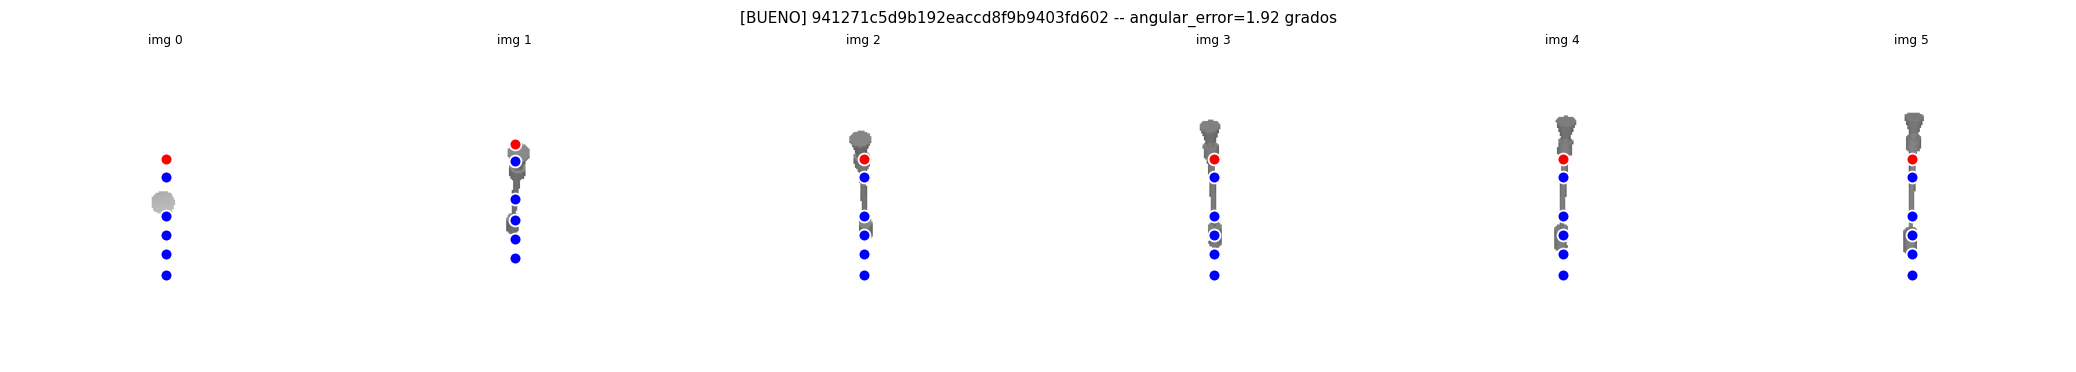

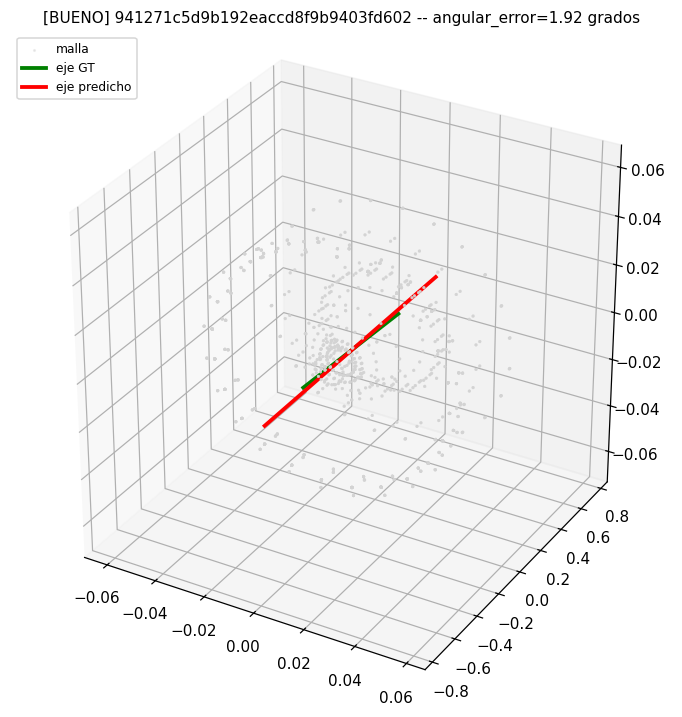

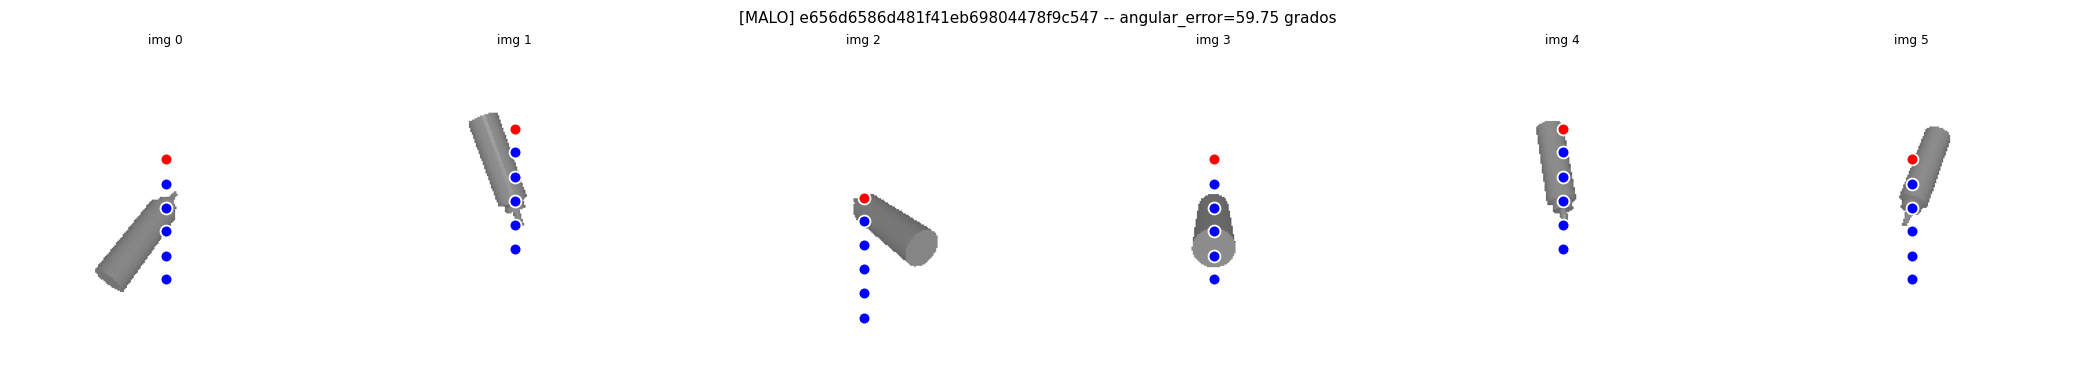

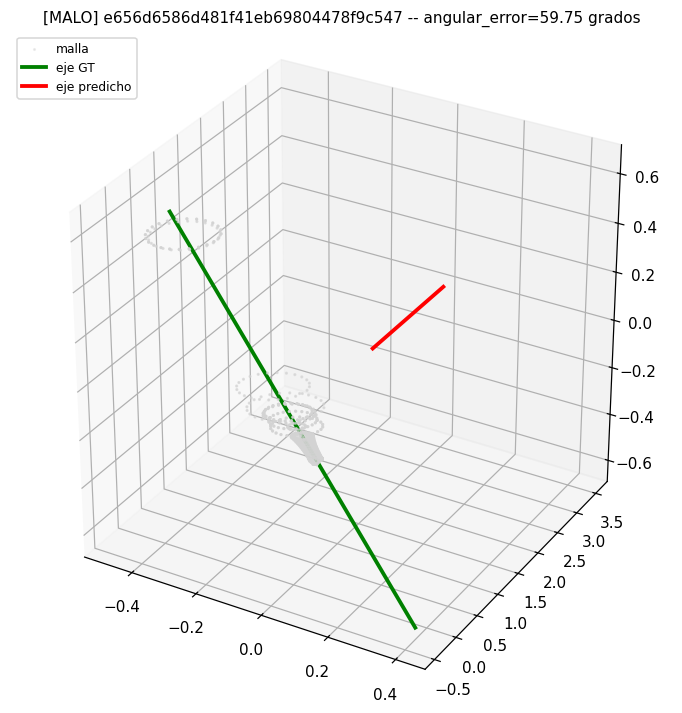

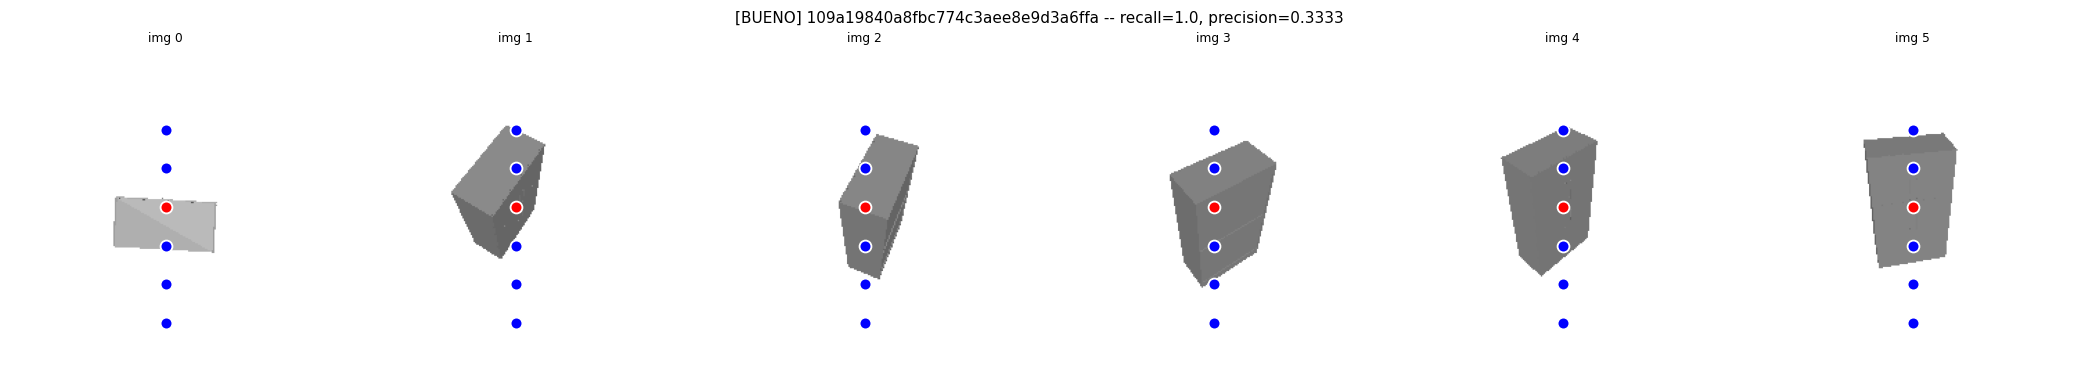

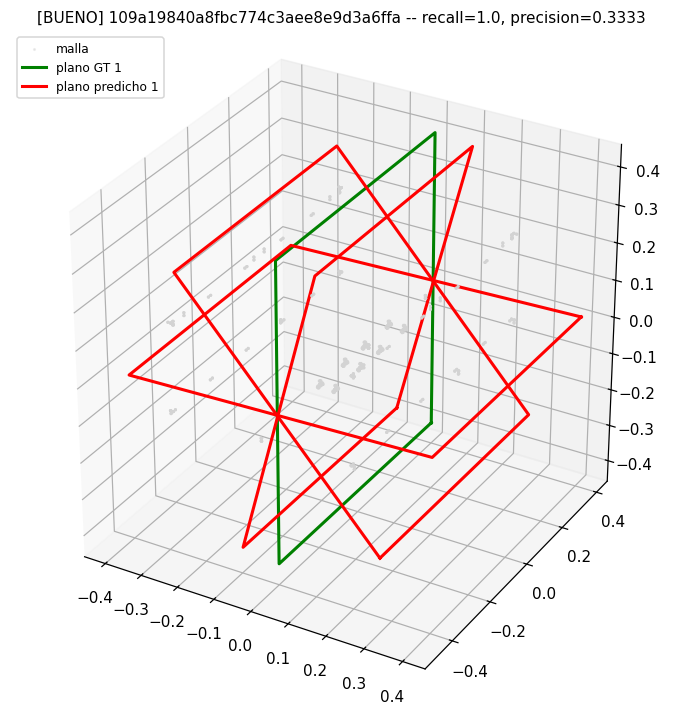

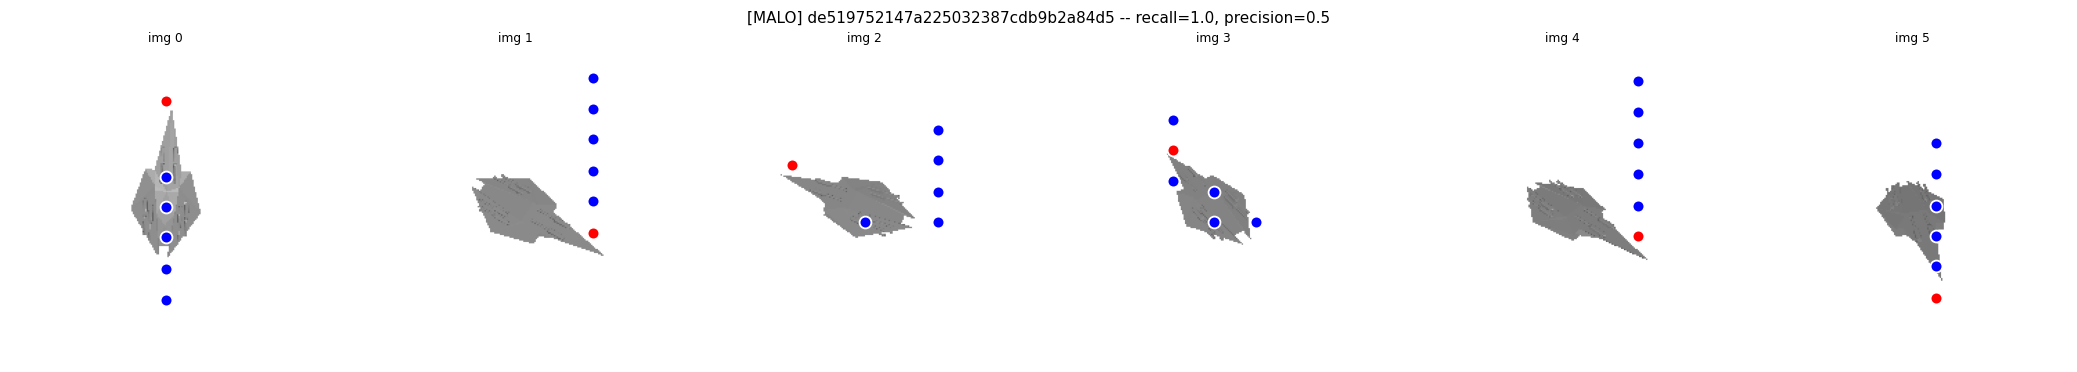

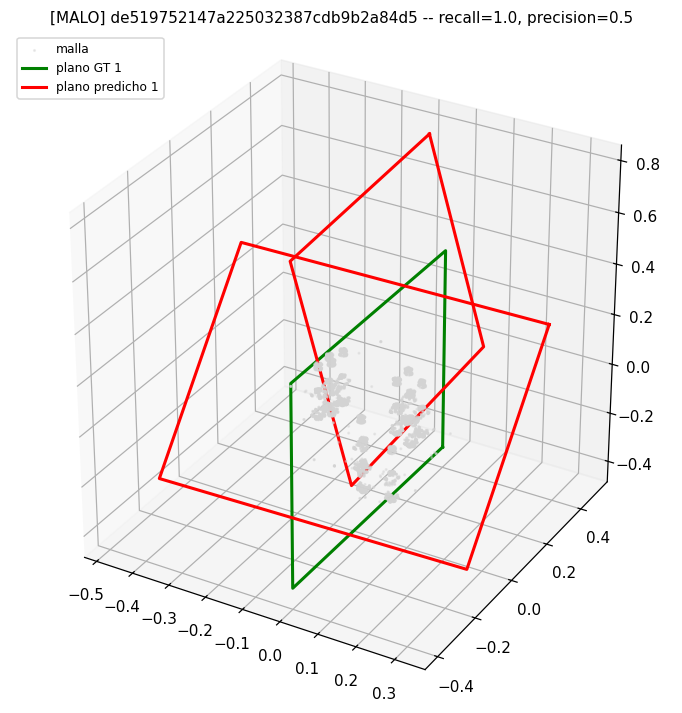

In [24]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


def _plot_2d(symmetry_type: str, object_id: str, categoria: str, experiment_id: str,
            n_views: int, subtitle: str, max_views_2d: int = 6) -> None:
    render_dir = SANDBOX_RENDERS / symmetry_type / object_id / str(SIZE) / LIGHTING
    molmo_data = json.load(open(render_dir / f"molmo_multiview_{experiment_id}.json", encoding="utf-8"))
    group = molmo_data[str(n_views)]
    images_sent, points_by_image = group["images_sent"], group["points_by_image"]

    idxs = sorted(points_by_image.keys(), key=int)[:max_views_2d]
    fig, axes = plt.subplots(1, len(idxs), figsize=(3.2 * len(idxs), 3.4))
    if len(idxs) == 1:
        axes = [axes]
    for ax, idx_str in zip(axes, idxs):
        cam = images_sent[int(idx_str)]
        img_path = render_dir / cam["filename"]
        img = np.array(Image.open(img_path)) if img_path.exists() else None
        if img is not None:
            ax.imshow(img)
            img_h, img_w = img.shape[0], img.shape[1]
        else:
            img_w = img_h = SIZE
            ax.set_xlim(0, img_w); ax.set_ylim(img_h, 0)
        for p in points_by_image[idx_str]:
            px, py = molmo_xy_to_pixel(p["x"], p["y"], img_w, img_h)
            ax.scatter([px], [py], c="red" if p["obj_id"] == 1 else "blue",
                       s=60, edgecolors="white", linewidths=1.2, zorder=5)
        ax.set_title(f"img {idx_str}", fontsize=8)
        ax.axis("off")
    fig.suptitle(f"[{categoria}] {object_id} -- {subtitle}", fontsize=10)
    fig.tight_layout()
    plt.show()


def plot_axis_case(object_id: str, categoria: str, n_views: int) -> None:
    pred = predicted_axes.get((object_id, n_views))
    gt   = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["axis_sym"] / f"{object_id}.txt")
    err  = df_eval_axis[(df_eval_axis.object_id == object_id) & (df_eval_axis.n_views == n_views)]["angular_error_deg"].iloc[0]
    _plot_2d("axis_sym", object_id, categoria, EXPERIMENT_ID_AXIS, n_views, f"angular_error={err:.2f} grados")

    mesh  = trimesh.load(str(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["axis_sym"] / f"{object_id}.obj"), force="mesh", process=False)
    verts = np.asarray(mesh.vertices)
    verts_plot = verts if len(verts) <= 4000 else verts[np.random.default_rng(0).choice(len(verts), 4000, replace=False)]
    bbox_diag = float(np.linalg.norm(verts.max(axis=0) - verts.min(axis=0)))

    fig = plt.figure(figsize=(6.5, 6.5))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(verts_plot[:, 0], verts_plot[:, 1], verts_plot[:, 2], s=1, c="lightgray", alpha=0.4, label="malla")

    def plot_line(origin, direction, color, label):
        d = np.array(direction) / np.linalg.norm(direction)
        o = np.array(origin)
        p0, p1 = o - d * bbox_diag * 0.75, o + d * bbox_diag * 0.75
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]], color=color, linewidth=2.5, label=label)

    plot_line(gt["elements"][0]["origin"], gt["elements"][0]["direction"], "green", "eje GT")
    if pred is not None:
        plot_line(pred["origin"], pred["direction"], "red", "eje predicho")
    ax.set_title(f"[{categoria}] {object_id} -- angular_error={err:.2f} grados", fontsize=10)
    ax.legend(loc="upper left", fontsize=8)
    ax.set_box_aspect([1, 1, 1])
    fig.tight_layout()
    plt.show()


def _plane_patch(origin, normal, size, color, label, ax):
    """Dibuja el plano como un cuadrado finito centrado en origin, para poder verlo en 3D."""
    normal = np.array(normal) / np.linalg.norm(normal)
    origin = np.array(origin)
    tmp = np.array([1.0, 0.0, 0.0]) if abs(normal[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
    u = np.cross(normal, tmp); u /= np.linalg.norm(u)
    v = np.cross(normal, u)
    corners = [origin + s1 * size * u + s2 * size * v for s1 in (-1, 1) for s2 in (-1, 1)]
    corners = [corners[0], corners[1], corners[3], corners[2]]  # orden para que el poligono no se cruce
    xs, ys, zs = zip(*corners)
    ax.plot(list(xs) + [xs[0]], list(ys) + [ys[0]], list(zs) + [zs[0]], color=color, linewidth=2, label=label)


def plot_plane_case(object_id: str, categoria: str, n_views: int) -> None:
    planes = predicted_planes.get((object_id, n_views), [])
    gt     = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["plane_sym"] / f"{object_id}.txt")
    row    = df_eval_plane[(df_eval_plane.object_id == object_id) & (df_eval_plane.n_views == n_views)].iloc[0]
    _plot_2d("plane_sym", object_id, categoria, EXPERIMENT_ID_PLANE, n_views,
             f"recall={row['recall_planes']}, precision={row['precision_planes']}")

    mesh  = trimesh.load(str(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["plane_sym"] / f"{object_id}.obj"), force="mesh", process=False)
    verts = np.asarray(mesh.vertices)
    verts_plot = verts if len(verts) <= 4000 else verts[np.random.default_rng(0).choice(len(verts), 4000, replace=False)]
    bbox_diag = float(np.linalg.norm(verts.max(axis=0) - verts.min(axis=0)))

    fig = plt.figure(figsize=(6.5, 6.5))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(verts_plot[:, 0], verts_plot[:, 1], verts_plot[:, 2], s=1, c="lightgray", alpha=0.4, label="malla")

    for i, e in enumerate(gt["elements"]):
        _plane_patch(e["origin"], e["normal"], bbox_diag * 0.4, "green", f"plano GT {i+1}" if i == 0 else None, ax)
    for i, p in enumerate(planes):
        _plane_patch(p["origin"], p["normal"], bbox_diag * 0.4, "red", f"plano predicho {i+1}" if i == 0 else None, ax)

    ax.set_title(f"[{categoria}] {object_id} -- recall={row['recall_planes']}, precision={row['precision_planes']}", fontsize=10)
    ax.legend(loc="upper left", fontsize=8)
    ax.set_box_aspect([1, 1, 1])
    fig.tight_layout()
    plt.show()


# Ejemplo: un BUENO y un MALO de cada tipo, al mayor n_views
plot_axis_case(OBJECT_LIST_AXIS[0][1], "BUENO", n_views=max(VIEW_GROUPS))
plot_axis_case(OBJECT_LIST_AXIS[-1][1], "MALO", n_views=max(VIEW_GROUPS))
plot_plane_case(OBJECT_LIST_PLANE[0][1], "BUENO", n_views=max(VIEW_GROUPS))
plot_plane_case(OBJECT_LIST_PLANE[-1][1], "MALO", n_views=max(VIEW_GROUPS))

---
## 10. Ablaciones de triangulación y consolidación

Experimentos independientes sobre los datos ya inferidos por Molmo2 (no
requieren volver a correr el modelo). Cada ablación puede activarse/desactivarse
de forma aislada. La evaluación usa las mismas funciones y mallas de la
Sección 8 (`mesh_cache_axis`, `mesh_cache_plane`, `calaxisloss`, `calplaneloss`,
`f1_match_counts`) para que los resultados sean directamente comparables con el baseline.

| ID | Tipo | Qué cambia | Referencia |
|----|------|-----------|-----------|
| **EXP-A** | eje + plano | Triangulación ponderada por longitud 2D | Bartoli & Sturm, CVIU 2005 |
| **EXP-B** | eje | Point-then-Direction (ancla + dirección separados) | Wu et al., PMC 2021 |
| **EXP-C** | eje + plano | Filtro objeto + RANSAC 2D (diseñado para ≥6 pts/vista) | Recker et al., WACV 2013 |
| **EXP-D** | eje + plano | Confianza proxy: longitud × penalización de borde | AssemblyHands-X arXiv:2509.23888 |
| **EXP-E** | eje | Reweighting iterativo por residual de reproyección | Hess-Flores et al. eScholarship |
| **EXP-F** | plano | Pipeline 3-tier con parada por SDE_ref real | Gao et al. TVCG 2021 (adaptado) |


### 10.0 Helpers y evaluadores compartidos

In [25]:
# ── Helpers compartidos para todas las ablaciones ──────────────────────────
import itertools

def auc_angular(errors_deg: list, max_theta: float = 45.0) -> float:
    thetas = np.linspace(0, max_theta, 1000)
    errs = np.array(errors_deg)
    precs = [(errs <= t).mean() for t in thetas]
    return float(np.trapezoid(precs, thetas) / max_theta)


def _eval_axis_row(cat, oid, n_views, pred, t_dir, t_orig, mesh_v, mesh_f, sample):
    """Build one eval row for an axis prediction (or None)."""
    row = {"categoria": cat, "object_id": oid, "n_views": n_views}
    if pred is None:
        row.update({"angular_error_deg": 90.0, "translation_error": None, "sde_ref": None})
    else:
        p_dir  = np.array(pred["direction"])
        p_orig = np.array(pred["origin"])
        ang  = angular_error_deg(p_dir, t_dir)
        dist = point_to_line_distance(p_orig, t_orig, t_dir)
        sde  = calaxisloss(p_dir, p_orig, mesh_v, mesh_f, sample)
        row.update({"angular_error_deg": round(ang, 4),
                    "translation_error": round(dist, 6),
                    "sde_ref": round(sde, 8)})
        for t in ANGULAR_THRESHOLDS:
            row[f"precision_{t}deg"] = int(ang < t)
    return row


def _eval_plane_row(cat, oid, n_views, planes, true_elements, mesh_v, mesh_f, sample, gt_planes_ref):
    """Build one eval row for a plane prediction list (or [])."""
    row = {"categoria": cat, "object_id": oid, "n_views": n_views,
           "n_true_planes": len(true_elements)}
    if not planes:
        row.update({"recall_planes": 0.0, "precision_planes": None,
                    "n_planes_predicted": 0, "sde_ref": None, "f1_counts": None})
    else:
        m = evaluate_plane_multiset(planes, true_elements, angular_threshold_deg=ANGULAR_THRESHOLDS[-1])
        pred_planes_ref = [normal_origin_to_plane(p["normal"], p["origin"]) for p in planes]
        sde_per_plane   = [calplaneloss(pp, mesh_v, mesh_f, sample) for pp in pred_planes_ref]
        f1_counts = {t: f1_match_counts(pred_planes_ref, gt_planes_ref, t) for t in THRESHOLDS_INLIER}
        row.update({"status": "ok", **m,
                    "sde_ref": round(float(np.mean(sde_per_plane)), 8),
                    "f1_counts": f1_counts})
    return row


def summarize_axis(label: str, rows: list) -> pd.DataFrame:
    df = pd.DataFrame(rows)
    df["angular_error_deg"] = df["angular_error_deg"].fillna(90.0)
    summary = df.groupby("n_views")["angular_error_deg"].agg(
        mean="mean", median="median", std="std").round(2)
    for t in ANGULAR_THRESHOLDS:
        col = f"precision_{t}deg"
        if col in df.columns:
            summary[f"P@{t}°"] = df.groupby("n_views")[col].mean().round(4)
    auc_map = {nv: round(auc_angular(g["angular_error_deg"].tolist()), 4)
               for nv, g in df.groupby("n_views")}
    summary["AUC@45°"] = pd.Series(auc_map)
    if "sde_ref" in df.columns:
        summary["SDE_ref_mean"] = df.groupby("n_views")["sde_ref"].mean().round(8)
    print(f"\n{'='*64}\n  {label}\n{'='*64}")
    print(summary.to_string())
    return summary


def summarize_plane(label: str, rows: list) -> pd.DataFrame:
    df = pd.DataFrame(rows)
    totals_by_nv = {}
    for nv, grp in df.groupby("n_views"):
        totals = {t: [0, 0, 0] for t in THRESHOLDS_INLIER}
        for fc in grp["f1_counts"].dropna():
            for t in THRESHOLDS_INLIER:
                tp, fp, fn = fc[str(t)] if isinstance(list(fc.keys())[0], str) else fc[t]
                totals[t][0] += tp; totals[t][1] += fp; totals[t][2] += fn
        f1_per_t = [f1_from_counts(*totals[t]) for t in THRESHOLDS_INLIER]
        totals_by_nv[nv] = round(float(np.mean(f1_per_t)), 4)
    summary = df.groupby("n_views")[["recall_planes", "precision_planes", "sde_ref"]].mean().round(4)
    summary["f1_ref"]          = pd.Series(totals_by_nv)
    summary["n_pred_mean"]     = df.groupby("n_views")["n_planes_predicted"].mean().round(2)
    print(f"\n{'='*64}\n  {label}\n{'='*64}")
    print(summary.to_string())
    return summary


### 10.1 Nuevas funciones de triangulación (compartidas por A–F)

In [26]:
# ── Triangulación ponderada (Bartoli & Sturm 2005) ──────────────────────────
def triangulate_line_weighted(camera_centers: list, plane_normals: list,
                               weights: list) -> tuple[np.ndarray, np.ndarray]:
    """
    Weighted interpretation-plane triangulation.
    M = sum_i w_i * n_i n_i^T; direction = eigvec of MIN eigenvalue (axis).
    Ref: Bartoli & Sturm, CVIU 2005. DOI:10.1016/j.cviu.2005.06.001
    """
    N  = np.asarray(plane_normals, dtype=np.float64)
    C  = np.asarray(camera_centers, dtype=np.float64)
    w  = np.asarray(weights, dtype=np.float64); w = w / w.sum()
    M  = (N * w[:, None]).T @ N
    _, _, Vt = np.linalg.svd(M)
    direction = Vt[-1]; direction /= np.linalg.norm(direction)
    A = (np.diag(w) @ N)
    b = np.einsum("ij,ij->i", N, C) * w
    point, *_ = np.linalg.lstsq(A, b, rcond=None)
    return point, direction


def triangulate_plane_weighted(camera_centers: list, plane_normals: list,
                                weights: list) -> tuple[np.ndarray, np.ndarray]:
    """
    Same as above but uses MAX eigenvalue — for plane symmetry (dual).
    The symmetry plane's normal is the direction of LEAST spread of interpretation normals.
    """
    N  = np.asarray(plane_normals, dtype=np.float64)
    C  = np.asarray(camera_centers, dtype=np.float64)
    w  = np.asarray(weights, dtype=np.float64); w = w / w.sum()
    M  = (N * w[:, None]).T @ N
    _, _, Vt = np.linalg.svd(M)
    normal = Vt[0]; normal /= np.linalg.norm(normal)   # MAX eigenvalue for plane
    origin = np.average(C, weights=w, axis=0)
    return origin, normal


# ── Midpoint triangulation (pair-wise) ───────────────────────────────────────
def midpoint_triangulate_pair(o1: np.ndarray, d1: np.ndarray,
                               o2: np.ndarray, d2: np.ndarray) -> np.ndarray:
    w = o1 - o2
    a, b, c_, d, e = (d1@d1, d1@d2, d2@d2, d1@w, d2@w)
    denom = a * c_ - b * b
    if abs(denom) < 1e-9:
        return (o1 + o2) / 2.0
    s = (b * e - c_ * d) / denom
    t = (a * e - b  * d) / denom
    return ((o1 + s * d1) + (o2 + t * d2)) / 2.0


# ── RANSAC 2D line fitting (Recker et al. WACV 2013) ────────────────────────
RANSAC_THR_PX  = 8.0
RANSAC_N_ITER  = 100
RANSAC_MIN_PTS = 4

def fit_line_ransac_2d(points_xy: list, n_iter=RANSAC_N_ITER, thr_px=RANSAC_THR_PX,
                        min_inliers=RANSAC_MIN_PTS, rng=None):
    """
    RANSAC 2D line fitting. Returns (inlier_points, seg_length) or None.
    Ref: Recker et al. WACV 2013. https://sites.google.com/view/mauriciohessflores
    """
    if rng is None: rng = np.random.default_rng(42)
    pts = np.array(points_xy, dtype=np.float64)
    n = len(pts)
    if n < 2: return None
    if n == 2:
        seg = float(np.linalg.norm(pts[1] - pts[0]))
        return points_xy, seg
    best_inliers, best_seg = [], 0.0
    for _ in range(n_iter):
        i, j = rng.choice(n, size=2, replace=False)
        diff = pts[j] - pts[i]
        if np.linalg.norm(diff) < 1e-3: continue
        a, b_ = -diff[1], diff[0]
        c_ = -(a * pts[i,0] + b_ * pts[i,1])
        norm_ab = (a*a + b_*b_) ** 0.5
        dists = np.abs(a * pts[:,0] + b_ * pts[:,1] + c_) / norm_ab
        mask = dists < thr_px
        if mask.sum() > len(best_inliers):
            inlier_pts = pts[mask]
            dir_n = diff / np.linalg.norm(diff)
            projs = inlier_pts @ dir_n
            best_seg = float(projs.max() - projs.min())
            best_inliers = [tuple(p) for p in inlier_pts]
    if len(best_inliers) < min_inliers: return None
    return best_inliers, best_seg


def widest_pair_from_inliers(inlier_pts: list):
    pts = np.array(inlier_pts)
    best = (-1.0, 0, 1)
    for i in range(len(pts)):
        for j in range(i+1, len(pts)):
            d = float(np.sum((pts[i]-pts[j])**2))
            if d > best[0]: best = (d, i, j)
    _, i, j = best
    return ({"x": float(pts[i,0]), "y": float(pts[i,1])},
            {"x": float(pts[j,0]), "y": float(pts[j,1])},
            best[0]**0.5)


# ── Border margin proxy (AssemblyHands-X arXiv:2509.23888) ──────────────────
BORDER_MARGIN_PX = 20

def border_margin_px(x: float, y: float, image_size: int) -> float:
    px = (x / 1000.0) * image_size
    py = (y / 1000.0) * image_size
    return float(min(px, py, image_size - px, image_size - py))


### EXP-A — Triangulación ponderada por longitud 2D
*(Bartoli & Sturm, CVIU 2005. DOI:10.1016/j.cviu.2005.06.001)*

**Motivación**: en la triangulación baseline todos los planos de interpretación
pesan igual. Una vista donde los dos puntos predichos están a 5 px de distancia
contribuye igual que una donde están a 200 px, aunque la primera es mucho más
sensible a ruido. El peso $w_i = \|p_a^{(i)} - p_b^{(i)}\|_2$ corrige esto.


In [27]:
# ── EXP-A: estimadores ─────────────────────────────────────────────────────
def estimate_axis_weighted(points_by_image, images_sent, fov_deg, image_size):
    """EXP-A eje: widest_pair + weight = 2D segment length (px)."""
    centers, normals, weights = [], [], []
    for img_idx_str, pts in points_by_image.items():
        pair = widest_pair(pts)
        if pair is None: continue
        p_a, p_b = pair
        cam = images_sent[int(img_idx_str)]
        C, d_a = ray_dir_for_point(p_a["x"], p_a["y"], cam["R"], cam["T"], fov_deg, image_size)
        _, d_b  = ray_dir_for_point(p_b["x"], p_b["y"], cam["R"], cam["T"], fov_deg, image_size)
        n = interpretation_plane_normal(d_a, d_b)
        if n is None: continue
        seg = ((p_a["x"]-p_b["x"])**2 + (p_a["y"]-p_b["y"])**2)**0.5
        centers.append(C); normals.append(n); weights.append(max(seg, 1e-3))
    if len(normals) < 2:
        raise ValueError(f"EXP-A eje: need >=2, got {len(normals)}")
    point, direction = triangulate_line_weighted(centers, normals, weights)
    return {"direction": direction.tolist(), "origin": point.tolist(), "n_views_used": len(normals)}


def estimate_plane_weighted(points_by_image, images_sent, fov_deg, image_size,
                             edge_on_thresh=EDGE_ON_THRESH_DEFAULT,
                             max_planes=MAX_PLANES, dup_angle_thresh_deg=DUP_ANGLE_THRESH_DEFAULT):
    """EXP-A plano: misma lógica que detect_planes_no_mesh pero la normal del refit
    se pesa por la longitud de segmento del par de vistas que generó cada línea."""
    def _ang(v1, v2):
        return float(np.degrees(np.arccos(np.clip(abs(float(np.dot(
            v1/np.linalg.norm(v1), v2/np.linalg.norm(v2)))), 0.0, 1.0))))

    def _run_one(pts_by_img):
        view_idxs = sorted(int(k) for k, pts in pts_by_img.items()
                           if widest_pair(pts) is not None)   # 2 o 6 puntos
        if len(view_idxs) < 4: raise ValueError("need >=4 views")
        pair_lines, pair_weights = [], []
        for i, j in combinations(view_idxs, 2):
            res = _line_from_view_pair(i, j, pts_by_img, images_sent, fov_deg, image_size)
            if res is None: continue
            point, direction = res
            # weight = geometric mean of widest-pair segment lengths in each view
            segs = []
            for idx in (i, j):
                pts = pts_by_img.get(str(idx), [])
                pair_w = widest_pair(pts)
                if pair_w is not None:
                    p1, p2 = pair_w
                    segs.append(((p1["x"]-p2["x"])**2 + (p1["y"]-p2["y"])**2)**0.5)
            w = (segs[0]*segs[1])**0.5 if len(segs)==2 else 1.0
            pair_lines.append(((i, j), point, direction)); pair_weights.append(max(w, 1e-3))
        if len(pair_lines) < 2: raise ValueError("not enough pair-lines")
        view_dirs = {idx: view_forward_direction(
            images_sent[idx]["R"], images_sent[idx]["T"], fov_deg, image_size)
                     for idx in view_idxs}
        def score_normal(n):
            vals = sorted(abs(np.dot(view_dirs[i], n)) for i in view_idxs)
            return float(np.mean(vals[:max(2, len(vals)//2)]))
        candidates = []
        for a_ in range(len(pair_lines)):
            for b_ in range(a_+1, len(pair_lines)):
                pa, _, dir_a = pair_lines[a_]
                pb, _, dir_b = pair_lines[b_]
                if set(pa) & set(pb): continue
                n = np.cross(dir_a, dir_b)
                nrm = np.linalg.norm(n)
                if nrm < 1e-6: continue
                candidates.append(n / nrm)
        if not candidates: raise ValueError("no candidates")
        scored = sorted(candidates, key=score_normal)
        best_normal = scored[0]
        good_views = [i for i in view_idxs
                      if abs(np.dot(view_dirs[i], best_normal)) < edge_on_thresh]
        # Weighted refit: weight each pair_line by its segment weight
        refit_dirs, refit_weights = [], []
        for (pa, _, d), w in zip(pair_lines, pair_weights):
            if set(pa).issubset(good_views):
                refit_dirs.append(d); refit_weights.append(w)
        refit_points = [p for (pa, p, _) in pair_lines if set(pa).issubset(good_views)]
        if len(refit_dirs) >= 2:
            D = np.asarray(refit_dirs); W = np.asarray(refit_weights); W /= W.sum()
            M = (D * W[:, None]).T @ D
            _, _, Vt = np.linalg.svd(M)
            refined_normal = Vt[-1]; refined_normal /= np.linalg.norm(refined_normal)
            used_points = refit_points
        else:
            refined_normal, used_points = best_normal, [p for (_, p, _) in pair_lines]
        origin = np.mean(used_points, axis=0)
        return {"normal": refined_normal.tolist(), "origin": origin.tolist(),
                "n_views_used": len(good_views), "good_views": good_views}

    all_view_idxs = sorted(int(k) for k, pts in points_by_image.items()
                           if widest_pair(pts) is not None)   # 2 o 6 puntos
    pool, planes = set(all_view_idxs), []
    while len(planes) < max_planes:
        if len(pool) < 4: break
        sub = {k: v for k, v in points_by_image.items() if int(k) in pool}
        try:
            pred = _run_one(sub)
        except ValueError:
            break
        normal = np.array(pred["normal"])
        if any(_ang(normal, np.array(p["normal"])) < dup_angle_thresh_deg for p in planes):
            break
        planes.append(pred); pool -= set(pred["good_views"])
    return planes


# ── EXP-A: evaluación eje ──────────────────────────────────────────────────
rows_A_axis = []
for cat, oid in OBJECT_LIST_AXIS:
    gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["axis_sym"] / f"{oid}.txt")
    t_dir, t_orig = np.array(gt["elements"][0]["direction"]), np.array(gt["elements"][0]["origin"])
    mesh_v, mesh_f, sample = mesh_cache_axis[oid]
    render_dir = SANDBOX_RENDERS / "axis_sym" / oid / str(SIZE) / LIGHTING
    molmo_data = json.load(open(render_dir / f"molmo_multiview_{EXPERIMENT_ID_AXIS}.json"))
    for n_views in VIEW_GROUPS:
        group = molmo_data.get(str(n_views), {})
        try:
            pred = estimate_axis_weighted(group.get("points_by_image",{}), group.get("images_sent",[]), DEFAULT_FOV, SIZE)
        except ValueError: pred = None
        rows_A_axis.append(_eval_axis_row(cat, oid, n_views, pred, t_dir, t_orig, mesh_v, mesh_f, sample))

summary_A_axis = summarize_axis("EXP-A EJE: Triangulación ponderada (Bartoli & Sturm CVIU 2005)", rows_A_axis)

# ── EXP-A: evaluación plano ────────────────────────────────────────────────
rows_A_plane = []
for cat, oid in OBJECT_LIST_PLANE:
    gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["plane_sym"] / f"{oid}.txt")
    true_elements = gt["elements"]
    mesh_v, mesh_f, sample, gt_planes_ref = mesh_cache_plane[oid]
    render_dir = SANDBOX_RENDERS / "plane_sym" / oid / str(SIZE) / LIGHTING
    molmo_data = json.load(open(render_dir / f"molmo_multiview_{EXPERIMENT_ID_PLANE}.json"))
    for n_views in VIEW_GROUPS:
        group = molmo_data.get(str(n_views), {})
        try:
            planes = estimate_plane_weighted(group.get("points_by_image",{}), group.get("images_sent",[]),
                                             DEFAULT_FOV, SIZE)
        except (ValueError, Exception): planes = []
        rows_A_plane.append(_eval_plane_row(cat, oid, n_views, planes, true_elements, mesh_v, mesh_f, sample, gt_planes_ref))

summary_A_plane = summarize_plane("EXP-A PLANO: Triangulación ponderada (Bartoli & Sturm CVIU 2005)", rows_A_plane)



  EXP-A EJE: Triangulación ponderada (Bartoli & Sturm CVIU 2005)
          mean  median    std    P@5°   P@10°   P@15°  AUC@45°  SDE_ref_mean
n_views                                                                     
6        60.26   71.05  31.14  0.1111  0.1852  0.1852   0.1796      0.077557
14       59.07   58.25  29.24  0.1071  0.1786  0.1786   0.1598      0.054232
26       55.33   57.65  29.12  0.1071  0.1786  0.1786   0.1746      0.067420


/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/gpytoolbox/barycentric_coordinates.py:104: RuntimeWarning: invalid value encountered in divide
  gamma = np.sum(np.multiply(np.cross(u,w,axis=1),N),axis=1)/n2
/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/gpytoolbox/barycentric_coordinates.py:105: RuntimeWarning: invalid value encountered in divide
  beta = np.sum(np.multiply(np.cross(w,v,axis=1),N),axis=1)/n2



  EXP-A PLANO: Triangulación ponderada (Bartoli & Sturm CVIU 2005)
         recall_planes  precision_planes  sde_ref  f1_ref  n_pred_mean
n_views                                                               
6               0.4000            0.4138   0.0255  0.2500         0.97
14              0.7333            0.4000   0.0111  0.4324         1.93
26              0.7500            0.3448   0.0231  0.1668         2.33


### EXP-B — Point-then-Direction (eje únicamente)
*(Wu et al., PMC 2021. https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7832884/)*

Separa la estimación en dos subproblemas: (1) punto ancla via promedio ponderado
de midpoint-triangulations entre pares de vistas; (2) dirección via SVD ponderado
sobre los planos de interpretación centrados en ese ancla.


In [28]:
# ── EXP-B: Point-then-Direction (eje) ──────────────────────────────────────
def estimate_axis_ptd(points_by_image, images_sent, fov_deg, image_size):
    """EXP-B eje: Point-then-Direction. Ref: Wu et al. PMC 2021."""
    view_data = []
    for img_idx_str, pts in points_by_image.items():
        pair = widest_pair(pts)
        if pair is None: continue
        p_a, p_b = pair
        cam = images_sent[int(img_idx_str)]
        C, d_a = ray_dir_for_point(p_a["x"], p_a["y"], cam["R"], cam["T"], fov_deg, image_size)
        _, d_b  = ray_dir_for_point(p_b["x"], p_b["y"], cam["R"], cam["T"], fov_deg, image_size)
        n = interpretation_plane_normal(d_a, d_b)
        if n is None: continue
        seg = ((p_a["x"]-p_b["x"])**2 + (p_a["y"]-p_b["y"])**2)**0.5
        d_mid = (d_a + d_b); d_mid /= np.linalg.norm(d_mid)
        view_data.append({"C": C, "d_mid": d_mid, "n": n, "seg": seg})
    if len(view_data) < 2:
        raise ValueError(f"EXP-B: need >=2, got {len(view_data)}")
    # Step 1: anchor via weighted pairwise midpoints
    anchor_pts = []
    for i, j in itertools.combinations(range(len(view_data)), 2):
        vi, vj = view_data[i], view_data[j]
        mp = midpoint_triangulate_pair(vi["C"], vi["d_mid"], vj["C"], vj["d_mid"])
        w  = (vi["seg"] * vj["seg"]) ** 0.5
        anchor_pts.append((mp, w))
    total_w = sum(w for _, w in anchor_pts)
    anchor = sum(mp * w for mp, w in anchor_pts) / total_w
    # Step 2: direction via weighted SVD on interpretation planes
    normals = np.array([v["n"] for v in view_data])
    weights = np.array([max(v["seg"], 1e-3) for v in view_data]); weights /= weights.sum()
    M = (normals * weights[:, None]).T @ normals
    _, _, Vt = np.linalg.svd(M)
    direction = Vt[-1]; direction /= np.linalg.norm(direction)
    return {"direction": direction.tolist(), "origin": anchor.tolist(),
            "n_views_used": len(view_data)}


rows_B_axis = []
for cat, oid in OBJECT_LIST_AXIS:
    gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["axis_sym"] / f"{oid}.txt")
    t_dir, t_orig = np.array(gt["elements"][0]["direction"]), np.array(gt["elements"][0]["origin"])
    mesh_v, mesh_f, sample = mesh_cache_axis[oid]
    render_dir = SANDBOX_RENDERS / "axis_sym" / oid / str(SIZE) / LIGHTING
    molmo_data = json.load(open(render_dir / f"molmo_multiview_{EXPERIMENT_ID_AXIS}.json"))
    for n_views in VIEW_GROUPS:
        group = molmo_data.get(str(n_views), {})
        try:
            pred = estimate_axis_ptd(group.get("points_by_image",{}), group.get("images_sent",[]), DEFAULT_FOV, SIZE)
        except ValueError: pred = None
        rows_B_axis.append(_eval_axis_row(cat, oid, n_views, pred, t_dir, t_orig, mesh_v, mesh_f, sample))

summary_B_axis = summarize_axis("EXP-B EJE: Point-then-Direction (Wu et al. PMC 2021)", rows_B_axis)



  EXP-B EJE: Point-then-Direction (Wu et al. PMC 2021)
          mean  median    std    P@5°   P@10°   P@15°  AUC@45°  SDE_ref_mean
n_views                                                                     
6        60.26   71.05  31.14  0.1111  0.1852  0.1852   0.1796      0.096644
14       59.07   58.25  29.24  0.1071  0.1786  0.1786   0.1598      0.052891
26       55.33   57.65  29.12  0.1071  0.1786  0.1786   0.1746      0.059222


### EXP-C — Filtro objeto + RANSAC 2D
*(Recker et al. WACV 2013; Zhang et al. arXiv:2008.01258)*

Aplica filtro de píxeles de objeto y luego RANSAC 2D para ajustar una línea robusta
a los puntos de cada vista antes de formar el plano de interpretación. Con los
prompts actuales de 2 puntos, el efecto es idéntico al del filtro de objeto solo
(sin outliers extra). Con prompts de ≥6 puntos, RANSAC elimina los puntos ruidosos
antes de la triangulación.


In [29]:
# ── EXP-C: Filtro objeto + RANSAC 2D ───────────────────────────────────────
FILTER_OBJECT_C = True   # False para aislar solo el efecto del RANSAC 2D

def estimate_axis_ransac(points_by_image, images_sent, fov_deg, image_size,
                          render_dir, filter_object=True, image_cache=None):
    """EXP-C eje: filter object pixels, RANSAC 2D line, weighted triangulation."""
    if image_cache is None: image_cache = {}
    pts_filt = filter_points_on_object(
        points_by_image, images_sent, render_dir, min_points=2, image_cache=image_cache
    ) if filter_object else points_by_image
    rng = np.random.default_rng(0)
    centers, normals, weights = [], [], []
    for img_idx_str, pts in pts_filt.items():
        if not pts: continue
        xy = [(p["x"], p["y"]) for p in pts]
        result = fit_line_ransac_2d(xy, rng=rng)
        if result is None: continue
        inliers, _ = result
        p_a, p_b, seg_px = widest_pair_from_inliers(inliers)
        cam = images_sent[int(img_idx_str)]
        C, d_a = ray_dir_for_point(p_a["x"], p_a["y"], cam["R"], cam["T"], fov_deg, image_size)
        _, d_b  = ray_dir_for_point(p_b["x"], p_b["y"], cam["R"], cam["T"], fov_deg, image_size)
        n = interpretation_plane_normal(d_a, d_b)
        if n is None: continue
        centers.append(C); normals.append(n); weights.append(max(seg_px, 1e-3))
    if len(normals) < 2:
        raise ValueError(f"EXP-C eje: need >=2, got {len(normals)}")
    point, direction = triangulate_line_weighted(centers, normals, weights)
    return {"direction": direction.tolist(), "origin": point.tolist(), "n_views_used": len(normals)}


def detect_planes_ransac(points_by_image, images_sent, fov_deg, image_size,
                          render_dir, filter_object=True, image_cache=None,
                          max_planes=MAX_PLANES, edge_on_thresh=EDGE_ON_THRESH_DEFAULT,
                          dup_angle_thresh_deg=DUP_ANGLE_THRESH_DEFAULT):
    """EXP-C plano: filter + RANSAC 2D, then detect_planes_no_mesh on filtered pairs."""
    if image_cache is None: image_cache = {}
    pts_filt = filter_points_on_object(
        points_by_image, images_sent, render_dir, min_points=2, image_cache=image_cache
    ) if filter_object else points_by_image
    # Re-map to obj_id 1/2 from widest RANSAC inlier pair (preserves downstream API)
    pts_remapped = {}
    rng = np.random.default_rng(0)
    for img_idx_str, pts in pts_filt.items():
        if not pts: continue
        xy = [(p["x"], p["y"]) for p in pts]
        result = fit_line_ransac_2d(xy, rng=rng)
        if result is None: continue
        inliers, _ = result
        p_a, p_b, _ = widest_pair_from_inliers(inliers)
        pts_remapped[img_idx_str] = [
            {"obj_id": 1, "x": p_a["x"], "y": p_a["y"]},
            {"obj_id": 2, "x": p_b["x"], "y": p_b["y"]},
        ]
    if not pts_remapped:
        return []
    return detect_planes_no_mesh(pts_remapped, images_sent, fov_deg, image_size,
                                  edge_on_thresh, max_planes, dup_angle_thresh_deg)


# EXP-C eje
rows_C_axis = []
for cat, oid in OBJECT_LIST_AXIS:
    gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["axis_sym"] / f"{oid}.txt")
    t_dir, t_orig = np.array(gt["elements"][0]["direction"]), np.array(gt["elements"][0]["origin"])
    mesh_v, mesh_f, sample = mesh_cache_axis[oid]
    render_dir = SANDBOX_RENDERS / "axis_sym" / oid / str(SIZE) / LIGHTING
    molmo_data = json.load(open(render_dir / f"molmo_multiview_{EXPERIMENT_ID_AXIS}.json"))
    img_cache = {}
    for n_views in VIEW_GROUPS:
        group = molmo_data.get(str(n_views), {})
        try:
            pred = estimate_axis_ransac(group.get("points_by_image",{}), group.get("images_sent",[]),
                                         DEFAULT_FOV, SIZE, render_dir,
                                         filter_object=FILTER_OBJECT_C, image_cache=img_cache)
        except ValueError: pred = None
        rows_C_axis.append(_eval_axis_row(cat, oid, n_views, pred, t_dir, t_orig, mesh_v, mesh_f, sample))

summary_C_axis = summarize_axis(f"EXP-C EJE: Filtro+RANSAC2D (Recker WACV 2013) | filter={FILTER_OBJECT_C}", rows_C_axis)

# EXP-C plano
rows_C_plane = []
for cat, oid in OBJECT_LIST_PLANE:
    gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["plane_sym"] / f"{oid}.txt")
    true_elements = gt["elements"]
    mesh_v, mesh_f, sample, gt_planes_ref = mesh_cache_plane[oid]
    render_dir = SANDBOX_RENDERS / "plane_sym" / oid / str(SIZE) / LIGHTING
    molmo_data = json.load(open(render_dir / f"molmo_multiview_{EXPERIMENT_ID_PLANE}.json"))
    img_cache = {}
    for n_views in VIEW_GROUPS:
        group = molmo_data.get(str(n_views), {})
        try:
            planes = detect_planes_ransac(group.get("points_by_image",{}), group.get("images_sent",[]),
                                           DEFAULT_FOV, SIZE, render_dir,
                                           filter_object=FILTER_OBJECT_C, image_cache=img_cache)
        except (ValueError, Exception): planes = []
        rows_C_plane.append(_eval_plane_row(cat, oid, n_views, planes, true_elements, mesh_v, mesh_f, sample, gt_planes_ref))

summary_C_plane = summarize_plane(f"EXP-C PLANO: Filtro+RANSAC2D (Recker WACV 2013) | filter={FILTER_OBJECT_C}", rows_C_plane)



  EXP-C EJE: Filtro+RANSAC2D (Recker WACV 2013) | filter=True
          mean  median    std    P@5°   P@10°   P@15°  AUC@45°  SDE_ref_mean
n_views                                                                     
6        63.51   75.64  30.80  0.1364  0.2273  0.2273   0.1568      0.095643
14       59.57   59.79  30.19  0.1111  0.1852  0.1852   0.1681      0.046239
26       57.88   64.71  33.15  0.1364  0.2273  0.2273   0.2153      0.061632


/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/gpytoolbox/barycentric_coordinates.py:104: RuntimeWarning: invalid value encountered in divide
  gamma = np.sum(np.multiply(np.cross(u,w,axis=1),N),axis=1)/n2
/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/gpytoolbox/barycentric_coordinates.py:105: RuntimeWarning: invalid value encountered in divide
  beta = np.sum(np.multiply(np.cross(w,v,axis=1),N),axis=1)/n2



  EXP-C PLANO: Filtro+RANSAC2D (Recker WACV 2013) | filter=True
         recall_planes  precision_planes  sde_ref  f1_ref  n_pred_mean
n_views                                                               
6               0.3667            0.5500   0.0280  0.3214         0.67
14              0.5333            0.5000   0.0102  0.3708         1.20
26              0.5000            0.3457   0.0187  0.2478         1.50


### EXP-D — Confianza proxy: longitud 2D × penalización de borde
*(AssemblyHands-X arXiv:2509.23888; COMPOSE arXiv:2601.09698)*

$w_i = \ell_i \cdot \min(1, m_i / \text{border\_margin})$ donde $m_i$ es la
distancia mínima al borde de imagen del punto más cercano al borde en la vista $i$.


In [30]:
# ── EXP-D: confianza proxy ─────────────────────────────────────────────────
def _conf_weight(p_a, p_b, image_size):
    seg = ((p_a["x"]-p_b["x"])**2 + (p_a["y"]-p_b["y"])**2)**0.5
    m   = min(border_margin_px(p_a["x"], p_a["y"], image_size),
              border_margin_px(p_b["x"], p_b["y"], image_size))
    return max(seg, 1e-3) * min(1.0, m / BORDER_MARGIN_PX)


def estimate_axis_conf(points_by_image, images_sent, fov_deg, image_size):
    """EXP-D eje: weighted triangulation with border-proximity penalty."""
    centers, normals, weights = [], [], []
    for img_idx_str, pts in points_by_image.items():
        pair = widest_pair(pts)
        if pair is None: continue
        p_a, p_b = pair
        cam = images_sent[int(img_idx_str)]
        C, d_a = ray_dir_for_point(p_a["x"], p_a["y"], cam["R"], cam["T"], fov_deg, image_size)
        _, d_b  = ray_dir_for_point(p_b["x"], p_b["y"], cam["R"], cam["T"], fov_deg, image_size)
        n = interpretation_plane_normal(d_a, d_b)
        if n is None: continue
        centers.append(C); normals.append(n)
        weights.append(max(_conf_weight(p_a, p_b, image_size), 1e-6))
    if len(normals) < 2: raise ValueError(f"EXP-D eje: need >=2, got {len(normals)}")
    point, direction = triangulate_line_weighted(centers, normals, weights)
    return {"direction": direction.tolist(), "origin": point.tolist(), "n_views_used": len(normals)}


def estimate_plane_conf(points_by_image, images_sent, fov_deg, image_size,
                         edge_on_thresh=EDGE_ON_THRESH_DEFAULT, max_planes=MAX_PLANES,
                         dup_angle_thresh_deg=DUP_ANGLE_THRESH_DEFAULT):
    """EXP-D plano: misma lógica que estimate_plane_weighted pero weight = confianza proxy."""
    def _ang(v1, v2):
        return float(np.degrees(np.arccos(np.clip(abs(float(np.dot(
            v1/np.linalg.norm(v1), v2/np.linalg.norm(v2)))), 0.0, 1.0))))
    def _run_one(pts_by_img):
        view_idxs = sorted(int(k) for k, pts in pts_by_img.items()
                           if widest_pair(pts) is not None)   # 2 o 6 puntos
        if len(view_idxs) < 4: raise ValueError("need >=4 views")
        pair_lines, pair_weights = [], []
        for i, j in combinations(view_idxs, 2):
            res = _line_from_view_pair(i, j, pts_by_img, images_sent, fov_deg, image_size)
            if res is None: continue
            point, direction = res
            ws = []
            for idx in (i, j):
                pts_ = pts_by_img.get(str(idx), [])
                pair_w = widest_pair(pts_)
                if pair_w is not None:
                    p1, p2 = pair_w
                    ws.append(_conf_weight(p1, p2, image_size))
            w = (ws[0]*ws[1])**0.5 if len(ws)==2 else 1.0
            pair_lines.append(((i, j), point, direction)); pair_weights.append(max(w, 1e-6))
        if len(pair_lines) < 2: raise ValueError("not enough pair-lines")
        view_dirs = {idx: view_forward_direction(images_sent[idx]["R"], images_sent[idx]["T"], fov_deg, image_size)
                     for idx in view_idxs}
        scored = sorted([(abs(np.dot(view_dirs[i], np.cross(pair_lines[a][2], pair_lines[b][2])
                                     / (np.linalg.norm(np.cross(pair_lines[a][2], pair_lines[b][2])) + 1e-9))),
                          a, b)
                         for a in range(len(pair_lines)) for b in range(a+1, len(pair_lines))
                         if not set(pair_lines[a][0]) & set(pair_lines[b][0])])
        candidates = []
        for a_ in range(len(pair_lines)):
            for b_ in range(a_+1, len(pair_lines)):
                if set(pair_lines[a_][0]) & set(pair_lines[b_][0]): continue
                n = np.cross(pair_lines[a_][2], pair_lines[b_][2])
                nrm = np.linalg.norm(n)
                if nrm < 1e-6: continue
                candidates.append(n / nrm)
        if not candidates: raise ValueError("no candidates")
        def score_normal(n):
            vals = sorted(abs(np.dot(view_dirs[i], n)) for i in view_idxs)
            return float(np.mean(vals[:max(2, len(vals)//2)]))
        best_normal = sorted(candidates, key=score_normal)[0]
        good_views = [i for i in view_idxs if abs(np.dot(view_dirs[i], best_normal)) < edge_on_thresh]
        refit_dirs, refit_weights, refit_points = [], [], []
        for (pa, p, d), w in zip(pair_lines, pair_weights):
            if set(pa).issubset(good_views):
                refit_dirs.append(d); refit_weights.append(w); refit_points.append(p)
        if len(refit_dirs) >= 2:
            D = np.asarray(refit_dirs); W = np.asarray(refit_weights); W /= W.sum()
            M = (D * W[:,None]).T @ D
            _, _, Vt = np.linalg.svd(M)
            refined_normal = Vt[-1]; refined_normal /= np.linalg.norm(refined_normal)
            used_points = refit_points
        else:
            refined_normal, used_points = best_normal, [p for (_, p, _) in pair_lines]
        return {"normal": refined_normal.tolist(), "origin": np.mean(used_points, axis=0).tolist(),
                "n_views_used": len(good_views), "good_views": good_views}
    all_view_idxs = sorted(int(k) for k, pts in points_by_image.items()
                           if widest_pair(pts) is not None)   # 2 o 6 puntos
    pool, planes = set(all_view_idxs), []
    while len(planes) < max_planes:
        if len(pool) < 4: break
        sub = {k: v for k, v in points_by_image.items() if int(k) in pool}
        try: pred = _run_one(sub)
        except (ValueError, Exception): break
        normal = np.array(pred["normal"])
        if any(_ang(normal, np.array(p["normal"])) < dup_angle_thresh_deg for p in planes): break
        planes.append(pred); pool -= set(pred["good_views"])
    return planes


# EXP-D eje
rows_D_axis = []
for cat, oid in OBJECT_LIST_AXIS:
    gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["axis_sym"] / f"{oid}.txt")
    t_dir, t_orig = np.array(gt["elements"][0]["direction"]), np.array(gt["elements"][0]["origin"])
    mesh_v, mesh_f, sample = mesh_cache_axis[oid]
    render_dir = SANDBOX_RENDERS / "axis_sym" / oid / str(SIZE) / LIGHTING
    molmo_data = json.load(open(render_dir / f"molmo_multiview_{EXPERIMENT_ID_AXIS}.json"))
    for n_views in VIEW_GROUPS:
        group = molmo_data.get(str(n_views), {})
        try: pred = estimate_axis_conf(group.get("points_by_image",{}), group.get("images_sent",[]), DEFAULT_FOV, SIZE)
        except ValueError: pred = None
        rows_D_axis.append(_eval_axis_row(cat, oid, n_views, pred, t_dir, t_orig, mesh_v, mesh_f, sample))

summary_D_axis = summarize_axis("EXP-D EJE: Confianza proxy (AssemblyHands-X 2025)", rows_D_axis)

# EXP-D plano
rows_D_plane = []
for cat, oid in OBJECT_LIST_PLANE:
    gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["plane_sym"] / f"{oid}.txt")
    true_elements = gt["elements"]
    mesh_v, mesh_f, sample, gt_planes_ref = mesh_cache_plane[oid]
    render_dir = SANDBOX_RENDERS / "plane_sym" / oid / str(SIZE) / LIGHTING
    molmo_data = json.load(open(render_dir / f"molmo_multiview_{EXPERIMENT_ID_PLANE}.json"))
    for n_views in VIEW_GROUPS:
        group = molmo_data.get(str(n_views), {})
        try: planes = estimate_plane_conf(group.get("points_by_image",{}), group.get("images_sent",[]), DEFAULT_FOV, SIZE)
        except (ValueError, Exception): planes = []
        rows_D_plane.append(_eval_plane_row(cat, oid, n_views, planes, true_elements, mesh_v, mesh_f, sample, gt_planes_ref))

summary_D_plane = summarize_plane("EXP-D PLANO: Confianza proxy (AssemblyHands-X 2025)", rows_D_plane)



  EXP-D EJE: Confianza proxy (AssemblyHands-X 2025)
          mean  median    std    P@5°   P@10°   P@15°  AUC@45°  SDE_ref_mean
n_views                                                                     
6        60.47   71.05  30.96  0.1111  0.1852  0.1852   0.1759      0.080149
14       59.17   58.25  29.29  0.1071  0.1786  0.1786   0.1598      0.056865
26       55.06   57.00  29.18  0.1071  0.1786  0.1786   0.1756      0.088848


/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/gpytoolbox/barycentric_coordinates.py:104: RuntimeWarning: invalid value encountered in divide
  gamma = np.sum(np.multiply(np.cross(u,w,axis=1),N),axis=1)/n2
/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/gpytoolbox/barycentric_coordinates.py:105: RuntimeWarning: invalid value encountered in divide
  beta = np.sum(np.multiply(np.cross(w,v,axis=1),N),axis=1)/n2



  EXP-D PLANO: Confianza proxy (AssemblyHands-X 2025)
         recall_planes  precision_planes  sde_ref  f1_ref  n_pred_mean
n_views                                                               
6               0.4000            0.4138   0.0257  0.2500         0.97
14              0.7333            0.4000   0.0111  0.4324         1.93
26              0.7833            0.3563   0.0190  0.1722         2.33


### EXP-E — Reweighting iterativo por residual (eje únicamente)
*(Hess-Flores et al. eScholarship; Zhang et al. arXiv:2008.01258)*

Tras una primera triangulación, actualiza los pesos con
$w_i \leftarrow w_i \cdot e^{-\lambda |n_i \cdot d|}$ y re-triangula.


In [31]:
# ── EXP-E: Residual reweighting iterativo (eje) ────────────────────────────
RESIDUAL_LAMBDA = 10.0
RESIDUAL_N_ITER =  2

def estimate_axis_residual(points_by_image, images_sent, fov_deg, image_size,
                            n_iter=RESIDUAL_N_ITER, lam=RESIDUAL_LAMBDA):
    """EXP-E eje. Ref: Hess-Flores et al.; Zhang et al. arXiv:2008.01258."""
    view_data = []
    for img_idx_str, pts in points_by_image.items():
        pair = widest_pair(pts)
        if pair is None: continue
        p_a, p_b = pair
        cam = images_sent[int(img_idx_str)]
        C, d_a = ray_dir_for_point(p_a["x"], p_a["y"], cam["R"], cam["T"], fov_deg, image_size)
        _, d_b  = ray_dir_for_point(p_b["x"], p_b["y"], cam["R"], cam["T"], fov_deg, image_size)
        n = interpretation_plane_normal(d_a, d_b)
        if n is None: continue
        seg = ((p_a["x"]-p_b["x"])**2 + (p_a["y"]-p_b["y"])**2)**0.5
        view_data.append({"C": C, "n": n, "w": max(seg, 1e-3)})
    if len(view_data) < 2: raise ValueError(f"EXP-E: need >=2, got {len(view_data)}")
    centers = [v["C"] for v in view_data]
    normals = [v["n"] for v in view_data]
    weights = [v["w"] for v in view_data]
    for _ in range(n_iter):
        point, direction = triangulate_line_weighted(centers, normals, weights)
        residuals = [abs(float(np.dot(n, direction))) for n in normals]
        weights   = [w * np.exp(-lam * r) for w, r in zip(weights, residuals)]
        total_w   = sum(weights)
        if total_w < 1e-9: break
        weights = [w / total_w for w in weights]
    return {"direction": direction.tolist(), "origin": point.tolist(), "n_views_used": len(view_data)}


rows_E_axis = []
for cat, oid in OBJECT_LIST_AXIS:
    gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["axis_sym"] / f"{oid}.txt")
    t_dir, t_orig = np.array(gt["elements"][0]["direction"]), np.array(gt["elements"][0]["origin"])
    mesh_v, mesh_f, sample = mesh_cache_axis[oid]
    render_dir = SANDBOX_RENDERS / "axis_sym" / oid / str(SIZE) / LIGHTING
    molmo_data = json.load(open(render_dir / f"molmo_multiview_{EXPERIMENT_ID_AXIS}.json"))
    for n_views in VIEW_GROUPS:
        group = molmo_data.get(str(n_views), {})
        try: pred = estimate_axis_residual(group.get("points_by_image",{}), group.get("images_sent",[]), DEFAULT_FOV, SIZE)
        except ValueError: pred = None
        rows_E_axis.append(_eval_axis_row(cat, oid, n_views, pred, t_dir, t_orig, mesh_v, mesh_f, sample))

summary_E_axis = summarize_axis("EXP-E EJE: Residual reweighting (Hess-Flores / Zhang 2020)", rows_E_axis)



  EXP-E EJE: Residual reweighting (Hess-Flores / Zhang 2020)
          mean  median    std    P@5°   P@10°   P@15°  AUC@45°  SDE_ref_mean
n_views                                                                     
6        59.37   71.44  31.44  0.1111  0.2222  0.2222   0.1893      0.046102
14       58.88   58.79  29.06  0.1071  0.1786  0.1786   0.1600      0.056221
26       55.10   57.65  29.54  0.1071  0.1786  0.1786   0.1851      0.129087


### EXP-F — Pipeline 3-tier con parada por SDE_ref real (plano únicamente)
*(Gao et al. IEEE TVCG 2021. DOI:10.1109/TVCG.2020.3003823)*

Detecta planos secuencialmente usando `calplaneloss` (la malla real via gpytoolbox)
como criterio de parada. Solo añade un plano si su SDE_ref < `SDE_GATE_F`.
Esto evita los falsos positivos que ocurren con `max_planes=3` sin validación.

**Diagnóstico motivador**: con n_views=14, `n_planes_predicted ≈ 1.9` vs GT ≈ 1.18.
Los ~0.7 planos extra destruyen la precisión. El gate por SDE_ref real corta antes
de añadir planos espurios.


In [32]:
# ── EXP-F: 3-tier con gate por SDE_ref real ──────────────────────────────
SDE_GATE_F    = 0.02   # SDE_ref maximo para aceptar un plano (en unidades de gpytoolbox)
MAX_PLANES_F  = 3      # tiers maximos

def detect_planes_sde_gated(points_by_image, images_sent, fov_deg, image_size,
                              mesh_v, mesh_f, sample,
                              sde_gate=SDE_GATE_F, max_planes=MAX_PLANES_F,
                              edge_on_thresh=EDGE_ON_THRESH_DEFAULT,
                              dup_angle_thresh_deg=DUP_ANGLE_THRESH_DEFAULT):
    """
    EXP-F: iterative plane detection gated by real SDE_ref (calplaneloss).
    After each detected plane, removes the views that supported it ('good_views')
    and tries to find the next plane on the remaining pool.
    Stops when SDE_ref >= sde_gate or pool is too small.
    Ref: Gao et al. PRS-Net, IEEE TVCG 2021. DOI:10.1109/TVCG.2020.3003823
    """
    def _ang(v1, v2):
        return float(np.degrees(np.arccos(np.clip(abs(float(np.dot(
            v1/np.linalg.norm(v1), v2/np.linalg.norm(v2)))), 0.0, 1.0))))

    all_view_idxs = sorted(int(k) for k, pts in points_by_image.items()
                           if widest_pair(pts) is not None)   # 2 o 6 puntos
    pool, planes = set(all_view_idxs), []

    for tier in range(1, max_planes + 1):
        if len(pool) < 4:
            break
        sub = {k: v for k, v in points_by_image.items() if int(k) in pool}
        try:
            pred = estimate_plane_no_mesh(sub, images_sent, fov_deg, image_size, edge_on_thresh)
        except ValueError:
            break

        # Gate: evaluate SDE_ref with the real mesh
        pred_plane_ref = normal_origin_to_plane(pred["normal"], pred["origin"])
        sde_real = calplaneloss(pred_plane_ref, mesh_v, mesh_f, sample)

        if sde_real >= sde_gate:
            break   # geometrically inconsistent — stop

        normal = np.array(pred["normal"])
        if any(_ang(normal, np.array(p["normal"])) < dup_angle_thresh_deg for p in planes):
            break   # duplicate — stop

        pred["sde_ref_tier"] = round(sde_real, 8)
        pred["tier"] = tier
        planes.append(pred)
        pool -= set(pred["good_views"])

    return planes


# EXP-F: evaluación
rows_F_plane = []
for cat, oid in OBJECT_LIST_PLANE:
    gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["plane_sym"] / f"{oid}.txt")
    true_elements = gt["elements"]
    mesh_v, mesh_f, sample, gt_planes_ref = mesh_cache_plane[oid]
    render_dir = SANDBOX_RENDERS / "plane_sym" / oid / str(SIZE) / LIGHTING
    molmo_data = json.load(open(render_dir / f"molmo_multiview_{EXPERIMENT_ID_PLANE}.json"))
    for n_views in VIEW_GROUPS:
        group = molmo_data.get(str(n_views), {})
        try:
            planes = detect_planes_sde_gated(
                group.get("points_by_image", {}), group.get("images_sent", []),
                DEFAULT_FOV, SIZE, mesh_v, mesh_f, sample)
        except (ValueError, Exception): planes = []
        row = _eval_plane_row(cat, oid, n_views, planes, true_elements, mesh_v, mesh_f, sample, gt_planes_ref)
        rows_F_plane.append(row)

summary_F_plane = summarize_plane(f"EXP-F PLANO: 3-tier gate SDE_ref<{SDE_GATE_F} (Gao et al. TVCG 2021)", rows_F_plane)


/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/gpytoolbox/barycentric_coordinates.py:104: RuntimeWarning: invalid value encountered in divide
  gamma = np.sum(np.multiply(np.cross(u,w,axis=1),N),axis=1)/n2
/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/gpytoolbox/barycentric_coordinates.py:105: RuntimeWarning: invalid value encountered in divide
  beta = np.sum(np.multiply(np.cross(w,v,axis=1),N),axis=1)/n2



  EXP-F PLANO: 3-tier gate SDE_ref<0.02 (Gao et al. TVCG 2021)
         recall_planes  precision_planes  sde_ref  f1_ref  n_pred_mean
n_views                                                               
6               0.4000            0.6000   0.0020  0.3571         0.67
14              0.6667            0.6154   0.0027  0.4758         1.33
26              0.4500            0.3981   0.0064  0.2590         1.23


---
## 11. Comparación global de ablaciones

Tabla unificada que permite ver qué cambio individual produce mayor mejora.


In [33]:
# ── 11a: Comparación eje ───────────────────────────────────────────────────
def make_axis_row(label, rows_):
    df = pd.DataFrame(rows_)
    df["angular_error_deg"] = df["angular_error_deg"].fillna(90.0)
    d = {"experimento": label}
    for nv in VIEW_GROUPS:
        sub = df[df["n_views"] == nv]
        if sub.empty: continue
        d[f"AUC@45_nv{nv}"]   = round(auc_angular(sub["angular_error_deg"].tolist()), 4)
        d[f"P@10_nv{nv}"]     = round(sub.get("precision_10deg", pd.Series([0])).mean(), 4)
        d[f"med_err_nv{nv}"]  = round(sub["angular_error_deg"].median(), 1)
        if "sde_ref" in sub.columns:
            d[f"SDE_nv{nv}"]  = round(sub["sde_ref"].dropna().mean(), 6)
    return d

axis_comp = pd.DataFrame([
    make_axis_row("Baseline (original)",       rows_axis),
    make_axis_row("EXP-A: Weighted (B&S'05)",  rows_A_axis),
    make_axis_row("EXP-B: PtD (Wu'21)",        rows_B_axis),
    make_axis_row("EXP-C: RANSAC2D (R'13)",    rows_C_axis),
    make_axis_row("EXP-D: Conf proxy (AH'25)", rows_D_axis),
    make_axis_row("EXP-E: Res.reweight",       rows_E_axis),
]).set_index("experimento")

print("\n=== Comparación EJE (30 objetos) ===")
display(axis_comp)

print("\n--- Mejor por columna ---")
for col in axis_comp.columns:
    ascending = "err" in col or "SDE" in col
    best = axis_comp[col].idxmin() if ascending else axis_comp[col].idxmax()
    val  = axis_comp.loc[best, col]
    print(f"  {col:25s}: {best}  ({val})")


# ── 11b: Comparación plano ─────────────────────────────────────────────────
def _f1_from_rows(rows_):
    df = pd.DataFrame(rows_)
    d = {}
    for nv in VIEW_GROUPS:
        sub = df[df["n_views"] == nv]
        if sub.empty: continue
        totals = {t: [0,0,0] for t in THRESHOLDS_INLIER}
        for fc in sub["f1_counts"].dropna():
            for t in THRESHOLDS_INLIER:
                tp, fp, fn = fc[t]
                totals[t][0]+=tp; totals[t][1]+=fp; totals[t][2]+=fn
        f1_per_t = [f1_from_counts(*totals[t]) for t in THRESHOLDS_INLIER]
        d[nv] = round(float(np.mean(f1_per_t)), 4)
    return d

def make_plane_row(label, rows_):
    df = pd.DataFrame(rows_)
    d  = {"experimento": label}
    f1s = _f1_from_rows(rows_)
    for nv in VIEW_GROUPS:
        sub = df[df["n_views"] == nv]
        if sub.empty: continue
        d[f"F1_nv{nv}"]      = f1s.get(nv, None)
        d[f"recall_nv{nv}"]  = round(sub["recall_planes"].mean(), 4)
        d[f"prec_nv{nv}"]    = round(sub["precision_planes"].dropna().mean(), 4)
        d[f"npred_nv{nv}"]   = round(sub["n_planes_predicted"].mean(), 2)
        if "sde_ref" in sub.columns:
            d[f"SDE_nv{nv}"] = round(sub["sde_ref"].dropna().mean(), 6)
    return d

plane_comp = pd.DataFrame([
    make_plane_row("Baseline (original)",       rows_plane),
    make_plane_row("EXP-A: Weighted (B&S'05)",  rows_A_plane),
    make_plane_row("EXP-C: RANSAC2D (R'13)",    rows_C_plane),
    make_plane_row("EXP-D: Conf proxy (AH'25)", rows_D_plane),
    make_plane_row(f"EXP-F: 3-tier SDE<{SDE_GATE_F}", rows_F_plane),
]).set_index("experimento")

print("\n=== Comparación PLANO (30 objetos) ===")
display(plane_comp)

print("\n--- Mejor por columna ---")
for col in plane_comp.columns:
    ascending = "SDE" in col or "npred" in col
    vals = plane_comp[col].dropna()
    if vals.empty: continue
    best = vals.idxmin() if ascending else vals.idxmax()
    print(f"  {col:25s}: {best}  ({plane_comp.loc[best, col]})")



=== Comparación EJE (30 objetos) ===


,AUC@45_nv6,P@10_nv6,med_err_nv6,SDE_nv6,AUC@45_nv14,P@10_nv14,med_err_nv14,SDE_nv14,AUC@45_nv26,P@10_nv26,med_err_nv26,SDE_nv26
experimento,,,,,,,,,,,,
Baseline (original),0.1800,0.1852,70.8,0.070024,0.1598,0.1786,58.3,0.056594,0.1805,0.1786,57.6,0.069668
EXP-A: Weighted (B&S'05),0.1796,0.1852,71.0,0.077557,0.1598,0.1786,58.3,0.054232,0.1746,0.1786,57.6,0.067420
EXP-B: PtD (Wu'21),0.1796,0.1852,71.0,0.096644,0.1598,0.1786,58.3,0.052891,0.1746,0.1786,57.6,0.059222
EXP-C: RANSAC2D (R'13),0.1568,0.2273,75.6,0.095643,0.1681,0.1852,59.8,0.046239,0.2153,0.2273,64.7,0.061632
EXP-D: Conf proxy (AH'25),0.1759,0.1852,71.0,0.080149,0.1598,0.1786,58.3,0.056865,0.1756,0.1786,57.0,0.088848
EXP-E: Res.reweight,0.1893,0.2222,71.4,0.046102,0.1600,0.1786,58.8,0.056221,0.1851,0.1786,57.6,0.129087



--- Mejor por columna ---
  AUC@45_nv6               : EXP-E: Res.reweight  (0.1893)
  P@10_nv6                 : EXP-C: RANSAC2D (R'13)  (0.2273)
  med_err_nv6              : Baseline (original)  (70.8)
  SDE_nv6                  : EXP-E: Res.reweight  (0.046102)
  AUC@45_nv14              : EXP-C: RANSAC2D (R'13)  (0.1681)
  P@10_nv14                : EXP-C: RANSAC2D (R'13)  (0.1852)
  med_err_nv14             : Baseline (original)  (58.3)
  SDE_nv14                 : EXP-C: RANSAC2D (R'13)  (0.046239)
  AUC@45_nv26              : EXP-C: RANSAC2D (R'13)  (0.2153)
  P@10_nv26                : EXP-C: RANSAC2D (R'13)  (0.2273)
  med_err_nv26             : EXP-D: Conf proxy (AH'25)  (57.0)
  SDE_nv26                 : EXP-B: PtD (Wu'21)  (0.059222)

=== Comparación PLANO (30 objetos) ===


,F1_nv6,recall_nv6,prec_nv6,npred_nv6,SDE_nv6,F1_nv14,recall_nv14,prec_nv14,npred_nv14,SDE_nv14,F1_nv26,recall_nv26,prec_nv26,npred_nv26,SDE_nv26
experimento,,,,,,,,,,,,,,,
Baseline (original),0.2500,0.4000,0.4138,0.97,0.026557,0.4324,0.7333,0.4000,1.93,0.010958,0.1668,0.7500,0.3448,2.33,0.023139
EXP-A: Weighted (B&S'05),0.2500,0.4000,0.4138,0.97,0.025539,0.4324,0.7333,0.4000,1.93,0.011110,0.1668,0.7500,0.3448,2.33,0.023136
EXP-C: RANSAC2D (R'13),0.3214,0.3667,0.5500,0.67,0.027999,0.3708,0.5333,0.5000,1.20,0.010237,0.2478,0.5000,0.3457,1.50,0.018680
EXP-D: Conf proxy (AH'25),0.2500,0.4000,0.4138,0.97,0.025699,0.4324,0.7333,0.4000,1.93,0.011127,0.1722,0.7833,0.3563,2.33,0.019001
EXP-F: 3-tier SDE<0.02,0.3571,0.4000,0.6000,0.67,0.002037,0.4758,0.6667,0.6154,1.33,0.002661,0.2590,0.4500,0.3981,1.23,0.006429



--- Mejor por columna ---
  F1_nv6                   : EXP-F: 3-tier SDE<0.02  (0.3571)
  recall_nv6               : Baseline (original)  (0.4)
  prec_nv6                 : EXP-F: 3-tier SDE<0.02  (0.6)
  npred_nv6                : EXP-C: RANSAC2D (R'13)  (0.67)
  SDE_nv6                  : EXP-F: 3-tier SDE<0.02  (0.002037)
  F1_nv14                  : EXP-F: 3-tier SDE<0.02  (0.4758)
  recall_nv14              : Baseline (original)  (0.7333)
  prec_nv14                : EXP-F: 3-tier SDE<0.02  (0.6154)
  npred_nv14               : EXP-C: RANSAC2D (R'13)  (1.2)
  SDE_nv14                 : EXP-F: 3-tier SDE<0.02  (0.002661)
  F1_nv26                  : EXP-F: 3-tier SDE<0.02  (0.259)
  recall_nv26              : EXP-D: Conf proxy (AH'25)  (0.7833)
  prec_nv26                : EXP-F: 3-tier SDE<0.02  (0.3981)
  npred_nv26               : EXP-F: 3-tier SDE<0.02  (1.23)
  SDE_nv26                 : EXP-F: 3-tier SDE<0.02  (0.006429)


---
## 12. Diagnóstico por objeto y visualización de curvas

Identifica si las mejoras son uniformes o benefician solo ciertos objetos
(BUENO / MEDIO / MALO). Genera curvas Precision@θ para comparación visual.



=== Per-object EJE (n_views=14) ===


,Baseline,best_exp,delta,EXP-A,EXP-B,EXP-C,EXP-D,EXP-E
955143d7f0b5c70fef76898f881b76a,58.0095,EXP-C,-30.29,58.0117,58.0117,27.7153,58.0117,59.9062
618d55a791b8280cf256a8c3e3396495,81.4353,EXP-C,-3.96,81.4353,81.4353,77.4797,81.4353,80.2310
56efabe64ce30e08d7bc2c778b186f58,83.8399,EXP-E,-2.70,83.8399,83.8399,85.3684,83.8399,81.1444
f0611ec9ff89209bf10c4513652c1c5e,81.4750,EXP-E,-2.28,81.6943,81.6943,86.4889,81.6943,79.1910
6b8b2cb01c376064c8724d5673a063a6,70.8749,EXP-E,-0.98,71.1588,71.1588,73.1400,74.1760,69.8971
8adc0ce79962ac2021072d05c97a5e0a,58.5219,EXP-E,-0.81,58.4935,58.4935,85.9247,58.4935,57.7091
b2acbb6717c7a842fcb8d8c6d4df8143,31.9894,EXP-E,-0.21,31.9894,31.9894,38.1414,31.9894,31.7836
8d457deaf22394da65c5c31ac688ec4,70.5528,EXP-C,-0.19,70.5528,70.5528,70.3584,70.5528,70.7029
94fdbb748526dae4ea2d70ab68cd1d2,50.8660,EXP-A,-0.08,50.7888,50.7888,53.3842,50.7888,51.2852
40aee078f0390b7134076b5960251711,51.9643,EXP-C,-0.06,51.9643,51.9643,51.9027,51.9643,51.9425



Frecuencia mejor experimento (eje):
best_exp
Baseline    13
EXP-C        9
EXP-E        6
EXP-D        1
EXP-A        1

=== Per-object PLANO F1_ref (n_views=14) ===


,Baseline,best_exp,delta
ac52cf0b598e930ab38d3c03866c1379,0.0000,EXP-C,1.0000
854ffe2c60091876e07a1c4b84dfd325,0.5000,EXP-C,0.5000
82e0e96bd89956d9f330eedffaf3339e,0.3333,EXP-C,0.1667
1655608678a4f9ffbc7bb5239e53ea6f,0.7500,Baseline,0.0000
15e2d1fe9a4b28e68fb8c03013603b0c,0.7500,Baseline,0.0000
109a19840a8fbc774c3aee8e9d3a6ffa,0.7500,Baseline,0.0000
1b6a5fc808388138cb2a965e75be701c,0.7500,Baseline,0.0000
2620701a50216dbed0b36851d61b6fca,0.7500,Baseline,0.0000
2b25e49c58ae0e292056b4bd5d870b47,0.7500,Baseline,0.0000
2912f56d135e2f97b20cb946bceb58f,0.7500,Baseline,0.0000



Frecuencia mejor experimento (plano):
best_exp
Baseline    27
EXP-C        3


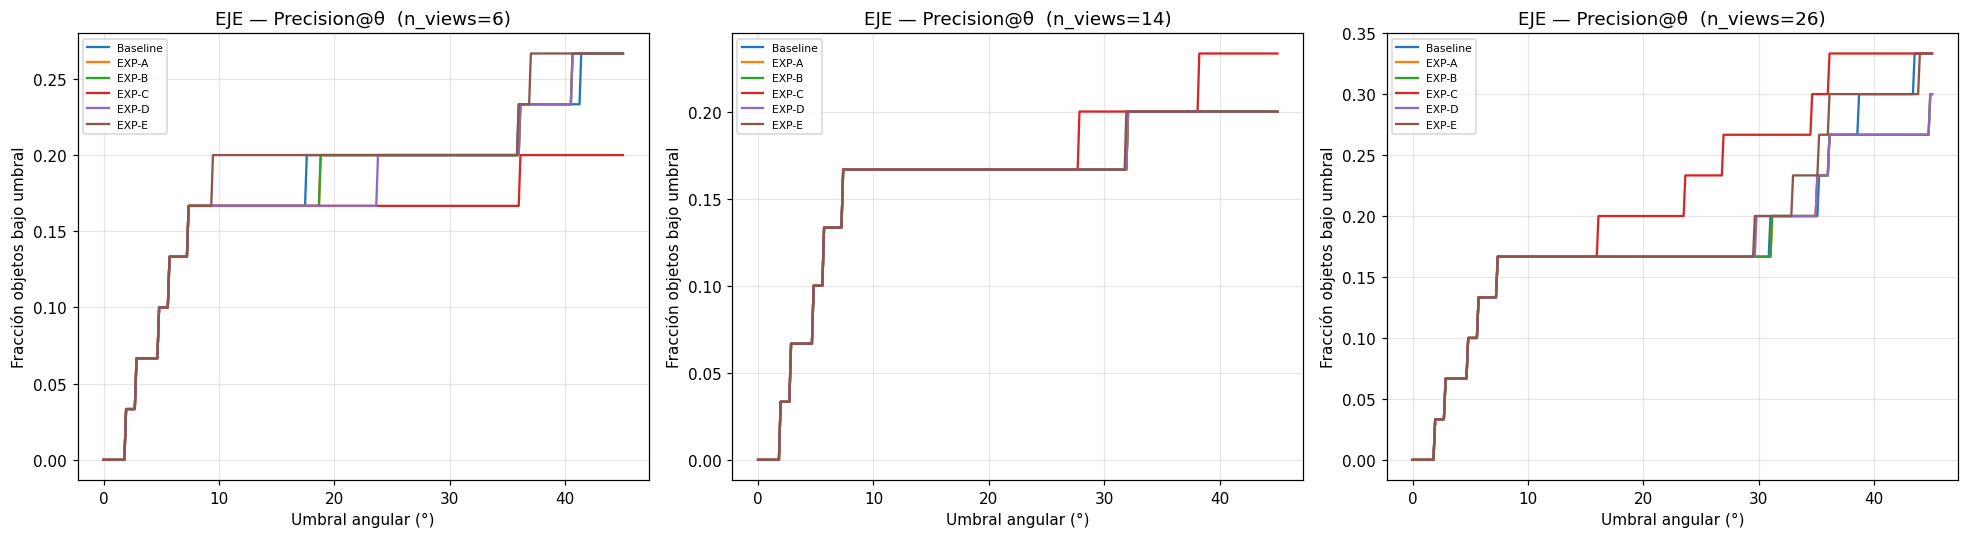

Guardado: ablation_axis_precision_curves.png


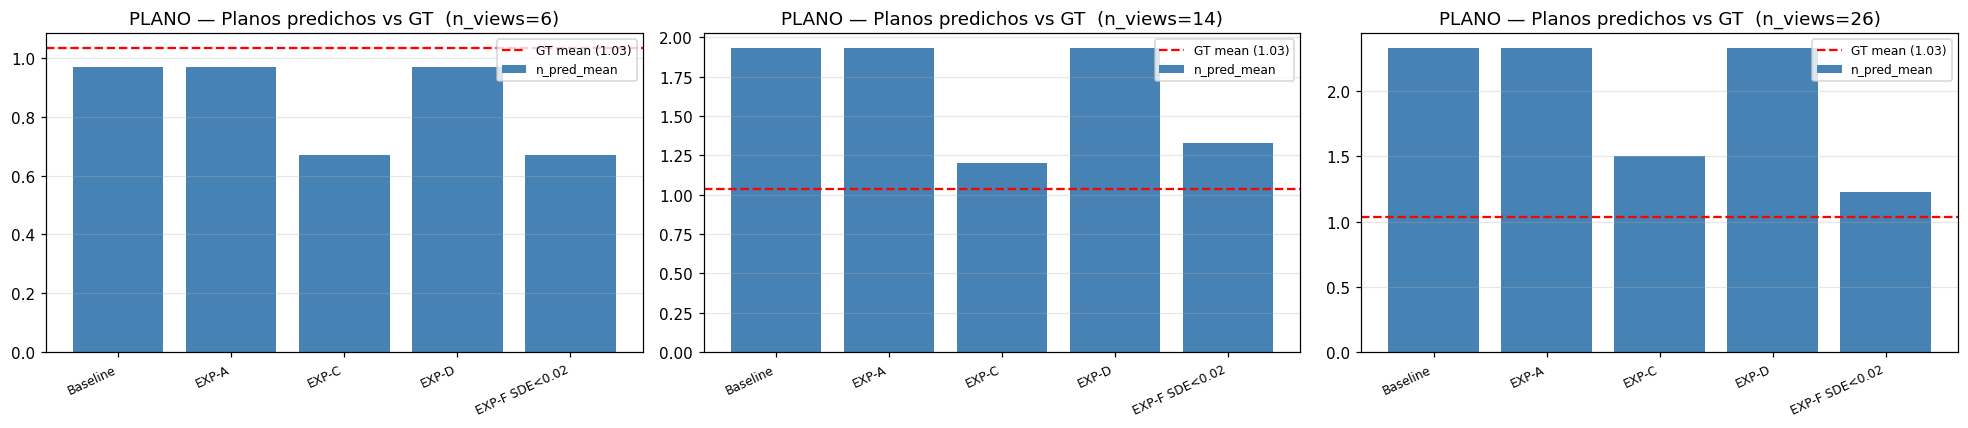

Guardado: ablation_plane_npred_vs_gt.png


In [34]:
# ── 12a: Per-object — eje ──────────────────────────────────────────────────
N_VIEWS_DIAG = 14

def extract_axis_errors(rows_): 
    df = pd.DataFrame(rows_)
    df["angular_error_deg"] = df["angular_error_deg"].fillna(90.0)
    sub = df[df["n_views"] == N_VIEWS_DIAG]
    return dict(zip(sub["object_id"], sub["angular_error_deg"]))

all_oids_axis = [oid for _, oid in OBJECT_LIST_AXIS]
exp_errors_axis = {
    "Baseline":   extract_axis_errors(rows_axis),
    "EXP-A":      extract_axis_errors(rows_A_axis),
    "EXP-B":      extract_axis_errors(rows_B_axis),
    "EXP-C":      extract_axis_errors(rows_C_axis),
    "EXP-D":      extract_axis_errors(rows_D_axis),
    "EXP-E":      extract_axis_errors(rows_E_axis),
}
df_per_obj_axis = pd.DataFrame({exp: [errs.get(oid, 90.0) for oid in all_oids_axis]
                                 for exp, errs in exp_errors_axis.items()},
                                index=all_oids_axis)
df_per_obj_axis["best_exp"] = df_per_obj_axis.idxmin(axis=1)
#df_per_obj_axis["delta"]    = (df_per_obj_axis.min(axis=1) - df_per_obj_axis["Baseline"]).round(2)

exp_cols = list(exp_errors_axis.keys())   # solo las columnas numéricas de experimentos
df_per_obj_axis["delta"] = (df_per_obj_axis[exp_cols].min(axis=1) - df_per_obj_axis["Baseline"]).round(2)

print(f"\n=== Per-object EJE (n_views={N_VIEWS_DIAG}) ===")
display(df_per_obj_axis[["Baseline","best_exp","delta"] + [e for e in exp_errors_axis if e!="Baseline"]].sort_values("delta"))
print("\nFrecuencia mejor experimento (eje):")
print(df_per_obj_axis["best_exp"].value_counts().to_string())

# ── 12b: Per-object — plano ─────────────────────────────────────────────────
def extract_plane_f1(rows_):
    df = pd.DataFrame(rows_); sub = df[df["n_views"] == N_VIEWS_DIAG]
    f1_map = {}
    for _, row in sub.iterrows():
        fc = row.get("f1_counts")
        if fc is None: f1_map[row["object_id"]] = 0.0; continue
        vals = [f1_from_counts(*fc[t]) for t in THRESHOLDS_INLIER]
        f1_map[row["object_id"]] = round(float(np.mean(vals)), 4)
    return f1_map

all_oids_plane = [oid for _, oid in OBJECT_LIST_PLANE]
exp_f1_plane = {
    "Baseline": extract_plane_f1(rows_plane),
    "EXP-A":    extract_plane_f1(rows_A_plane),
    "EXP-C":    extract_plane_f1(rows_C_plane),
    "EXP-D":    extract_plane_f1(rows_D_plane),
    f"EXP-F":   extract_plane_f1(rows_F_plane),
}
df_per_obj_plane = pd.DataFrame({exp: [f1s.get(oid, 0.0) for oid in all_oids_plane]
                                   for exp, f1s in exp_f1_plane.items()},
                                  index=all_oids_plane)
df_per_obj_plane["best_exp"] = df_per_obj_plane.idxmax(axis=1)
plane_exp_cols = list(exp_f1_plane.keys())
df_per_obj_plane["delta"] = (df_per_obj_plane[plane_exp_cols].max(axis=1) - df_per_obj_plane["Baseline"]).round(4)
print(f"\n=== Per-object PLANO F1_ref (n_views={N_VIEWS_DIAG}) ===")
display(df_per_obj_plane[["Baseline","best_exp","delta"]].sort_values("delta", ascending=False))
print("\nFrecuencia mejor experimento (plano):")
print(df_per_obj_plane["best_exp"].value_counts().to_string())

# ── 12c: Curvas Precision@theta — eje ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, nv in zip(axes, VIEW_GROUPS):
    for lbl, rows_ in [("Baseline", rows_axis), ("EXP-A", rows_A_axis),
                        ("EXP-B", rows_B_axis), ("EXP-C", rows_C_axis),
                        ("EXP-D", rows_D_axis), ("EXP-E", rows_E_axis)]:
        df_ = pd.DataFrame(rows_); df_["angular_error_deg"] = df_["angular_error_deg"].fillna(90.0)
        errs = df_[df_["n_views"]==nv]["angular_error_deg"].tolist()
        thetas = np.linspace(0, 45, 300)
        precs  = [(np.array(errs) <= t).mean() for t in thetas]
        ax.plot(thetas, precs, label=lbl)
    ax.set_xlabel("Umbral angular (°)"); ax.set_ylabel("Fracción objetos bajo umbral")
    ax.set_title(f"EJE — Precision@θ  (n_views={nv})"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("ablation_axis_precision_curves.png", dpi=150, bbox_inches="tight")
plt.show(); print("Guardado: ablation_axis_precision_curves.png")

# ── 12d: n_planes_predicted vs n_true — plano ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, nv in zip(axes, VIEW_GROUPS):
    experiments = [("Baseline", rows_plane), ("EXP-A", rows_A_plane),
                   ("EXP-C", rows_C_plane), ("EXP-D", rows_D_plane),
                   (f"EXP-F SDE<{SDE_GATE_F}", rows_F_plane)]
    labels = [lbl for lbl, _ in experiments]
    n_pred_means = []
    for _, rows_ in experiments:
        df_ = pd.DataFrame(rows_)
        val = df_[df_["n_views"]==nv]["n_planes_predicted"].mean()
        n_pred_means.append(round(val, 2) if not pd.isna(val) else 0)
    gt_mean = pd.DataFrame(rows_plane)[pd.DataFrame(rows_plane)["n_views"]==nv]["n_true_planes"].mean()
    x = np.arange(len(labels))
    ax.bar(x, n_pred_means, color="steelblue", label="n_pred_mean")
    ax.axhline(gt_mean, color="red", linestyle="--", label=f"GT mean ({gt_mean:.2f})")
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=8)
    ax.set_title(f"PLANO — Planos predichos vs GT  (n_views={nv})")
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("ablation_plane_npred_vs_gt.png", dpi=150, bbox_inches="tight")
plt.show(); print("Guardado: ablation_plane_npred_vs_gt.png")


---
## 13. Sweep de parámetros de detección de planos — impacto en F1_ref

Esta sección no requiere volver a correr el modelo. Reutiliza los datos de Molmo2
ya inferidos (`molmo_multiview_{EXPERIMENT_ID_PLANE}.json`) y la malla real
(`mesh_cache_plane`) para estudiar cómo los parámetros de control del detector
de planos afectan la F1_ref.

**Variables exploradas:**
| Parámetro | Descripción | Sweep |
|---|---|---|
| `max_planes` | Máximo de planos a detectar por objeto | {1, 2, 3} |
| `dup_angle_thresh_deg` | Umbral angular para considerar dos planos duplicados | {5°, 10°, 15°, 20°, 30°} |
| `sde_gate` | SDE_ref máximo para aceptar un plano adicional (gate geométrico) | {0.005, 0.01, 0.02, 0.05, ∞} |

**Hipótesis a verificar:**
- `max_planes=1` aumenta precisión pero baja recall para objetos con ≥2 planos GT.
- El umbral `dup_angle_thresh_deg` controla cuándo el detector abandona la búsqueda
  de un segundo plano: demasiado bajo → sobrepredicción; demasiado alto → sólo 1 plano siempre.
- Un `sde_gate` más restrictivo que el baseline elimina falsos positivos sin afectar
  objetos con planos reales bien estimados.


### 13.0 Runner genérico (sin modelo — solo reutiliza JSONs existentes)

In [35]:
# ── Runner genérico para sweep de parámetros (plano) ──────────────────────
# No llama al modelo. Reutiliza mesh_cache_plane y los JSONs de Molmo2.

def run_plane_sweep(experiment_id: str,
                    max_planes: int  = MAX_PLANES,
                    dup_angle_thresh_deg: float = DUP_ANGLE_THRESH_DEFAULT,
                    edge_on_thresh: float = EDGE_ON_THRESH_DEFAULT,
                    sde_gate: float | None = None) -> list[dict]:
    """
    Ejecuta detect_planes_no_mesh (o detect_planes_sde_gated si sde_gate != None)
    con los parámetros dados sobre todos los objetos de OBJECT_LIST_PLANE.
    Devuelve una lista de dicts lista para evaluación (misma estructura que rows_plane).

    Parameters
    ----------
    experiment_id       : ID del experimento de Molmo2 cuyos JSONs se leen
    max_planes          : máximo de planos a detectar por objeto
    dup_angle_thresh_deg: ángulo mínimo entre dos planos para no considerarlos duplicados
    edge_on_thresh      : umbral de alineación cámara-plano para clasificar una vista
                          como 'de canto' y excluirla del refit
    sde_gate            : si no es None, activa el gate geométrico por SDE_ref real;
                          solo se acepta un plano adicional si SDE_ref < sde_gate
    """
    rows = []
    for cat, oid in OBJECT_LIST_PLANE:
        gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["plane_sym"] / f"{oid}.txt")
        true_elements = gt["elements"]
        mesh_v, mesh_f, sample, gt_planes_ref = mesh_cache_plane[oid]

        render_dir = SANDBOX_RENDERS / "plane_sym" / oid / str(SIZE) / LIGHTING
        json_path  = render_dir / f"molmo_multiview_{experiment_id}.json"
        if not json_path.exists():
            continue
        molmo_data = json.load(open(json_path, encoding="utf-8"))

        for n_views in VIEW_GROUPS:
            group = molmo_data.get(str(n_views), {})
            pts_by_img = group.get("points_by_image", {})
            imgs_sent  = group.get("images_sent", [])

            try:
                if sde_gate is not None:
                    # Gate geométrico con SDE_ref real (EXP-F adaptado)
                    planes = detect_planes_sde_gated(
                        pts_by_img, imgs_sent, DEFAULT_FOV, SIZE,
                        mesh_v, mesh_f, sample,
                        sde_gate=sde_gate,
                        max_planes=max_planes,
                        edge_on_thresh=edge_on_thresh,
                        dup_angle_thresh_deg=dup_angle_thresh_deg,
                    )
                else:
                    planes = detect_planes_no_mesh(
                        pts_by_img, imgs_sent, DEFAULT_FOV, SIZE,
                        edge_on_thresh=edge_on_thresh,
                        max_planes=max_planes,
                        dup_angle_thresh_deg=dup_angle_thresh_deg,
                    )
            except (ValueError, Exception):
                planes = []

            rows.append(_eval_plane_row(
                cat, oid, n_views, planes, true_elements,
                mesh_v, mesh_f, sample, gt_planes_ref
            ))

    return rows


def f1_ref_from_rows(rows: list[dict]) -> dict[int, float]:
    """Agrega F1_ref por n_views a partir de una lista de rows."""
    df = pd.DataFrame(rows)
    result = {}
    for nv, grp in df.groupby("n_views"):
        totals = {t: [0, 0, 0] for t in THRESHOLDS_INLIER}
        for fc in grp["f1_counts"].dropna():
            for t in THRESHOLDS_INLIER:
                tp, fp, fn = fc[t]
                totals[t][0] += tp; totals[t][1] += fp; totals[t][2] += fn
        vals = [f1_from_counts(*totals[t]) for t in THRESHOLDS_INLIER]
        result[int(nv)] = round(float(np.mean(vals)), 4)
    return result


def npred_mean_from_rows(rows: list[dict]) -> dict[int, float]:
    """n_planes_predicted medio por n_views."""
    df = pd.DataFrame(rows)
    return {int(nv): round(grp["n_planes_predicted"].mean(), 3)
            for nv, grp in df.groupby("n_views")}


print("Runner listo. Ninguna celda de este bloque carga el modelo.")


Runner listo. Ninguna celda de este bloque carga el modelo.


### 13.1 Sweep de `max_planes` ∈ {1, 2, 3}

Fija todos los demás parámetros en sus valores por defecto y varía únicamente
el número máximo de planos que puede detectar el sistema por objeto.

**Pregunta clave**: ¿en qué punto la ganancia en recall de añadir planos extra
deja de compensar la pérdida en precisión por falsos positivos?


  max_planes=1 ... 

/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/gpytoolbox/barycentric_coordinates.py:104: RuntimeWarning: invalid value encountered in divide
  gamma = np.sum(np.multiply(np.cross(u,w,axis=1),N),axis=1)/n2
/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/gpytoolbox/barycentric_coordinates.py:105: RuntimeWarning: invalid value encountered in divide
  beta = np.sum(np.multiply(np.cross(w,v,axis=1),N),axis=1)/n2


OK
  max_planes=2 ... OK
  max_planes=3 ... OK

=== F1_ref por max_planes y n_views ===


max_planes,1,2,3
n_views,,,
6,0.2500,0.2500,0.2500
14,0.4597,0.4324,0.4324
26,0.1167,0.0849,0.1668



=== n_planes_predicted medio (GT promedio ≈ 1.18) ===


max_planes (n_pred_mean),1,2,3
n_views,,,
6,0.967,0.967,0.967
14,1.000,1.933,1.933
26,0.967,1.700,2.333


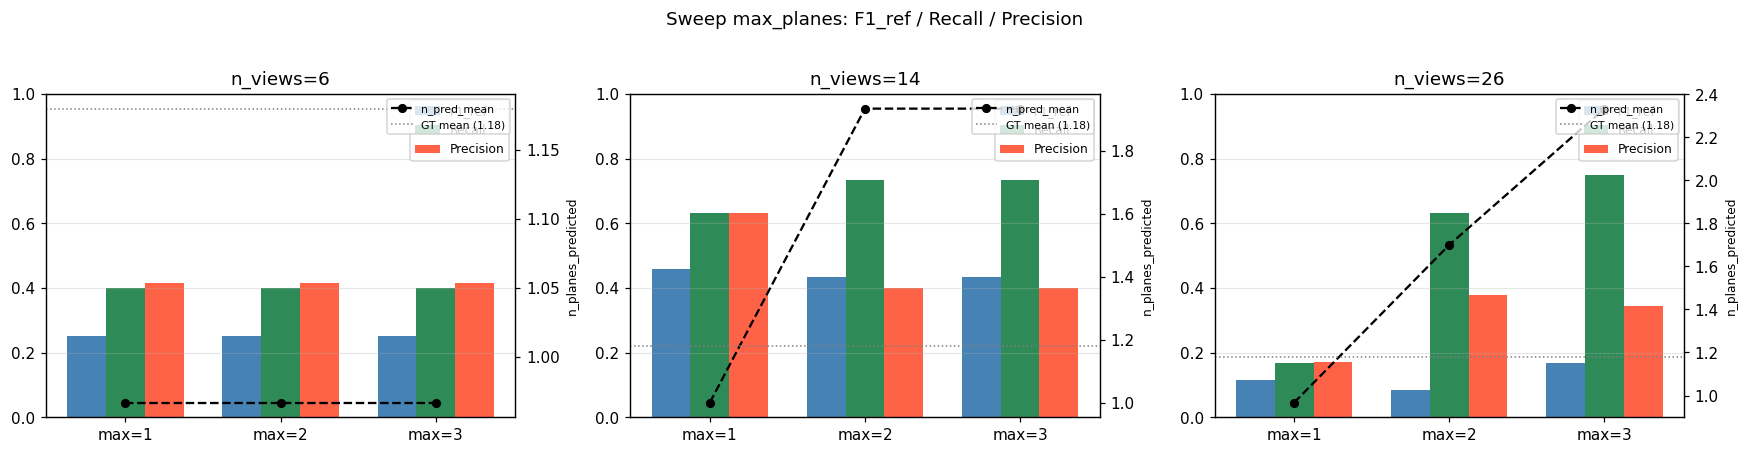

Guardado: sweep_max_planes.png


In [36]:
# ── 13.1: Sweep max_planes ─────────────────────────────────────────────────
MAX_PLANES_SWEEP = [1, 2, 3]

sweep_mp_results = {}   # max_planes -> {n_views -> f1_ref}
sweep_mp_npred   = {}   # max_planes -> {n_views -> n_planes_predicted_mean}
sweep_mp_recall  = {}
sweep_mp_prec    = {}

for mp in MAX_PLANES_SWEEP:
    print(f"  max_planes={mp} ...", end=" ", flush=True)
    rows = run_plane_sweep(EXPERIMENT_ID_PLANE, max_planes=mp)
    sweep_mp_results[mp] = f1_ref_from_rows(rows)
    sweep_mp_npred[mp]   = npred_mean_from_rows(rows)
    df_ = pd.DataFrame(rows)
    sweep_mp_recall[mp] = {
        int(nv): round(grp["recall_planes"].mean(), 4)
        for nv, grp in df_.groupby("n_views")
    }
    sweep_mp_prec[mp] = {
        int(nv): round(grp["precision_planes"].dropna().mean(), 4)
        for nv, grp in df_.groupby("n_views")
    }
    print("OK")

# ── Tabla resumen F1_ref ────────────────────────────────────────────────────
df_mp_f1 = pd.DataFrame(sweep_mp_results, index=VIEW_GROUPS).rename_axis("n_views")
df_mp_f1.columns.name = "max_planes"
print("\n=== F1_ref por max_planes y n_views ===")
display(df_mp_f1)

df_mp_npred = pd.DataFrame(sweep_mp_npred, index=VIEW_GROUPS).rename_axis("n_views")
df_mp_npred.columns.name = "max_planes (n_pred_mean)"
print("\n=== n_planes_predicted medio (GT promedio ≈ 1.18) ===")
display(df_mp_npred)

# ── Visualización ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, nv in zip(axes, VIEW_GROUPS):
    mp_vals  = MAX_PLANES_SWEEP
    f1_vals  = [sweep_mp_results[mp].get(nv, 0) for mp in mp_vals]
    rec_vals = [sweep_mp_recall[mp].get(nv, 0) for mp in mp_vals]
    pre_vals = [sweep_mp_prec[mp].get(nv, 0)   for mp in mp_vals]

    x = np.arange(len(mp_vals))
    w = 0.25
    ax.bar(x - w, f1_vals,  width=w, label="F1_ref",    color="steelblue")
    ax.bar(x,     rec_vals, width=w, label="Recall",     color="seagreen")
    ax.bar(x + w, pre_vals, width=w, label="Precision",  color="tomato")

    ax2 = ax.twinx()
    ax2.plot(x, [sweep_mp_npred[mp].get(nv, 0) for mp in mp_vals],
             "k--o", markersize=5, label="n_pred_mean")
    ax2.axhline(1.18, color="gray", linestyle=":", linewidth=1, label="GT mean (1.18)")
    ax2.set_ylabel("n_planes_predicted", fontsize=8)
    ax2.legend(fontsize=7, loc="upper right")

    ax.set_xticks(x); ax.set_xticklabels([f"max={mp}" for mp in mp_vals])
    ax.set_title(f"n_views={nv}"); ax.set_ylim(0, 1.0)
    ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

plt.suptitle("Sweep max_planes: F1_ref / Recall / Precision", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("sweep_max_planes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: sweep_max_planes.png")


### 13.2 Sweep de `dup_angle_thresh_deg` con `max_planes=3`

El umbral de duplicados controla cuándo se considera que un nuevo plano candidato
es demasiado parecido a uno ya detectado y se abandona la búsqueda.

- **Umbral bajo** (ej. 5°): dos planos necesitan ser casi perpendiculares para no
  considerarse duplicados → el detector acepta más planos → más recall pero más
  falsos positivos.
- **Umbral alto** (ej. 30°): cualquier plano candidato cuya normal esté a menos de
  30° de uno ya encontrado se descarta → el detector termina antes → mayor precisión
  pero menor recall para objetos con múltiples planos cercanos en orientación.


  dup_angle_thresh=5.0° ... 

/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/gpytoolbox/barycentric_coordinates.py:104: RuntimeWarning: invalid value encountered in divide
  gamma = np.sum(np.multiply(np.cross(u,w,axis=1),N),axis=1)/n2
/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/gpytoolbox/barycentric_coordinates.py:105: RuntimeWarning: invalid value encountered in divide
  beta = np.sum(np.multiply(np.cross(w,v,axis=1),N),axis=1)/n2


OK
  dup_angle_thresh=10.0° ... OK
  dup_angle_thresh=15.0° ... OK
  dup_angle_thresh=20.0° ... OK
  dup_angle_thresh=30.0° ... OK

=== F1_ref por dup_angle_thresh y n_views (max_planes=3) ===


,dup=5.0°,dup=10.0°,dup=15.0°,dup=20.0°,dup=30.0°
n_views,,,,,
6,0.2500,0.2500,0.2500,0.2500,0.2500
14,0.4324,0.4324,0.4324,0.4324,0.4324
26,0.1668,0.1668,0.1668,0.1668,0.1684



=== n_planes_predicted medio ===


,dup=5.0°,dup=10.0°,dup=15.0°,dup=20.0°,dup=30.0°
n_views,,,,,
6,0.967,0.967,0.967,0.967,0.967
14,1.933,1.933,1.933,1.933,1.933
26,2.333,2.333,2.333,2.333,2.300


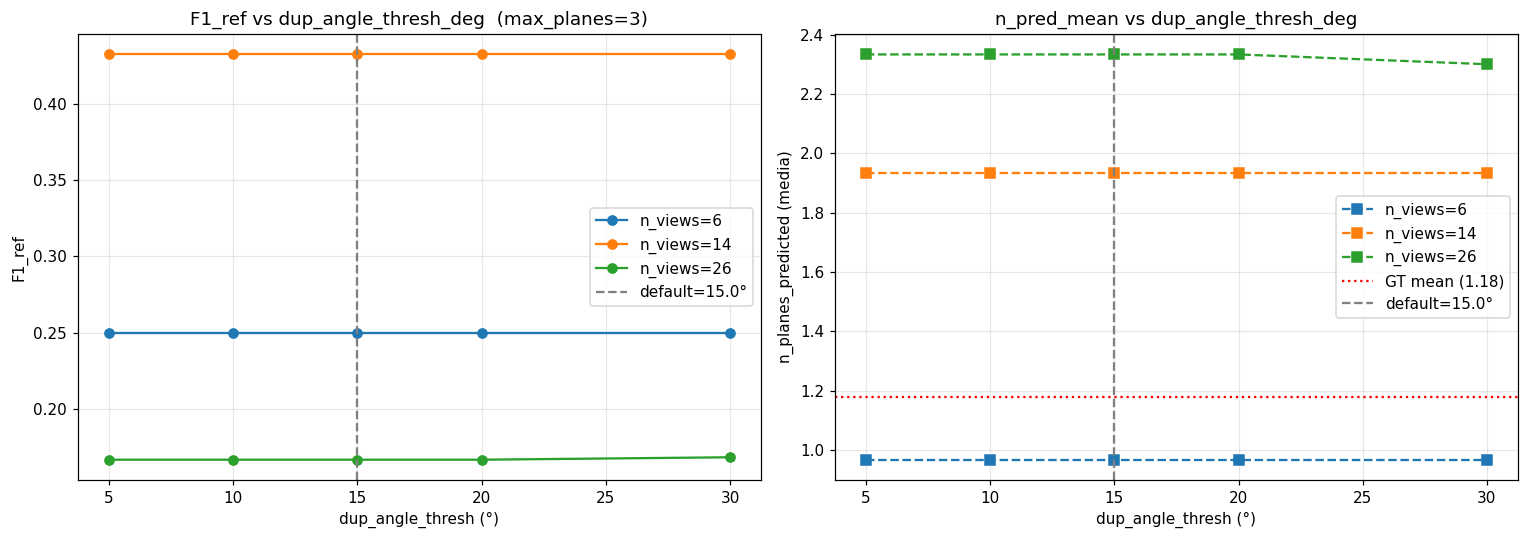

Guardado: sweep_dup_angle.png


In [37]:
# ── 13.2: Sweep dup_angle_thresh_deg ───────────────────────────────────────
DUP_THRESH_SWEEP = [5.0, 10.0, 15.0, 20.0, 30.0]   # grados

sweep_dup_results = {}
sweep_dup_npred   = {}
sweep_dup_recall  = {}
sweep_dup_prec    = {}

for dt in DUP_THRESH_SWEEP:
    print(f"  dup_angle_thresh={dt}° ...", end=" ", flush=True)
    rows = run_plane_sweep(EXPERIMENT_ID_PLANE, max_planes=3, dup_angle_thresh_deg=dt)
    sweep_dup_results[dt] = f1_ref_from_rows(rows)
    sweep_dup_npred[dt]   = npred_mean_from_rows(rows)
    df_ = pd.DataFrame(rows)
    sweep_dup_recall[dt] = {int(nv): round(grp["recall_planes"].mean(), 4)
                             for nv, grp in df_.groupby("n_views")}
    sweep_dup_prec[dt]   = {int(nv): round(grp["precision_planes"].dropna().mean(), 4)
                             for nv, grp in df_.groupby("n_views")}
    print("OK")

# ── Tabla ───────────────────────────────────────────────────────────────────
df_dup_f1 = pd.DataFrame(sweep_dup_results, index=VIEW_GROUPS).rename_axis("n_views")
df_dup_f1.columns = [f"dup={d}°" for d in DUP_THRESH_SWEEP]
print("\n=== F1_ref por dup_angle_thresh y n_views (max_planes=3) ===")
display(df_dup_f1)

df_dup_npred = pd.DataFrame(sweep_dup_npred, index=VIEW_GROUPS).rename_axis("n_views")
df_dup_npred.columns = [f"dup={d}°" for d in DUP_THRESH_SWEEP]
print("\n=== n_planes_predicted medio ===")
display(df_dup_npred)

# ── Curvas F1 vs dup_angle por n_views ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax_f1, ax_np in (axes,):
    for nv in VIEW_GROUPS:
        f1s = [sweep_dup_results[dt].get(nv, 0) for dt in DUP_THRESH_SWEEP]
        ax_f1.plot(DUP_THRESH_SWEEP, f1s, "o-", label=f"n_views={nv}")
    ax_f1.axvline(DUP_ANGLE_THRESH_DEFAULT, color="gray", linestyle="--",
                  label=f"default={DUP_ANGLE_THRESH_DEFAULT}°")
    ax_f1.set_xlabel("dup_angle_thresh (°)"); ax_f1.set_ylabel("F1_ref")
    ax_f1.set_title("F1_ref vs dup_angle_thresh_deg  (max_planes=3)")
    ax_f1.legend(); ax_f1.grid(alpha=0.3)

    for nv in VIEW_GROUPS:
        nps = [sweep_dup_npred[dt].get(nv, 0) for dt in DUP_THRESH_SWEEP]
        ax_np.plot(DUP_THRESH_SWEEP, nps, "s--", label=f"n_views={nv}")
    ax_np.axhline(1.18, color="red", linestyle=":", label="GT mean (1.18)")
    ax_np.axvline(DUP_ANGLE_THRESH_DEFAULT, color="gray", linestyle="--",
                  label=f"default={DUP_ANGLE_THRESH_DEFAULT}°")
    ax_np.set_xlabel("dup_angle_thresh (°)"); ax_np.set_ylabel("n_planes_predicted (media)")
    ax_np.set_title("n_pred_mean vs dup_angle_thresh_deg")
    ax_np.legend(); ax_np.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("sweep_dup_angle.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: sweep_dup_angle.png")


### 13.3 Sweep del gate geométrico `sde_gate` (con `max_planes=3`)

Varía el umbral de SDE_ref usado como criterio de parada en el detector iterativo
(EXP-F). Un gate más restrictivo acepta menos planos → mayor precisión; uno más
permisivo equivale a no usar gate (`sde_gate=∞`).

`sde_gate=None` en el runner desactiva el gate y equivale al baseline `detect_planes_no_mesh`.


  sde_gate=0.005 ... 

/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/gpytoolbox/barycentric_coordinates.py:104: RuntimeWarning: invalid value encountered in divide
  gamma = np.sum(np.multiply(np.cross(u,w,axis=1),N),axis=1)/n2
/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/gpytoolbox/barycentric_coordinates.py:105: RuntimeWarning: invalid value encountered in divide
  beta = np.sum(np.multiply(np.cross(w,v,axis=1),N),axis=1)/n2


OK
  sde_gate=0.01 ... OK
  sde_gate=0.015 ... OK
  sde_gate=0.02 ... OK
  sde_gate=0.03 ... OK
  sde_gate=0.05 ... OK
  sde_gate=∞ (sin gate) ... OK

=== F1_ref por sde_gate y n_views (max_planes=3) ===


,0.005,0.01,0.015,0.02,0.03,0.05,∞ (sin gate)
n_views,,,,,,,
6,0.3947,0.3571,0.3571,0.3571,0.3409,0.2778,0.2500
14,0.5588,0.5000,0.4758,0.4758,0.4692,0.4706,0.4324
26,0.3103,0.2861,0.2861,0.2590,0.2423,0.1754,0.1668



=== n_planes_predicted medio ===


,0.005,0.01,0.015,0.02,0.03,0.05,∞ (sin gate)
n_views,,,,,,,
6,0.600,0.667,0.667,0.667,0.700,0.867,0.967
14,0.933,1.200,1.300,1.333,1.700,1.800,1.933
26,0.600,0.867,0.867,1.233,1.333,2.200,2.333


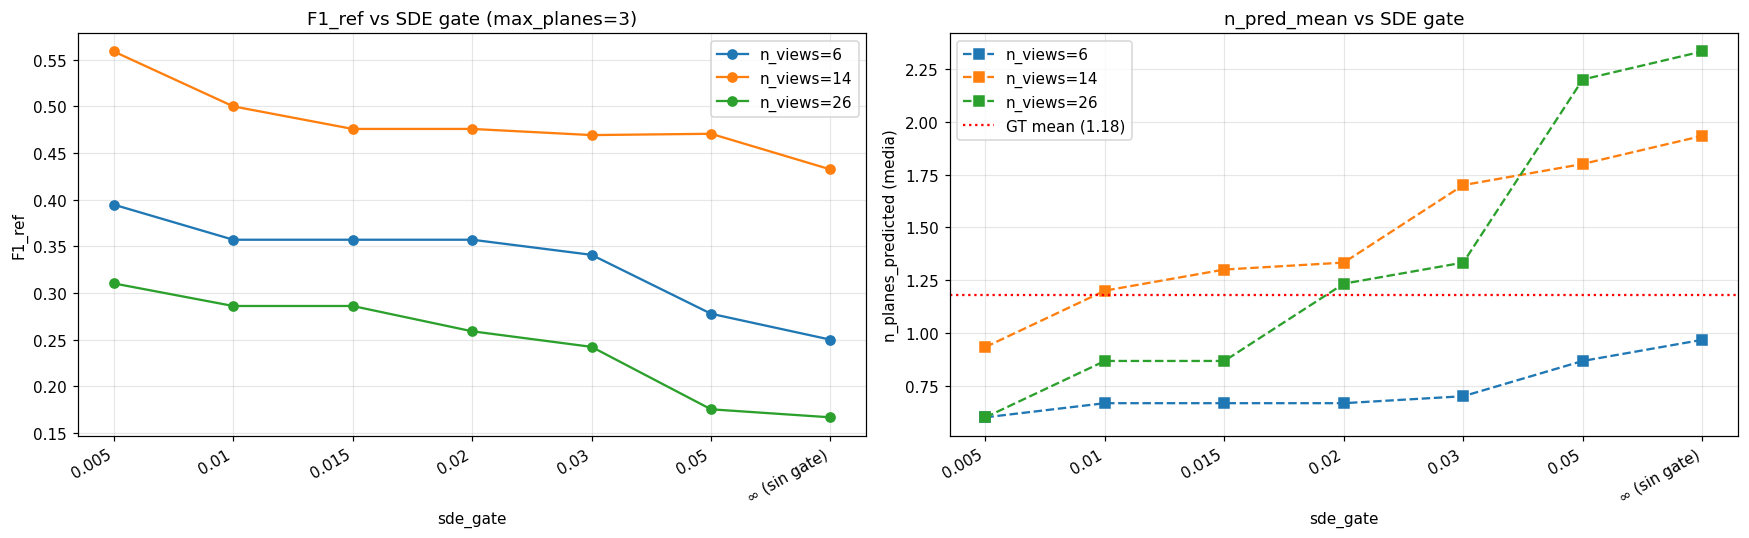

Guardado: sweep_sde_gate.png


In [38]:
# ── 13.3: Sweep SDE gate ────────────────────────────────────────────────────
# None = sin gate (baseline); float = activar EXP-F con ese umbral
SDE_GATE_SWEEP = [0.005, 0.010, 0.015, 0.020, 0.030, 0.050, None]
SDE_GATE_LABELS = [str(g) if g is not None else "∞ (sin gate)" for g in SDE_GATE_SWEEP]

sweep_sde_results = {}
sweep_sde_npred   = {}
sweep_sde_recall  = {}
sweep_sde_prec    = {}

for gate, label in zip(SDE_GATE_SWEEP, SDE_GATE_LABELS):
    print(f"  sde_gate={label} ...", end=" ", flush=True)
    rows = run_plane_sweep(EXPERIMENT_ID_PLANE, max_planes=3, sde_gate=gate)
    sweep_sde_results[label] = f1_ref_from_rows(rows)
    sweep_sde_npred[label]   = npred_mean_from_rows(rows)
    df_ = pd.DataFrame(rows)
    sweep_sde_recall[label] = {int(nv): round(grp["recall_planes"].mean(), 4)
                                for nv, grp in df_.groupby("n_views")}
    sweep_sde_prec[label]   = {int(nv): round(grp["precision_planes"].dropna().mean(), 4)
                                for nv, grp in df_.groupby("n_views")}
    print("OK")

# ── Tabla ───────────────────────────────────────────────────────────────────
df_sde_f1 = pd.DataFrame(sweep_sde_results, index=VIEW_GROUPS).rename_axis("n_views")
print("\n=== F1_ref por sde_gate y n_views (max_planes=3) ===")
display(df_sde_f1)

df_sde_npred = pd.DataFrame(sweep_sde_npred, index=VIEW_GROUPS).rename_axis("n_views")
print("\n=== n_planes_predicted medio ===")
display(df_sde_npred)

# ── Curvas F1 y n_pred vs sde_gate ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax_f1, ax_np = axes
x_ticks = range(len(SDE_GATE_LABELS))

for nv in VIEW_GROUPS:
    f1s = [sweep_sde_results[lbl].get(nv, 0) for lbl in SDE_GATE_LABELS]
    ax_f1.plot(x_ticks, f1s, "o-", label=f"n_views={nv}")
ax_f1.set_xticks(x_ticks); ax_f1.set_xticklabels(SDE_GATE_LABELS, rotation=30, ha="right")
ax_f1.set_xlabel("sde_gate"); ax_f1.set_ylabel("F1_ref")
ax_f1.set_title("F1_ref vs SDE gate (max_planes=3)")
ax_f1.legend(); ax_f1.grid(alpha=0.3)

for nv in VIEW_GROUPS:
    nps = [sweep_sde_npred[lbl].get(nv, 0) for lbl in SDE_GATE_LABELS]
    ax_np.plot(x_ticks, nps, "s--", label=f"n_views={nv}")
ax_np.axhline(1.18, color="red", linestyle=":", label="GT mean (1.18)")
ax_np.set_xticks(x_ticks); ax_np.set_xticklabels(SDE_GATE_LABELS, rotation=30, ha="right")
ax_np.set_xlabel("sde_gate"); ax_np.set_ylabel("n_planes_predicted (media)")
ax_np.set_title("n_pred_mean vs SDE gate")
ax_np.legend(); ax_np.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("sweep_sde_gate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: sweep_sde_gate.png")


### 13.4 Tabla global de mejores configuraciones

Identifica la combinación de `max_planes` + `dup_angle_thresh_deg` + `sde_gate`
que maximiza F1_ref para cada n_views, y reporta el n_planes_predicted asociado.


In [39]:
# ── 13.4: Tabla global de mejores configuraciones ──────────────────────────
# Construye un DataFrame con todas las combinaciones probadas

records = []

# max_planes sweep (dup y gate en default)
for mp in MAX_PLANES_SWEEP:
    for nv in VIEW_GROUPS:
        records.append({
            "max_planes":      mp,
            "dup_angle_thresh": DUP_ANGLE_THRESH_DEFAULT,
            "sde_gate":        "∞ (sin gate)",
            "n_views":         nv,
            "F1_ref":          sweep_mp_results[mp].get(nv, 0),
            "n_pred_mean":     sweep_mp_npred[mp].get(nv, 0),
            "recall":          sweep_mp_recall[mp].get(nv, 0),
            "precision":       sweep_mp_prec[mp].get(nv, 0),
        })

# dup_angle sweep (max=3, gate default)
for dt in DUP_THRESH_SWEEP:
    for nv in VIEW_GROUPS:
        lbl = f"dup={dt}°"
        records.append({
            "max_planes":      3,
            "dup_angle_thresh": dt,
            "sde_gate":        "∞ (sin gate)",
            "n_views":         nv,
            "F1_ref":          sweep_dup_results[dt].get(nv, 0),
            "n_pred_mean":     sweep_dup_npred[dt].get(nv, 0),
            "recall":          sweep_dup_recall[dt].get(nv, 0),
            "precision":       sweep_dup_prec[dt].get(nv, 0),
        })

# sde_gate sweep (max=3, dup default)
for gate, label in zip(SDE_GATE_SWEEP, SDE_GATE_LABELS):
    for nv in VIEW_GROUPS:
        records.append({
            "max_planes":      3,
            "dup_angle_thresh": DUP_ANGLE_THRESH_DEFAULT,
            "sde_gate":        label,
            "n_views":         nv,
            "F1_ref":          sweep_sde_results[label].get(nv, 0),
            "n_pred_mean":     sweep_sde_npred[label].get(nv, 0),
            "recall":          sweep_sde_recall[label].get(nv, 0),
            "precision":       sweep_sde_prec[label].get(nv, 0),
        })

df_global = pd.DataFrame(records).drop_duplicates()

print("=== Top 5 configuraciones por F1_ref (por n_views) ===")
for nv in VIEW_GROUPS:
    sub = df_global[df_global["n_views"] == nv].sort_values("F1_ref", ascending=False).head(5)
    print(f"\n--- n_views={nv} ---")
    display(sub[["max_planes","dup_angle_thresh","sde_gate",
                 "F1_ref","n_pred_mean","recall","precision"]].reset_index(drop=True))

# Baseline para comparar
baseline_f1 = f1_ref_from_rows(list(rows_plane))
print("\n=== Baseline F1_ref (max_planes=3, defaults sin gate) ===")
for nv in VIEW_GROUPS:
    best_row = df_global[df_global["n_views"]==nv].sort_values("F1_ref", ascending=False).iloc[0]
    delta = round(best_row["F1_ref"] - baseline_f1.get(nv, 0), 4)
    print(f"  n_views={nv}: baseline={baseline_f1.get(nv,0):.4f}  "
          f"→ mejor={best_row['F1_ref']:.4f}  (Δ={delta:+.4f})  "
          f"[max_planes={best_row['max_planes']}, dup={best_row['dup_angle_thresh']}°, gate={best_row['sde_gate']}]")


=== Top 5 configuraciones por F1_ref (por n_views) ===

--- n_views=6 ---


,max_planes,dup_angle_thresh,sde_gate,F1_ref,n_pred_mean,recall,precision
0,3,15.0,0.005,0.3947,0.600,0.4,0.6667
1,3,15.0,0.015,0.3571,0.667,0.4,0.6000
2,3,15.0,0.02,0.3571,0.667,0.4,0.6000
3,3,15.0,0.01,0.3571,0.667,0.4,0.6000
4,3,15.0,0.03,0.3409,0.700,0.4,0.5714



--- n_views=14 ---


,max_planes,dup_angle_thresh,sde_gate,F1_ref,n_pred_mean,recall,precision
0,3,15.0,0.005,0.5588,0.933,0.6333,0.7292
1,3,15.0,0.01,0.5000,1.200,0.6333,0.6400
2,3,15.0,0.02,0.4758,1.333,0.6667,0.6154
3,3,15.0,0.015,0.4758,1.300,0.6667,0.6346
4,3,15.0,0.05,0.4706,1.800,0.7333,0.4286



--- n_views=26 ---


,max_planes,dup_angle_thresh,sde_gate,F1_ref,n_pred_mean,recall,precision
0,3,15.0,0.005,0.3103,0.600,0.3000,0.5909
1,3,15.0,0.01,0.2861,0.867,0.3667,0.5000
2,3,15.0,0.015,0.2861,0.867,0.3667,0.5000
3,3,15.0,0.02,0.2590,1.233,0.4500,0.3981
4,3,15.0,0.03,0.2423,1.333,0.4833,0.3947



=== Baseline F1_ref (max_planes=3, defaults sin gate) ===
  n_views=6: baseline=0.2500  → mejor=0.3947  (Δ=+0.1447)  [max_planes=3, dup=15.0°, gate=0.005]
  n_views=14: baseline=0.4324  → mejor=0.5588  (Δ=+0.1264)  [max_planes=3, dup=15.0°, gate=0.005]
  n_views=26: baseline=0.1668  → mejor=0.3103  (Δ=+0.1435)  [max_planes=3, dup=15.0°, gate=0.005]


### 13.5 Heatmap: F1_ref en función de max_planes × dup_angle_thresh

Visualiza el espacio de parámetros {max_planes, dup_angle_thresh} para el n_views
que obtuvo el mejor F1_ref en el sweep anterior.


Corriendo sweep combinado max_planes × dup_angle_thresh ...
(Si quieres saltarlo, comenta la celda — los resultados anteriores ya son útiles)

  max_planes=1, dup=5.0° ... 

/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/gpytoolbox/barycentric_coordinates.py:104: RuntimeWarning: invalid value encountered in divide
  gamma = np.sum(np.multiply(np.cross(u,w,axis=1),N),axis=1)/n2
/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/gpytoolbox/barycentric_coordinates.py:105: RuntimeWarning: invalid value encountered in divide
  beta = np.sum(np.multiply(np.cross(w,v,axis=1),N),axis=1)/n2


OK
  max_planes=1, dup=10.0° ... OK
  max_planes=1, dup=15.0° ... OK
  max_planes=1, dup=20.0° ... OK
  max_planes=1, dup=30.0° ... OK
  max_planes=2, dup=5.0° ... OK
  max_planes=2, dup=10.0° ... OK
  max_planes=2, dup=15.0° ... OK
  max_planes=2, dup=20.0° ... OK
  max_planes=2, dup=30.0° ... OK

Heatmap para n_views=14 (mejor n_views en baseline):


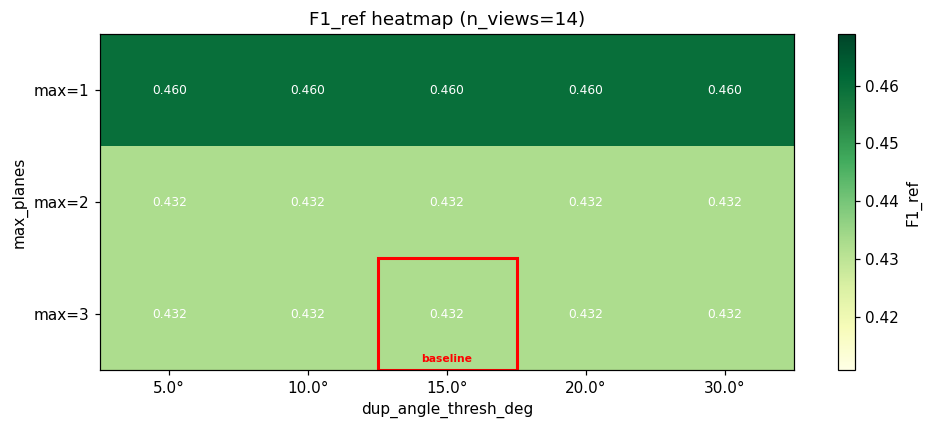

Guardado: heatmap_maxplanes_dup.png


In [40]:
# ── 13.5: Heatmap max_planes × dup_angle_thresh ────────────────────────────
# Requiere correr este sweep combinado adicional (puede tardar ~1-2 min)
print("Corriendo sweep combinado max_planes × dup_angle_thresh ...")
print("(Si quieres saltarlo, comenta la celda — los resultados anteriores ya son útiles)\n")

heatmap_data = {}   # (max_planes, dup_thresh) -> {nv -> f1_ref}

for mp in MAX_PLANES_SWEEP:
    for dt in DUP_THRESH_SWEEP:
        if (mp == MAX_PLANES and dt == DUP_ANGLE_THRESH_DEFAULT):
            # Baseline ya calculado
            heatmap_data[(mp, dt)] = sweep_mp_results[mp]
            continue
        if mp == MAX_PLANES and dt != DUP_ANGLE_THRESH_DEFAULT:
            # Ya tenemos este punto del sweep de dup
            heatmap_data[(mp, dt)] = sweep_dup_results[dt]
            continue
        # Solo calcular las combinaciones no vistas aún
        print(f"  max_planes={mp}, dup={dt}° ...", end=" ", flush=True)
        rows_ = run_plane_sweep(EXPERIMENT_ID_PLANE, max_planes=mp, dup_angle_thresh_deg=dt)
        heatmap_data[(mp, dt)] = f1_ref_from_rows(rows_)
        print("OK")

# ── Elegir el n_views con mejor F1_ref en el baseline para el heatmap
best_nv = max(VIEW_GROUPS, key=lambda nv: baseline_f1.get(nv, 0))
print(f"\nHeatmap para n_views={best_nv} (mejor n_views en baseline):")

heat_matrix = np.zeros((len(MAX_PLANES_SWEEP), len(DUP_THRESH_SWEEP)))
for i, mp in enumerate(MAX_PLANES_SWEEP):
    for j, dt in enumerate(DUP_THRESH_SWEEP):
        heat_matrix[i, j] = heatmap_data.get((mp, dt), {}).get(best_nv, 0.0)

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(heat_matrix, aspect="auto", cmap="YlGn",
               vmin=heat_matrix.min() * 0.95, vmax=heat_matrix.max() * 1.02)
ax.set_xticks(range(len(DUP_THRESH_SWEEP)))
ax.set_xticklabels([f"{d}°" for d in DUP_THRESH_SWEEP])
ax.set_yticks(range(len(MAX_PLANES_SWEEP)))
ax.set_yticklabels([f"max={mp}" for mp in MAX_PLANES_SWEEP])
ax.set_xlabel("dup_angle_thresh_deg"); ax.set_ylabel("max_planes")
ax.set_title(f"F1_ref heatmap (n_views={best_nv})")
plt.colorbar(im, ax=ax, label="F1_ref")

# Anotar valores
for i in range(heat_matrix.shape[0]):
    for j in range(heat_matrix.shape[1]):
        ax.text(j, i, f"{heat_matrix[i,j]:.3f}", ha="center", va="center",
                fontsize=8, color="black" if heat_matrix[i,j] < heat_matrix.max()*0.85 else "white")

# Marcar el baseline (max=3, dup=15°)
mp_idx  = MAX_PLANES_SWEEP.index(MAX_PLANES) if MAX_PLANES in MAX_PLANES_SWEEP else -1
dup_idx = DUP_THRESH_SWEEP.index(DUP_ANGLE_THRESH_DEFAULT) if DUP_ANGLE_THRESH_DEFAULT in DUP_THRESH_SWEEP else -1
if mp_idx >= 0 and dup_idx >= 0:
    rect = plt.Rectangle((dup_idx-0.5, mp_idx-0.5), 1, 1,
                          linewidth=2, edgecolor="red", facecolor="none")
    ax.add_patch(rect)
    ax.text(dup_idx, mp_idx + 0.4, "baseline", ha="center", va="center",
            fontsize=7, color="red", fontweight="bold")

plt.tight_layout()
plt.savefig("heatmap_maxplanes_dup.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Guardado: heatmap_maxplanes_dup.png")


# ── Sección 14: Efecto del descarte de vistas por puntos fuera del objeto ───
No requiere volver a correr el modelo.
Reutiliza molmo_multiview_{EXPERIMENT_ID_*.json} y mesh_cache_axis/plane.

Se prueban 3 políticas de descarte de vistas, aplicadas ANTES de triangular:

   POLICY_NONE   : sin filtro (equivale al baseline con FILTER_OFF_OBJECT=False)
   POLICY_ANY    : descartar vista si AL MENOS UN punto está fuera del objeto
   POLICY_BOTH   : descartar vista si AMBOS puntos están fuera del objeto

 Para 2 puntos por vista (prompts actuales):
   POLICY_ANY  = conservador: cualquier punto malo invalida la vista completa
   POLICY_BOTH = permisivo:   solo descarta si los dos están en el fondo


In [41]:
import numpy as np
import pandas as pd
from pathlib import Path
import json

VIEW_FILTER_POLICIES = ["none", "any", "both"]

def classify_view_points(pts: list, cam: dict, render_dir: Path,
                         image_cache: dict) -> dict:
    """
    Clasifica cada punto de una vista como on_object / off_object.
    Devuelve:
        {"n_total": int, "n_on": int, "n_off": int, "all_on": bool, "any_on": bool}
    """
    filename = cam["filename"]
    if filename not in image_cache:
        img_path = render_dir / filename
        image_cache[filename] = (
            np.array(Image.open(img_path).convert("RGB"))
            if img_path.exists() else None
        )
    img = image_cache[filename]
    if img is None:
        return {"n_total": len(pts), "n_on": len(pts), "n_off": 0,
                "all_on": True, "any_on": True}

    img_h, img_w = img.shape[:2]
    n_on = 0
    for p in pts:
        px, py = molmo_xy_to_pixel(p["x"], p["y"], img_w, img_h)
        if is_on_object(img[py, px]):
            n_on += 1
    n_off = len(pts) - n_on
    return {
        "n_total": len(pts),
        "n_on":    n_on,
        "n_off":   n_off,
        "all_on":  n_off == 0,
        "any_on":  n_on  >  0,
    }


def apply_view_filter(points_by_image: dict, images_sent: list,
                      render_dir: Path, policy: str,
                      image_cache: dict | None = None) -> tuple[dict, dict]:
    """
    Filtra vistas según la política indicada.

    policy:
        "none"  → no descarta ninguna vista (baseline)
        "any"   → descarta vista si ≥1 punto está fuera del objeto
        "both"  → descarta vista solo si TODOS los puntos están fuera del objeto

    Devuelve (points_by_image_filtrado, stats_por_vista).
    stats_por_vista: {img_idx_str -> classify_view_points result}
    """
    if image_cache is None:
        image_cache = {}

    if policy == "none":
        stats = {}
        for img_idx_str, pts in points_by_image.items():
            cam = images_sent[int(img_idx_str)]
            stats[img_idx_str] = classify_view_points(pts, cam, render_dir, image_cache)
        return dict(points_by_image), stats

    filtered, stats = {}, {}
    for img_idx_str, pts in points_by_image.items():
        if not pts:
            filtered[img_idx_str] = []
            continue
        cam = images_sent[int(img_idx_str)]
        info = classify_view_points(pts, cam, render_dir, image_cache)
        stats[img_idx_str] = info

        if policy == "any":
            # Descartar si cualquier punto está fuera
            keep = info["all_on"]
        elif policy == "both":
            # Descartar solo si todos están fuera
            keep = info["any_on"]
        else:
            keep = True

        filtered[img_idx_str] = pts if keep else []

    return filtered, stats


print("Funciones de filtrado de vistas listas.")
print(f"Políticas disponibles: {VIEW_FILTER_POLICIES}")

Funciones de filtrado de vistas listas.
Políticas disponibles: ['none', 'any', 'both']


In [42]:
# ── Evaluación del efecto de las políticas de descarte de vistas ─────────────
# Esta celda corre las 3 políticas sobre eje y plano y compara métricas.

results_view_filter = {
    "axis":  {pol: [] for pol in VIEW_FILTER_POLICIES},
    "plane": {pol: [] for pol in VIEW_FILTER_POLICIES},
}

# Estadísticas de cuántas vistas se descartan por política
discard_stats = {pol: {"axis": [], "plane": []} for pol in VIEW_FILTER_POLICIES}

# ── EJE ──────────────────────────────────────────────────────────────────────
for pol in VIEW_FILTER_POLICIES:
    print(f"\n[eje] política='{pol}' ...", end=" ", flush=True)
    for cat, oid in OBJECT_LIST_AXIS:
        gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["axis_sym"] / f"{oid}.txt")
        t_dir  = np.array(gt["elements"][0]["direction"])
        t_orig = np.array(gt["elements"][0]["origin"])
        mesh_v, mesh_f, sample = mesh_cache_axis[oid]

        render_dir = SANDBOX_RENDERS / "axis_sym" / oid / str(SIZE) / LIGHTING
        molmo_data = json.load(open(
            render_dir / f"molmo_multiview_{EXPERIMENT_ID_AXIS}.json",
            encoding="utf-8"
        ))
        img_cache = {}

        for n_views in VIEW_GROUPS:
            group      = molmo_data.get(str(n_views), {})
            pts_by_img = group.get("points_by_image", {})
            imgs_sent  = group.get("images_sent", [])

            pts_filtered, vstats = apply_view_filter(
                pts_by_img, imgs_sent, render_dir, pol, image_cache=img_cache
            )

            # Estadísticas de descarte
            n_total   = len([k for k, v in pts_by_img.items() if v])
            n_kept    = len([k for k, v in pts_filtered.items() if v])
            n_discard = n_total - n_kept
            discard_stats[pol]["axis"].append({
                "object_id": oid, "n_views": n_views,
                "n_total_views": n_total, "n_kept": n_kept,
                "n_discarded": n_discard,
                "frac_discarded": n_discard / max(n_total, 1),
            })

            row = {"categoria": cat, "object_id": oid, "n_views": n_views,
                   "policy": pol, "n_kept_views": n_kept}
            try:
                pred = estimate_axis_no_mesh(pts_filtered, imgs_sent, DEFAULT_FOV, SIZE)
                ang  = angular_error_deg(np.array(pred["direction"]), t_dir)
                dist = point_to_line_distance(np.array(pred["origin"]), t_orig, t_dir)
                sde  = calaxisloss(np.array(pred["direction"]), np.array(pred["origin"]),
                                   mesh_v, mesh_f, sample)
                row.update({"angular_error_deg": round(ang, 4),
                            "translation_error": round(dist, 6),
                            "sde_ref": round(sde, 8)})
                for t in ANGULAR_THRESHOLDS:
                    row[f"precision_{t}deg"] = int(ang < t)
            except ValueError:
                row["angular_error_deg"] = 90.0
            results_view_filter["axis"][pol].append(row)
    print("OK")

# ── PLANO ─────────────────────────────────────────────────────────────────────
for pol in VIEW_FILTER_POLICIES:
    print(f"\n[plano] política='{pol}' ...", end=" ", flush=True)
    for cat, oid in OBJECT_LIST_PLANE:
        gt = parse_true_label(SANDBOX_OBJECTS / OBJECTS_SUBDIR_MAP["plane_sym"] / f"{oid}.txt")
        true_elements = gt["elements"]
        mesh_v, mesh_f, sample, gt_planes_ref = mesh_cache_plane[oid]

        render_dir = SANDBOX_RENDERS / "plane_sym" / oid / str(SIZE) / LIGHTING
        molmo_data = json.load(open(
            render_dir / f"molmo_multiview_{EXPERIMENT_ID_PLANE}.json",
            encoding="utf-8"
        ))
        img_cache = {}

        for n_views in VIEW_GROUPS:
            group      = molmo_data.get(str(n_views), {})
            pts_by_img = group.get("points_by_image", {})
            imgs_sent  = group.get("images_sent", [])

            pts_filtered, vstats = apply_view_filter(
                pts_by_img, imgs_sent, render_dir, pol, image_cache=img_cache
            )

            n_total   = len([k for k, v in pts_by_img.items() if v])
            n_kept    = len([k for k, v in pts_filtered.items() if v])
            n_discard = n_total - n_kept
            discard_stats[pol]["plane"].append({
                "object_id": oid, "n_views": n_views,
                "n_total_views": n_total, "n_kept": n_kept,
                "n_discarded": n_discard,
                "frac_discarded": n_discard / max(n_total, 1),
            })

            row = {"categoria": cat, "object_id": oid, "n_views": n_views,
                   "policy": pol, "n_kept_views": n_kept}
            try:
                planes = detect_planes_no_mesh(
                    pts_filtered, imgs_sent, DEFAULT_FOV, SIZE,
                    edge_on_thresh=EDGE_ON_THRESH_DEFAULT,
                    max_planes=MAX_PLANES,
                    dup_angle_thresh_deg=DUP_ANGLE_THRESH_DEFAULT,
                )
            except Exception:
                planes = []
            row.update(_eval_plane_row(
                cat, oid, n_views, planes, true_elements,
                mesh_v, mesh_f, sample, gt_planes_ref
            ))
            row["policy"] = pol
            results_view_filter["plane"][pol].append(row)
    print("OK")

print("\nEvaluación completada para todas las políticas.")


[eje] política='none' ... OK

[eje] política='any' ... OK

[eje] política='both' ... OK

[plano] política='none' ... 

/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/gpytoolbox/barycentric_coordinates.py:104: RuntimeWarning: invalid value encountered in divide
  gamma = np.sum(np.multiply(np.cross(u,w,axis=1),N),axis=1)/n2
/home/pespinoz/miniconda3/envs/tesis_env/lib/python3.10/site-packages/gpytoolbox/barycentric_coordinates.py:105: RuntimeWarning: invalid value encountered in divide
  beta = np.sum(np.multiply(np.cross(w,v,axis=1),N),axis=1)/n2


OK

[plano] política='any' ... OK

[plano] política='both' ... OK

Evaluación completada para todas las políticas.


=== Vistas descartadas por política ===

--- axis ---


policy,any,both,none
n_views / política,,,
6,70.0,3.3,0.0
14,71.2,5.0,0.0
26,81.9,16.5,0.0



--- plane ---


policy,any,both,none
n_views / política,,,
6,80.6,1.1,0.0
14,82.1,2.4,0.0
26,92.2,5.9,0.0




=== EJE: AUC@45° y error mediano por política y n_views ===

  política='none'
         median   mean  AUC@45°    P@5°   P@10°   P@15°
n_views                                                
6         70.80  60.01   0.1800  0.1111  0.1852  0.1852
14        58.27  59.00   0.1598  0.1071  0.1786  0.1786
26        57.65  54.90   0.1805  0.1071  0.1786  0.1786 

  política='any'
         median   mean  AUC@45°    P@5°   P@10°   P@15°
n_views                                                
6          90.0  75.52   0.1189  0.2500  0.5000  0.5000
14         90.0  70.41   0.1240  0.1667  0.3333  0.3333
26         90.0  71.92   0.1575  0.2222  0.5556  0.5556 

  política='both'
         median   mean  AUC@45°    P@5°   P@10°   P@15°
n_views                                                
6         69.37  59.73   0.1800  0.1111  0.1852  0.1852
14        58.19  58.58   0.1596  0.1071  0.1786  0.1786
26        60.19  58.92   0.1690  0.1154  0.1923  0.1923 

>>> AUC@45° por política (eje):


política,none,any,both
n_views,,,
6,0.1800,0.1189,0.1800
14,0.1598,0.1240,0.1596
26,0.1805,0.1575,0.1690



=== PLANO: F1_ref por política y n_views ===

  política='none':  {6: 0.25, 14: 0.4324, 26: 0.1668}
  política='any':  {6: 0.25, 14: 0.2, 26: 0.2083}
  política='both':  {6: 0.2583, 14: 0.4146, 26: 0.2022}

>>> F1_ref por política (plano):


política,none,any,both
n_views,,,
6,0.2500,0.2500,0.2583
14,0.4324,0.2000,0.4146
26,0.1668,0.2083,0.2022



>>> n_planes_predicted medio por política (plano):


,none,any,both
n_views,,,
6,0.967,0.100,0.967
14,1.933,0.333,1.933
26,2.333,0.267,2.300


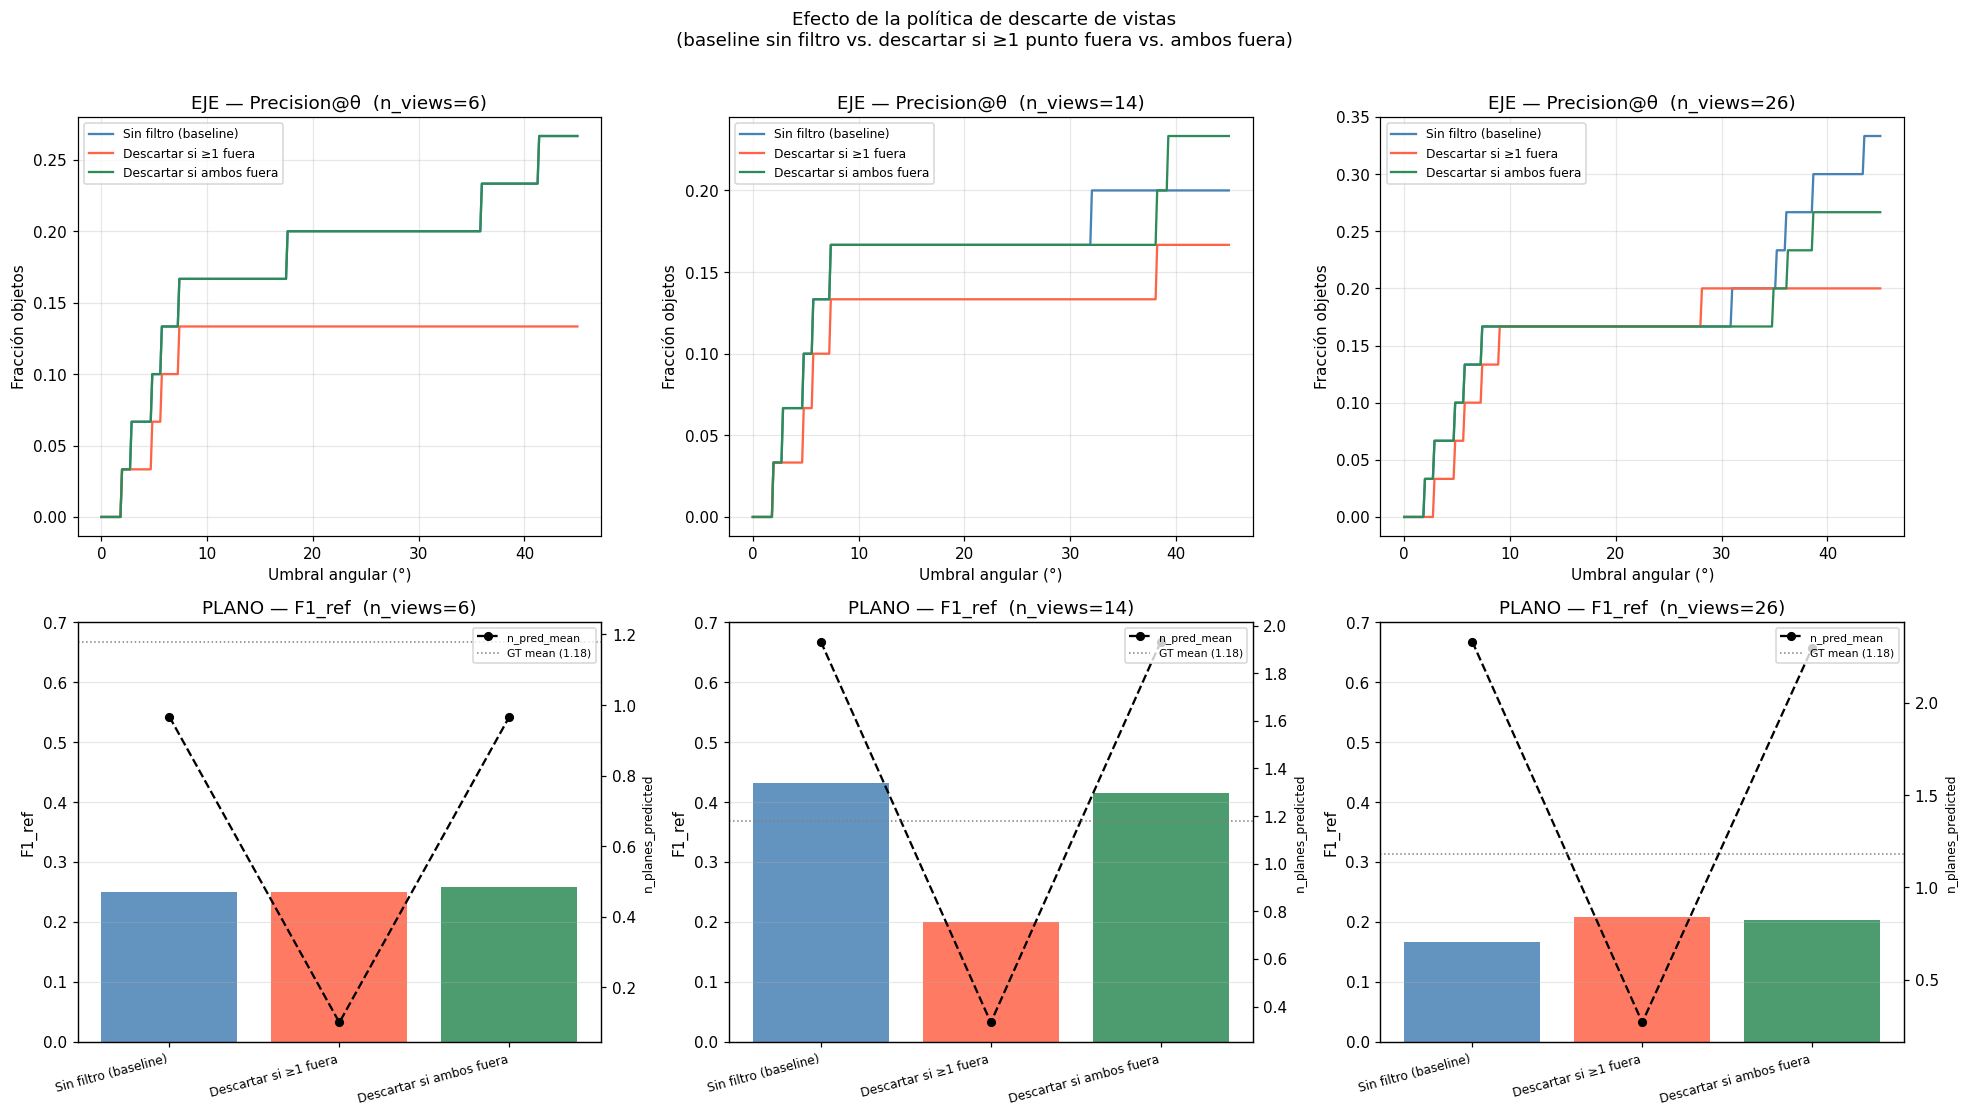

Guardado: view_filter_policy_comparison.png


In [43]:
# ── Tablas y visualización comparativa ───────────────────────────────────────

# ── 14a: Tabla de descarte — cuántas vistas se eliminan por política ─────────
print("=== Vistas descartadas por política ===\n")
for sym in ("axis", "plane"):
    print(f"--- {sym} ---")
    rows_d = []
    for pol in VIEW_FILTER_POLICIES:
        df_d = pd.DataFrame(discard_stats[pol][sym])
        for nv, grp in df_d.groupby("n_views"):
            rows_d.append({
                "policy":          pol,
                "n_views":         nv,
                "n_kept_mean":     round(grp["n_kept"].mean(), 2),
                "n_discarded_mean":round(grp["n_discarded"].mean(), 2),
                "frac_discard_%":  round(grp["frac_discarded"].mean() * 100, 1),
            })
    display(pd.DataFrame(rows_d).pivot_table(
        index="n_views", columns="policy",
        values="frac_discard_%"
    ).rename_axis("n_views / política").round(1))
    print()


# ── 14b: Métricas eje por política ───────────────────────────────────────────
print("\n=== EJE: AUC@45° y error mediano por política y n_views ===\n")
axis_summary = {}
for pol in VIEW_FILTER_POLICIES:
    df = pd.DataFrame(results_view_filter["axis"][pol])
    df["angular_error_deg"] = df["angular_error_deg"].fillna(90.0)
    summary = df.groupby("n_views")["angular_error_deg"].agg(
        median="median", mean="mean").round(2)
    summary["AUC@45°"] = [
        round(auc_angular(df[df["n_views"]==nv]["angular_error_deg"].tolist()), 4)
        for nv in summary.index
    ]
    for t in ANGULAR_THRESHOLDS:
        col = f"precision_{t}deg"
        if col in df.columns:
            summary[f"P@{t}°"] = df.groupby("n_views")[col].mean().round(4)
    axis_summary[pol] = summary
    print(f"  política='{pol}'")
    print(summary.to_string(), "\n")

# Tabla comparativa de AUC
auc_comp_axis = pd.DataFrame({
    pol: {nv: axis_summary[pol].loc[nv, "AUC@45°"]
          for nv in VIEW_GROUPS if nv in axis_summary[pol].index}
    for pol in VIEW_FILTER_POLICIES
})
auc_comp_axis.index.name = "n_views"
auc_comp_axis.columns.name = "política"
print(">>> AUC@45° por política (eje):")
display(auc_comp_axis)


# ── 14c: Métricas plano por política ─────────────────────────────────────────
print("\n=== PLANO: F1_ref por política y n_views ===\n")
plane_summary = {}
for pol in VIEW_FILTER_POLICIES:
    rows_p = results_view_filter["plane"][pol]
    totals_by_nv = {}
    for nv in VIEW_GROUPS:
        totals = {t: [0, 0, 0] for t in THRESHOLDS_INLIER}
        for r in rows_p:
            if r["n_views"] != nv: continue
            fc = r.get("f1_counts")
            if fc is None: continue
            for t in THRESHOLDS_INLIER:
                tp, fp, fn = fc[t]
                totals[t][0] += tp; totals[t][1] += fp; totals[t][2] += fn
        f1_per_t = [f1_from_counts(*totals[t]) for t in THRESHOLDS_INLIER]
        totals_by_nv[nv] = round(float(np.mean(f1_per_t)), 4)
    plane_summary[pol] = totals_by_nv
    print(f"  política='{pol}':  {totals_by_nv}")

f1_comp_plane = pd.DataFrame(plane_summary, index=VIEW_GROUPS)
f1_comp_plane.index.name = "n_views"
f1_comp_plane.columns.name = "política"
print("\n>>> F1_ref por política (plano):")
display(f1_comp_plane)

# n_pred medio
npred_comp = {}
for pol in VIEW_FILTER_POLICIES:
    df_ = pd.DataFrame(results_view_filter["plane"][pol])
    npred_comp[pol] = {nv: round(df_[df_["n_views"]==nv]["n_planes_predicted"].mean(), 3)
                       for nv in VIEW_GROUPS}
print("\n>>> n_planes_predicted medio por política (plano):")
display(pd.DataFrame(npred_comp, index=VIEW_GROUPS).rename_axis("n_views"))


# ── 14d: Visualización comparativa ───────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
colors = {"none": "steelblue", "any": "tomato", "both": "seagreen"}
labels_pol = {"none": "Sin filtro (baseline)", "any": "Descartar si ≥1 fuera", "both": "Descartar si ambos fuera"}

# Fila 1: curvas Precision@θ — eje
for ax, nv in zip(axes[0], VIEW_GROUPS):
    for pol in VIEW_FILTER_POLICIES:
        df_ = pd.DataFrame(results_view_filter["axis"][pol])
        df_["angular_error_deg"] = df_["angular_error_deg"].fillna(90.0)
        errs = df_[df_["n_views"]==nv]["angular_error_deg"].tolist()
        thetas = np.linspace(0, 45, 300)
        precs  = [(np.array(errs) <= t).mean() for t in thetas]
        ax.plot(thetas, precs, color=colors[pol], label=labels_pol[pol])
    ax.set_title(f"EJE — Precision@θ  (n_views={nv})")
    ax.set_xlabel("Umbral angular (°)"); ax.set_ylabel("Fracción objetos")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Fila 2: F1_ref barras + n_pred — plano
for ax, nv in zip(axes[1], VIEW_GROUPS):
    x = np.arange(len(VIEW_FILTER_POLICIES))
    f1_vals   = [f1_comp_plane.loc[nv, pol] for pol in VIEW_FILTER_POLICIES]
    npred_vals= [npred_comp[pol][nv]         for pol in VIEW_FILTER_POLICIES]
    bars = ax.bar(x, f1_vals, color=[colors[p] for p in VIEW_FILTER_POLICIES], alpha=0.85)
    ax2 = ax.twinx()
    ax2.plot(x, npred_vals, "k--o", markersize=5, label="n_pred_mean")
    ax2.axhline(1.18, color="gray", linestyle=":", linewidth=1, label="GT mean (1.18)")
    ax2.set_ylabel("n_planes_predicted", fontsize=8)
    ax2.legend(fontsize=7, loc="upper right")
    ax.set_xticks(x)
    ax.set_xticklabels([labels_pol[p] for p in VIEW_FILTER_POLICIES],
                        rotation=15, ha="right", fontsize=8)
    ax.set_title(f"PLANO — F1_ref  (n_views={nv})")
    ax.set_ylabel("F1_ref"); ax.set_ylim(0, 0.7)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Efecto de la política de descarte de vistas\n"
             "(baseline sin filtro vs. descartar si ≥1 punto fuera vs. ambos fuera)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("view_filter_policy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: view_filter_policy_comparison.png")

# ── Diagnóstico: ¿Molmo pone los puntos en el centro horizontal (X≈500)? ─────

In [ ]:
# Hipótesis a verificar: el modelo no comprende la estructura del objeto
# y distribuye los 6 puntos uniformemente en Y con X fijo ≈ 500 (centro de imagen).
#
# Para cada objeto y n_views, calcula:
#   - Media y std de X por vista (¿están todos los puntos cerca de X=500?)
#   - Media y std de Y por vista (¿están distribuidos uniformemente en Y?)
#   - Distancia media de X al centro (500) normalizada: si < 5% → sospechoso
#   - Fracción de vistas "degeneradas" (std_X < umbral → todos X casi iguales)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

X_CENTER       = 500.0    # centro de la imagen en escala Molmo (0-1000)
X_STD_THRESH   = 15.0     # std de X en px Molmo por debajo de la cual una vista es "degenerada"
X_MEAN_THRESH  = 30.0     # distancia media al centro por debajo de la cual se sospecha centrado

# ── Elegir qué prompt analizar ───────────────────────────────────────────────
SYM_TO_ANALYZE   = "axis_sym"         # "axis_sym" o "plane_sym"
EXP_ID_TO_ANALYZE = EXPERIMENT_ID_AXIS  # o EXPERIMENT_ID_PLANE
OBJECT_LIST_TO_ANALYZE = OBJECT_LIST_AXIS  # o OBJECT_LIST_PLANE

records = []

for cat, oid in OBJECT_LIST_TO_ANALYZE:
    render_dir = SANDBOX_RENDERS / SYM_TO_ANALYZE / oid / str(SIZE) / LIGHTING
    json_path  = render_dir / f"molmo_multiview_{EXP_ID_TO_ANALYZE}.json"
    if not json_path.exists():
        continue
    molmo_data = json.load(open(json_path, encoding="utf-8"))

    for n_views_key, group in molmo_data.items():
        pts_by_img = group.get("points_by_image", {})
        imgs_sent  = group.get("images_sent", [])

        for img_idx_str, pts in pts_by_img.items():
            if not pts:
                continue

            xs = [p["x"] for p in pts]
            ys = [p["y"] for p in pts]
            img_idx = int(img_idx_str)

            # Elevación y azimut de esa vista (para saber si es cenital)
            cam = imgs_sent[img_idx] if img_idx < len(imgs_sent) else {}
            elevation = cam.get("elevation", float("nan"))
            azimuth   = cam.get("azimuth",   float("nan"))

            x_mean     = float(np.mean(xs))
            x_std      = float(np.std(xs))
            y_std      = float(np.std(ys))
            dist_center = abs(x_mean - X_CENTER)  # distancia al centro horizontal
            is_centered = dist_center < X_MEAN_THRESH  # X cerca del 500
            is_x_degenerate = x_std < X_STD_THRESH   # todos los X casi iguales

            records.append({
                "object_id":       oid,
                "categoria":       cat,
                "n_views":         int(n_views_key),
                "img_idx":         img_idx,
                "elevation":       elevation,
                "azimuth":         azimuth,
                "n_points":        len(pts),
                "x_mean":          round(x_mean, 1),
                "x_std":           round(x_std, 1),
                "y_std":           round(y_std, 1),
                "dist_center_x":   round(dist_center, 1),
                "is_centered_x":   is_centered,
                "is_x_degenerate": is_x_degenerate,
            })

df_diag = pd.DataFrame(records)

# ── Resumen global ───────────────────────────────────────────────────────────
print("="*65)
print(f"  Diagnóstico de distribución de puntos — {EXP_ID_TO_ANALYZE}")
print("="*65)
print(f"Total vistas analizadas:      {len(df_diag)}")
print(f"Vistas con X centrado (<{X_MEAN_THRESH:.0f}px del centro): "
      f"{df_diag['is_centered_x'].sum()} "
      f"({df_diag['is_centered_x'].mean()*100:.1f}%)")
print(f"Vistas X degeneradas (std_X<{X_STD_THRESH:.0f}px):          "
      f"{df_diag['is_x_degenerate'].sum()} "
      f"({df_diag['is_x_degenerate'].mean()*100:.1f}%)")

print(f"\n  X_mean global:  {df_diag['x_mean'].mean():.1f} ± {df_diag['x_mean'].std():.1f}  (esperado ~500 si centrado)")
print(f"  dist_center_X:  {df_diag['dist_center_x'].mean():.1f} px  (promedio por vista)")
print(f"  X_std global:   {df_diag['x_std'].mean():.1f} px  (variación horizontal dentro de cada vista)")
print(f"  Y_std global:   {df_diag['y_std'].mean():.1f} px  (variación vertical — esperada alta con 6 pts)")

# ── Por n_views ──────────────────────────────────────────────────────────────
print("\n--- Por n_views ---")
summary_nv = df_diag.groupby("n_views").agg(
    x_mean_mean=("x_mean", "mean"),
    dist_center_mean=("dist_center_x", "mean"),
    x_std_mean=("x_std", "mean"),
    y_std_mean=("y_std", "mean"),
    pct_centered=("is_centered_x", lambda c: c.mean() * 100),
    pct_x_degen=("is_x_degenerate", lambda c: c.mean() * 100),
).round(1)
print(summary_nv.to_string())

# ── Por elevación: las vistas cenitales tendrán X≈500 inevitablemente ────────
print("\n--- Degeneración X por rango de elevación ---")
bins  = [-90, -60, -30, 0, 30, 60, 90]
labels = [f"{a}→{b}°" for a, b in zip(bins, bins[1:])]
df_diag["elev_bin"] = pd.cut(df_diag["elevation"], bins=bins, labels=labels)
elev_summary = df_diag.groupby("elev_bin", observed=True).agg(
    n_vistas=("img_idx", "count"),
    dist_center_mean=("dist_center_x", "mean"),
    pct_centered=("is_centered_x", lambda c: c.mean() * 100),
    pct_x_degen=("is_x_degenerate", lambda c: c.mean() * 100),
).round(1)
print(elev_summary.to_string())
print("\n  ⚠ Vistas cenitales (elev>60°) DEBEN tener X≈500 para eje vertical — esto es CORRECTO.")
print("  ⚠ Si vistas no cenitales (elev<45°) también tienen X≈500, hay un problema real.")

# ── Histogramas ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Fila 1: distribuciones globales
axes[0,0].hist(df_diag["x_mean"], bins=40, color="steelblue", edgecolor="white")
axes[0,0].axvline(X_CENTER, color="red", linestyle="--", label=f"Centro X={X_CENTER:.0f}")
axes[0,0].axvline(X_CENTER - X_MEAN_THRESH, color="orange", linestyle=":", alpha=0.7)
axes[0,0].axvline(X_CENTER + X_MEAN_THRESH, color="orange", linestyle=":",
                  alpha=0.7, label=f"±{X_MEAN_THRESH:.0f}px zona sospechosa")
axes[0,0].set_xlabel("X_mean por vista (px Molmo)"); axes[0,0].set_ylabel("N vistas")
axes[0,0].set_title("Distribución de X_mean\n(pico en 500 = problema)")
axes[0,0].legend(fontsize=8)

axes[0,1].hist(df_diag["x_std"], bins=40, color="tomato", edgecolor="white")
axes[0,1].axvline(X_STD_THRESH, color="red", linestyle="--",
                  label=f"Umbral degen={X_STD_THRESH:.0f}px")
axes[0,1].set_xlabel("X_std por vista (px Molmo)"); axes[0,1].set_ylabel("N vistas")
axes[0,1].set_title("Variación horizontal (X_std)\n(cerca de 0 = todos X iguales)")
axes[0,1].legend(fontsize=8)

axes[0,2].hist(df_diag["y_std"], bins=40, color="seagreen", edgecolor="white")
axes[0,2].set_xlabel("Y_std por vista (px Molmo)"); axes[0,2].set_ylabel("N vistas")
axes[0,2].set_title("Variación vertical (Y_std)\n(alta = puntos bien distribuidos en Y)")

# Fila 2: scatter X_mean vs elevación, separado por n_views
nv_list = sorted(df_diag["n_views"].unique())
colors_nv = {nv: c for nv, c in zip(nv_list, ["steelblue","tomato","seagreen","purple","orange"])}

ax_sc = axes[1,0]
for nv, grp in df_diag.groupby("n_views"):
    ax_sc.scatter(grp["elevation"], grp["x_mean"], alpha=0.4, s=15,
                  color=colors_nv.get(nv, "gray"), label=f"n_views={nv}")
ax_sc.axhline(X_CENTER, color="red", linestyle="--", linewidth=1, label="X=500")
ax_sc.axhline(X_CENTER + X_MEAN_THRESH, color="orange", linestyle=":", linewidth=1)
ax_sc.axhline(X_CENTER - X_MEAN_THRESH, color="orange", linestyle=":", linewidth=1)
ax_sc.set_xlabel("Elevación (°)"); ax_sc.set_ylabel("X_mean por vista")
ax_sc.set_title("X_mean vs Elevación\n(vistas cenitales X≈500 es normal)")
ax_sc.legend(fontsize=7, ncol=2)

# Scatter X_std vs elevación
ax_xs = axes[1,1]
for nv, grp in df_diag.groupby("n_views"):
    ax_xs.scatter(grp["elevation"], grp["x_std"], alpha=0.4, s=15,
                  color=colors_nv.get(nv, "gray"), label=f"n_views={nv}")
ax_xs.axhline(X_STD_THRESH, color="red", linestyle="--",
              linewidth=1, label=f"Umbral degen={X_STD_THRESH:.0f}")
ax_xs.set_xlabel("Elevación (°)"); ax_xs.set_ylabel("X_std por vista")
ax_xs.set_title("X_std vs Elevación\n(bajo en vistas cenitales es normal)")
ax_xs.legend(fontsize=7, ncol=2)

# Scatter X_std vs Y_std: si el problema existe → X_std≈0 pero Y_std>0
ax_xy = axes[1,2]
centered = df_diag[df_diag["is_centered_x"]]
not_centered = df_diag[~df_diag["is_centered_x"]]
ax_xy.scatter(not_centered["x_std"], not_centered["y_std"],
              alpha=0.3, s=12, color="steelblue", label="X no centrado (OK)")
ax_xy.scatter(centered["x_std"], centered["y_std"],
              alpha=0.6, s=12, color="red", label="X centrado (sospechoso)")
ax_xy.axvline(X_STD_THRESH, color="orange", linestyle="--",
              linewidth=1, label=f"X_std umbral={X_STD_THRESH:.0f}")
ax_xy.set_xlabel("X_std por vista"); ax_xy.set_ylabel("Y_std por vista")
ax_xy.set_title("X_std vs Y_std\n(rojo: X≈500 con Y distribuido = problema)")
ax_xy.legend(fontsize=8)

plt.suptitle(
    f"Diagnóstico de distribución de puntos — {EXP_ID_TO_ANALYZE}\n"
    f"¿Molmo pone todos los puntos en X≈500 y distribuye solo en Y?",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig("diagnostico_distribucion_xy.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nGuardado: diagnostico_distribucion_xy.png")

# ── Casos concretos más sospechosos ──────────────────────────────────────────
print("\n=== Top 10 vistas más sospechosas (X centrado + bajo X_std) ===")
sospechosas = df_diag[df_diag["is_centered_x"] & df_diag["is_x_degenerate"]].copy()
sospechosas = sospechosas.sort_values(["x_std", "dist_center_x"]).head(10)
print(sospechosas[["object_id","categoria","n_views","img_idx",
                   "elevation","x_mean","x_std","y_std",
                   "dist_center_x"]].to_string(index=False))

# ── Veredicto ─────────────────────────────────────────────────────────────────
pct_prob = df_diag["is_centered_x"].mean() * 100
print(f"\n{'='*65}")
if pct_prob > 50:
    print(f"  ⚠ PROBLEMA CONFIRMADO: {pct_prob:.1f}% de las vistas tienen X_mean ≈ 500.")
    print(f"  El modelo está usando el centro de la imagen como posición horizontal")
    print(f"  de todos los puntos y solo variando Y — no comprende el objeto.")
elif pct_prob > 20:
    print(f"  ⚠ PROBLEMA PARCIAL: {pct_prob:.1f}% de las vistas tienen X_mean ≈ 500.")
    print(f"  Posiblemente afecta a objetos con eje vertical visto de frente.")
else:
    print(f"  ✓ Sin problema generalizado: solo {pct_prob:.1f}% de vistas con X≈500.")
    print(f"  El modelo sí está desplazando X según la estructura del objeto.")
print(f"{'='*65}")

  Diagnóstico de distribución de puntos — axis_v06
Total vistas analizadas:      0


KeyError: 'is_centered_x'

  Diagnóstico de distribución de puntos — plane_v05_sandbox_6pts
Total vistas analizadas:      1380
Vistas con X centrado (<30px del centro): 1234 (89.4%)
Vistas X degeneradas (std_X<15px):          1321 (95.7%)

  X_mean global:  492.8 ± 45.2  (esperado ~500 si centrado)
  dist_center_X:  14.2 px  (promedio por vista)
  X_std global:   4.3 px  (variación horizontal dentro de cada vista)
  Y_std global:   148.7 px  (variación vertical — esperada alta con 6 pts)

--- Por n_views ---
         x_mean_mean  dist_center_mean  x_std_mean  y_std_mean  pct_centered  pct_x_degen
n_views                                                                                  
6              494.5              11.1         9.0       124.9          89.4         93.9
14             497.5               6.9         3.0       139.6          91.9         97.6
26             489.9              18.9         3.9       159.1          88.1         95.1

--- Degeneración X por rango de elevación ---
          n_vist

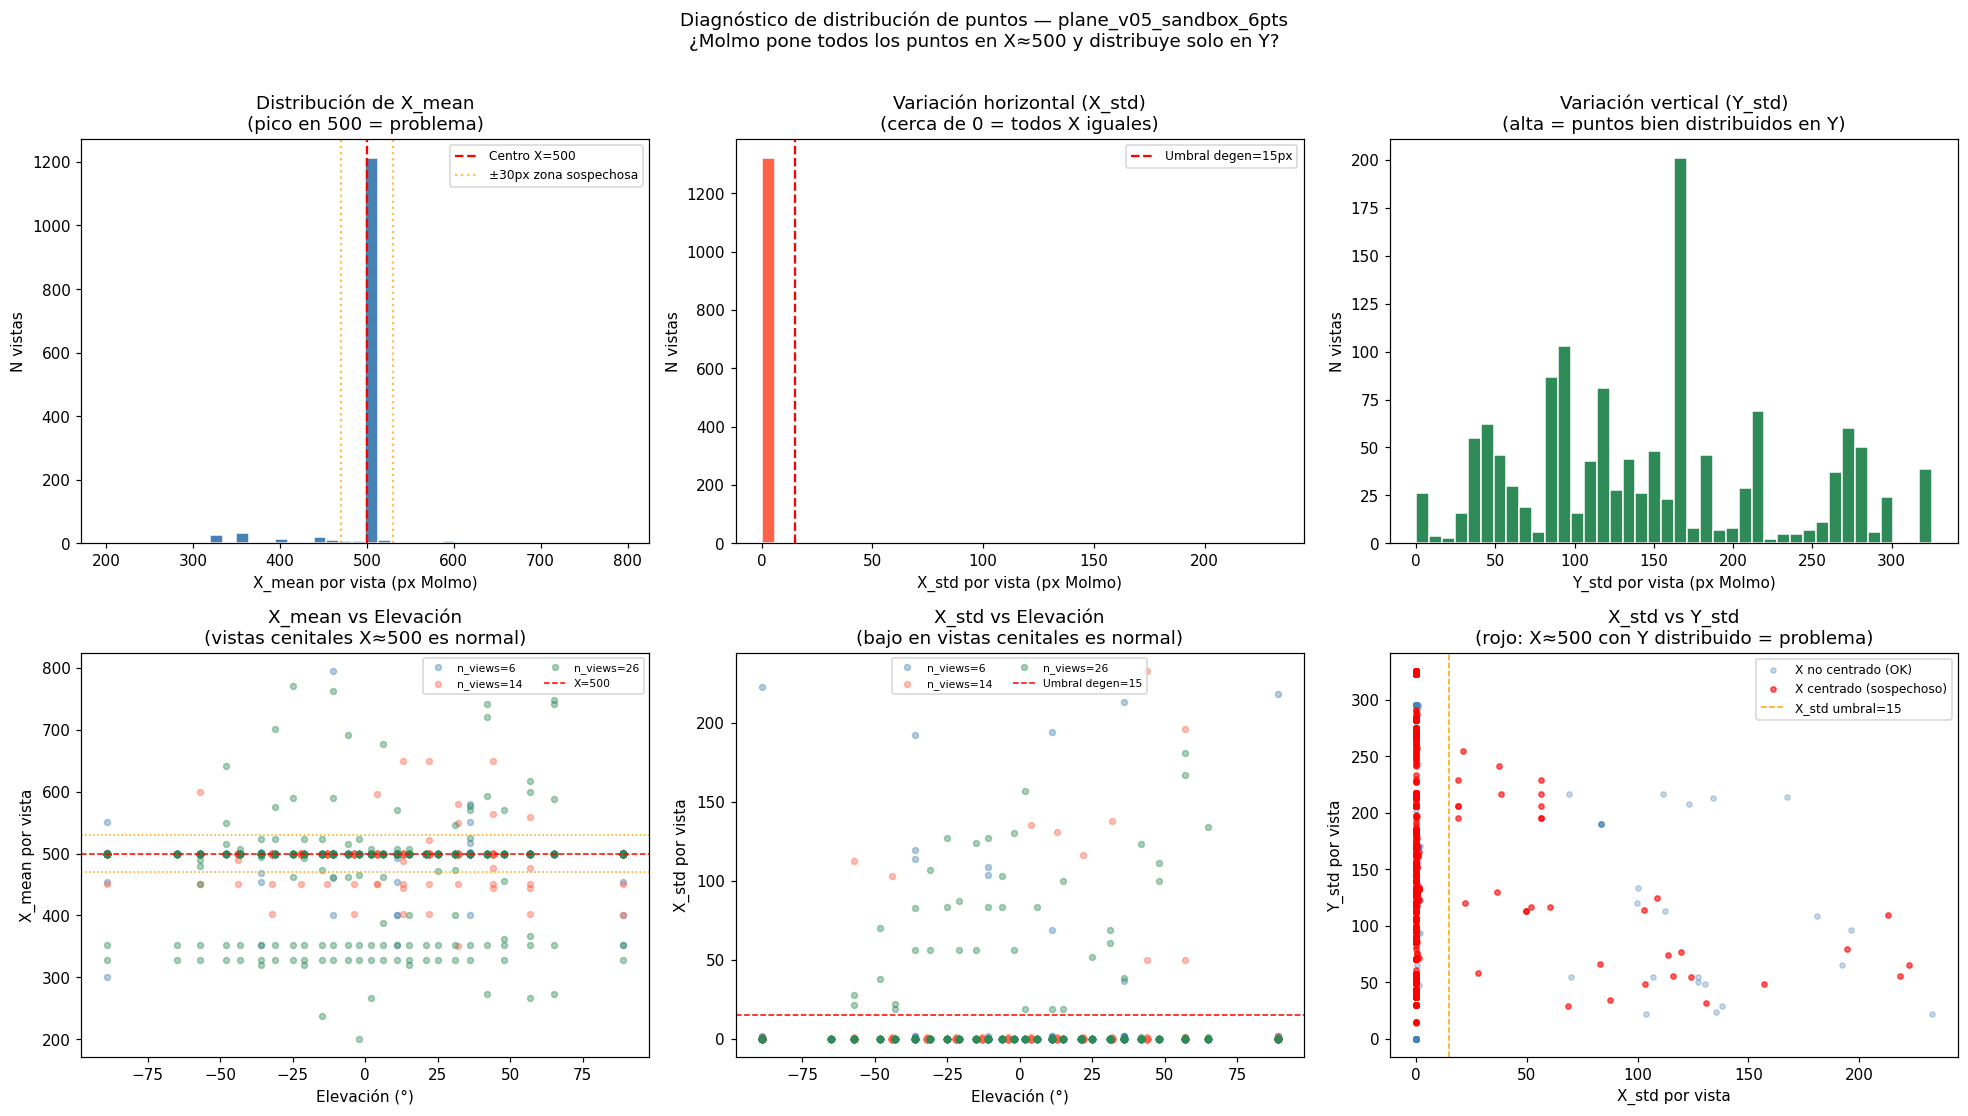


Guardado: diagnostico_distribucion_xy.png

=== Top 10 vistas más sospechosas (X centrado + bajo X_std) ===
                       object_id categoria  n_views  img_idx  elevation  x_mean  x_std  y_std  dist_center_x
109a19840a8fbc774c3aee8e9d3a6ffa     BUENO       14        1         57   500.0    0.0  139.7            0.0
109a19840a8fbc774c3aee8e9d3a6ffa     BUENO       14        2         44   500.0    0.0  146.1            0.0
109a19840a8fbc774c3aee8e9d3a6ffa     BUENO       14        3         32   500.0    0.0  139.7            0.0
109a19840a8fbc774c3aee8e9d3a6ffa     BUENO       14        4         22   500.0    0.0  139.7            0.0
109a19840a8fbc774c3aee8e9d3a6ffa     BUENO       14        5         13   500.0    0.0  139.7            0.0
109a19840a8fbc774c3aee8e9d3a6ffa     BUENO       14        6          4   500.0    0.0  139.7            0.0
109a19840a8fbc774c3aee8e9d3a6ffa     BUENO       14        7         -4   500.0    0.0  139.7            0.0
109a19840a8fbc774c3a

In [ ]:
# Hipótesis a verificar: el modelo no comprende la estructura del objeto
# y distribuye los 6 puntos uniformemente en Y con X fijo ≈ 500 (centro de imagen).
#
# Para cada objeto y n_views, calcula:
#   - Media y std de X por vista (¿están todos los puntos cerca de X=500?)
#   - Media y std de Y por vista (¿están distribuidos uniformemente en Y?)
#   - Distancia media de X al centro (500) normalizada: si < 5% → sospechoso
#   - Fracción de vistas "degeneradas" (std_X < umbral → todos X casi iguales)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

X_CENTER       = 500.0    # centro de la imagen en escala Molmo (0-1000)
X_STD_THRESH   = 15.0     # std de X en px Molmo por debajo de la cual una vista es "degenerada"
X_MEAN_THRESH  = 30.0     # distancia media al centro por debajo de la cual se sospecha centrado

# ── Elegir qué prompt analizar ───────────────────────────────────────────────
SYM_TO_ANALYZE   = "plane_sym"         # "axis_sym" o "plane_sym"
EXP_ID_TO_ANALYZE = "plane_v04_1"  # o EXPERIMENT_ID_PLANE
OBJECT_LIST_TO_ANALYZE = OBJECT_LIST_PLANE  # o OBJECT_LIST_PLANE

records = []

for cat, oid in OBJECT_LIST_TO_ANALYZE:
    render_dir = SANDBOX_RENDERS / SYM_TO_ANALYZE / oid / str(SIZE) / LIGHTING
    json_path  = render_dir / f"molmo_multiview_{EXP_ID_TO_ANALYZE}.json"
    if not json_path.exists():
        continue
    molmo_data = json.load(open(json_path, encoding="utf-8"))

    for n_views_key, group in molmo_data.items():
        pts_by_img = group.get("points_by_image", {})
        imgs_sent  = group.get("images_sent", [])

        for img_idx_str, pts in pts_by_img.items():
            if not pts:
                continue

            xs = [p["x"] for p in pts]
            ys = [p["y"] for p in pts]
            img_idx = int(img_idx_str)

            # Elevación y azimut de esa vista (para saber si es cenital)
            cam = imgs_sent[img_idx] if img_idx < len(imgs_sent) else {}
            elevation = cam.get("elevation", float("nan"))
            azimuth   = cam.get("azimuth",   float("nan"))

            x_mean     = float(np.mean(xs))
            x_std      = float(np.std(xs))
            y_std      = float(np.std(ys))
            dist_center = abs(x_mean - X_CENTER)  # distancia al centro horizontal
            is_centered = dist_center < X_MEAN_THRESH  # X cerca del 500
            is_x_degenerate = x_std < X_STD_THRESH   # todos los X casi iguales

            records.append({
                "object_id":       oid,
                "categoria":       cat,
                "n_views":         int(n_views_key),
                "img_idx":         img_idx,
                "elevation":       elevation,
                "azimuth":         azimuth,
                "n_points":        len(pts),
                "x_mean":          round(x_mean, 1),
                "x_std":           round(x_std, 1),
                "y_std":           round(y_std, 1),
                "dist_center_x":   round(dist_center, 1),
                "is_centered_x":   is_centered,
                "is_x_degenerate": is_x_degenerate,
            })

df_diag = pd.DataFrame(records)

# ── Resumen global ───────────────────────────────────────────────────────────
print("="*65)
print(f"  Diagnóstico de distribución de puntos — {EXP_ID_TO_ANALYZE}")
print("="*65)
print(f"Total vistas analizadas:      {len(df_diag)}")
print(f"Vistas con X centrado (<{X_MEAN_THRESH:.0f}px del centro): "
      f"{df_diag['is_centered_x'].sum()} "
      f"({df_diag['is_centered_x'].mean()*100:.1f}%)")
print(f"Vistas X degeneradas (std_X<{X_STD_THRESH:.0f}px):          "
      f"{df_diag['is_x_degenerate'].sum()} "
      f"({df_diag['is_x_degenerate'].mean()*100:.1f}%)")

print(f"\n  X_mean global:  {df_diag['x_mean'].mean():.1f} ± {df_diag['x_mean'].std():.1f}  (esperado ~500 si centrado)")
print(f"  dist_center_X:  {df_diag['dist_center_x'].mean():.1f} px  (promedio por vista)")
print(f"  X_std global:   {df_diag['x_std'].mean():.1f} px  (variación horizontal dentro de cada vista)")
print(f"  Y_std global:   {df_diag['y_std'].mean():.1f} px  (variación vertical — esperada alta con 6 pts)")

# ── Por n_views ──────────────────────────────────────────────────────────────
print("\n--- Por n_views ---")
summary_nv = df_diag.groupby("n_views").agg(
    x_mean_mean=("x_mean", "mean"),
    dist_center_mean=("dist_center_x", "mean"),
    x_std_mean=("x_std", "mean"),
    y_std_mean=("y_std", "mean"),
    pct_centered=("is_centered_x", lambda c: c.mean() * 100),
    pct_x_degen=("is_x_degenerate", lambda c: c.mean() * 100),
).round(1)
print(summary_nv.to_string())

# ── Por elevación: las vistas cenitales tendrán X≈500 inevitablemente ────────
print("\n--- Degeneración X por rango de elevación ---")
bins  = [-90, -60, -30, 0, 30, 60, 90]
labels = [f"{a}→{b}°" for a, b in zip(bins, bins[1:])]
df_diag["elev_bin"] = pd.cut(df_diag["elevation"], bins=bins, labels=labels)
elev_summary = df_diag.groupby("elev_bin", observed=True).agg(
    n_vistas=("img_idx", "count"),
    dist_center_mean=("dist_center_x", "mean"),
    pct_centered=("is_centered_x", lambda c: c.mean() * 100),
    pct_x_degen=("is_x_degenerate", lambda c: c.mean() * 100),
).round(1)
print(elev_summary.to_string())
print("\n  ⚠ Vistas cenitales (elev>60°) DEBEN tener X≈500 para eje vertical — esto es CORRECTO.")
print("  ⚠ Si vistas no cenitales (elev<45°) también tienen X≈500, hay un problema real.")

# ── Histogramas ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Fila 1: distribuciones globales
axes[0,0].hist(df_diag["x_mean"], bins=40, color="steelblue", edgecolor="white")
axes[0,0].axvline(X_CENTER, color="red", linestyle="--", label=f"Centro X={X_CENTER:.0f}")
axes[0,0].axvline(X_CENTER - X_MEAN_THRESH, color="orange", linestyle=":", alpha=0.7)
axes[0,0].axvline(X_CENTER + X_MEAN_THRESH, color="orange", linestyle=":",
                  alpha=0.7, label=f"±{X_MEAN_THRESH:.0f}px zona sospechosa")
axes[0,0].set_xlabel("X_mean por vista (px Molmo)"); axes[0,0].set_ylabel("N vistas")
axes[0,0].set_title("Distribución de X_mean\n(pico en 500 = problema)")
axes[0,0].legend(fontsize=8)

axes[0,1].hist(df_diag["x_std"], bins=40, color="tomato", edgecolor="white")
axes[0,1].axvline(X_STD_THRESH, color="red", linestyle="--",
                  label=f"Umbral degen={X_STD_THRESH:.0f}px")
axes[0,1].set_xlabel("X_std por vista (px Molmo)"); axes[0,1].set_ylabel("N vistas")
axes[0,1].set_title("Variación horizontal (X_std)\n(cerca de 0 = todos X iguales)")
axes[0,1].legend(fontsize=8)

axes[0,2].hist(df_diag["y_std"], bins=40, color="seagreen", edgecolor="white")
axes[0,2].set_xlabel("Y_std por vista (px Molmo)"); axes[0,2].set_ylabel("N vistas")
axes[0,2].set_title("Variación vertical (Y_std)\n(alta = puntos bien distribuidos en Y)")

# Fila 2: scatter X_mean vs elevación, separado por n_views
nv_list = sorted(df_diag["n_views"].unique())
colors_nv = {nv: c for nv, c in zip(nv_list, ["steelblue","tomato","seagreen","purple","orange"])}

ax_sc = axes[1,0]
for nv, grp in df_diag.groupby("n_views"):
    ax_sc.scatter(grp["elevation"], grp["x_mean"], alpha=0.4, s=15,
                  color=colors_nv.get(nv, "gray"), label=f"n_views={nv}")
ax_sc.axhline(X_CENTER, color="red", linestyle="--", linewidth=1, label="X=500")
ax_sc.axhline(X_CENTER + X_MEAN_THRESH, color="orange", linestyle=":", linewidth=1)
ax_sc.axhline(X_CENTER - X_MEAN_THRESH, color="orange", linestyle=":", linewidth=1)
ax_sc.set_xlabel("Elevación (°)"); ax_sc.set_ylabel("X_mean por vista")
ax_sc.set_title("X_mean vs Elevación\n(vistas cenitales X≈500 es normal)")
ax_sc.legend(fontsize=7, ncol=2)

# Scatter X_std vs elevación
ax_xs = axes[1,1]
for nv, grp in df_diag.groupby("n_views"):
    ax_xs.scatter(grp["elevation"], grp["x_std"], alpha=0.4, s=15,
                  color=colors_nv.get(nv, "gray"), label=f"n_views={nv}")
ax_xs.axhline(X_STD_THRESH, color="red", linestyle="--",
              linewidth=1, label=f"Umbral degen={X_STD_THRESH:.0f}")
ax_xs.set_xlabel("Elevación (°)"); ax_xs.set_ylabel("X_std por vista")
ax_xs.set_title("X_std vs Elevación\n(bajo en vistas cenitales es normal)")
ax_xs.legend(fontsize=7, ncol=2)

# Scatter X_std vs Y_std: si el problema existe → X_std≈0 pero Y_std>0
ax_xy = axes[1,2]
centered = df_diag[df_diag["is_centered_x"]]
not_centered = df_diag[~df_diag["is_centered_x"]]
ax_xy.scatter(not_centered["x_std"], not_centered["y_std"],
              alpha=0.3, s=12, color="steelblue", label="X no centrado (OK)")
ax_xy.scatter(centered["x_std"], centered["y_std"],
              alpha=0.6, s=12, color="red", label="X centrado (sospechoso)")
ax_xy.axvline(X_STD_THRESH, color="orange", linestyle="--",
              linewidth=1, label=f"X_std umbral={X_STD_THRESH:.0f}")
ax_xy.set_xlabel("X_std por vista"); ax_xy.set_ylabel("Y_std por vista")
ax_xy.set_title("X_std vs Y_std\n(rojo: X≈500 con Y distribuido = problema)")
ax_xy.legend(fontsize=8)

plt.suptitle(
    f"Diagnóstico de distribución de puntos — {EXP_ID_TO_ANALYZE}\n"
    f"¿Molmo pone todos los puntos en X≈500 y distribuye solo en Y?",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig("diagnostico_distribucion_xy.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nGuardado: diagnostico_distribucion_xy.png")

# ── Casos concretos más sospechosos ──────────────────────────────────────────
print("\n=== Top 10 vistas más sospechosas (X centrado + bajo X_std) ===")
sospechosas = df_diag[df_diag["is_centered_x"] & df_diag["is_x_degenerate"]].copy()
sospechosas = sospechosas.sort_values(["x_std", "dist_center_x"]).head(10)
print(sospechosas[["object_id","categoria","n_views","img_idx",
                   "elevation","x_mean","x_std","y_std",
                   "dist_center_x"]].to_string(index=False))

# ── Veredicto ─────────────────────────────────────────────────────────────────
pct_prob = df_diag["is_centered_x"].mean() * 100
print(f"\n{'='*65}")
if pct_prob > 50:
    print(f"  ⚠ PROBLEMA CONFIRMADO: {pct_prob:.1f}% de las vistas tienen X_mean ≈ 500.")
    print(f"  El modelo está usando el centro de la imagen como posición horizontal")
    print(f"  de todos los puntos y solo variando Y — no comprende el objeto.")
elif pct_prob > 20:
    print(f"  ⚠ PROBLEMA PARCIAL: {pct_prob:.1f}% de las vistas tienen X_mean ≈ 500.")
    print(f"  Posiblemente afecta a objetos con eje vertical visto de frente.")
else:
    print(f"  ✓ Sin problema generalizado: solo {pct_prob:.1f}% de vistas con X≈500.")
    print(f"  El modelo sí está desplazando X según la estructura del objeto.")
print(f"{'='*65}")